## Ovarian Cancer Spatial Transcriptomics Analysis

**Project:** Computational Methods for Analyzing T Cell Spatial Organization in Ovarian Cancer  
**Dataset:** Yeh et al. (2024) – 491,792 cells from 58 ovarian cancer patients  
**Goal:** Analyze CD8+ T cell spatial positioning relative to malignant cells and relate this to T cell exhaustion state

---

### Analysis Pipeline

| Step | Description |
|------|-------------|
| **1** | Setup & data loading |
| **2** | Cell type overview & group definitions |
| **3** | Spatial overview (representative tissue sample) |
| **4** | Per-sample radius-based neighbourhood analysis + KNN comparison |
| **5** | Exhaustion score calculation + sensitivity checks |
| **6** | Define tumour-rich vs tumour-poor neighbourhoods |
| **7** | Path A — Gene expression & infiltration across clinical groups |
| **8** | Path B — Tumour-rich vs tumour-poor neighbourhood comparison |
| **9** | Sanity checks & validation |
| **10** | Patient-level aggregation & treatment impact analysis |
| **11** | CD47 / TSP-1 / PD1 infiltration analysis (19 markers) |
| **12** | Infiltration Index (unified spatial metric) |
| **13** | UMAP visualisation of CD8+ T cells |
| **14** | Weng et al. (2025) style plots (TSP-1–CD47 axis) |
| **15** | Machine Learning model development |

**Primary spatial approach:** Radius-based (biologically relevant — defines a fixed physical microenvironment)  
**Secondary spatial approach:** KNN-based (k nearest neighbours — guarantees fixed neighbourhood size)


---
### 1. Setup & Data Loading

In [ ]:
# ============================================================
# IMPORTS — All packages used throughout the notebook
# ============================================================

# Core data handling
import numpy as np
import pandas as pd
import time
import warnings
import os
import re
import subprocess

# AnnData / Scanpy
import scanpy as sc
import anndata as ad
import squidpy as sq

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns

# Spatial analysis
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, spearmanr, zscore

# Machine learning
from sklearn.model_selection import (
    cross_val_score, cross_val_predict, GridSearchCV,
    StratifiedKFold, LeaveOneGroupOut, train_test_split
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    auc, confusion_matrix, ConfusionMatrixDisplay
)
import joblib

# Deep learning / CNN
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import requests
import urllib3


# Local pipeline utilities
from utils import *

warnings.filterwarnings("ignore")


In [3]:
# ============================================================
# 1b. Load Spatial Transcriptomics Data
# ============================================================
data = ad.read_h5ad("ST_Discovery.h5ad")

print(f"Dataset shape: {data.shape}")
print(f"Number of cells: {data.n_obs:,}")
print(f"Number of genes: {data.n_vars:,}")
print(f"Columns: {list(data.obs.columns)}")


Dataset shape: (491792, 979)
Number of cells: 491,792
Number of genes: 979
Columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'samples', 'patients', 'sites_binary', 'cell.types', 'cell.subtypes', 'x', 'y', 'ident']


In [4]:
# ============================================================
# 1c. Load Clinical Metadata (Supplementary Table 2b)
# ============================================================
supp_table2 = pd.read_excel(
    "41590_2024_1943_MOESM3_ESM.xlsx",
    sheet_name="Table 2b",
    header=1
)

# Filter to Discovery dataset only (matches spatial data)
supp_table2 = supp_table2[supp_table2["dataset"] == "Discovery"].copy()

print(f"Clinical profiles (Discovery): {supp_table2.shape[0]}")
print(f"Unique patients (clinical): {supp_table2['patients'].nunique()}")
print(f"Unique patients (spatial):  {data.obs['patients'].nunique()}")


Clinical profiles (Discovery): 100
Unique patients (clinical): 58
Unique patients (spatial):  58


In [5]:
# ============================================================
# 1d. Clean Clinical Metadata & Merge into AnnData
# ============================================================
# Build a PROFILE-level lookup
clinical = supp_table2[["profile", "patients", "sites_binary", "stage",
                         "treatment", "immunotherapy"]].copy()

# Clean treatment
clinical["treatment_clean"] = (
    clinical["treatment"].astype(str).str.strip()
    .replace({"nan": "Unknown", "None": "Unknown", "": "Unknown"})
)

# Clean immunotherapy
def clean_immuno(val):
    v = str(val).strip().lower()
    if v in ["no", "0", "false"]:
        return "No"
    if v in ["nan", "none", "", "not reported (lost to follow-up)"]:
        return "Unknown"
    return "Yes"

clinical["immunotherapy_clean"] = clinical["immunotherapy"].apply(clean_immuno)

# Clean anatomical site
clinical["site_clean"] = (
    clinical["sites_binary"].astype(str).str.strip()
    .replace({"nan": "Unknown", "None": "Unknown", "": "Unknown"})
)

# Build lookup dictionaries keyed by profile name
clinical["profile_str"] = clinical["profile"].astype(str).str.strip()
treat_map = clinical.set_index("profile_str")["treatment_clean"].to_dict()
immuno_map = clinical.set_index("profile_str")["immunotherapy_clean"].to_dict()
site_map = clinical.set_index("profile_str")["site_clean"].to_dict()

# Map into data.obs (no merge, no index corruption)
samples_str = data.obs["samples"].astype(str).str.strip()
data.obs["treatment_clean"] = samples_str.map(treat_map).values
data.obs["immunotherapy_clean"] = samples_str.map(immuno_map).values
data.obs["site_clean"] = samples_str.map(site_map).values

print("Treatment distribution in spatial data:")
print(data.obs["treatment_clean"].value_counts(dropna=False))
print()
print("Immunotherapy distribution:")
print(data.obs["immunotherapy_clean"].value_counts(dropna=False))
print()
print("Site distribution:")
print(data.obs["site_clean"].value_counts(dropna=False))

Treatment distribution in spatial data:
treatment_clean
Untreated    276668
Treated      209456
Unknown        5668
Name: count, dtype: int64

Immunotherapy distribution:
immunotherapy_clean
No         385725
Yes         56385
Unknown     49682
Name: count, dtype: int64

Site distribution:
site_clean
Adnexa     267041
Omentum    224751
Name: count, dtype: int64


In [6]:
# ============================================================
# 1e. Treatment vs Immunotherapy Overlap (Cross-tabulation)
# ============================================================
# Check how treatment status and immunotherapy relate across patients
# This answers: are "Treated" patients treated with chemo, immunotherapy, or both?
patient_info = clinical.drop_duplicates(subset="patients")
print("Treatment x Immunotherapy (patient counts):")
print(pd.crosstab(patient_info["treatment_clean"], patient_info["immunotherapy_clean"]))
print(f"\nTotal patients: {len(patient_info)}")

Treatment x Immunotherapy (patient counts):
immunotherapy_clean  No  Unknown  Yes
treatment_clean                      
Treated              24        2    2
Unknown               0        1    0
Untreated            21        4    4

Total patients: 58


In [7]:
# ============================================================
# 1f. Load Validation Datasets
# ============================================================
val1 = ad.read_h5ad("ST_Validation1.h5ad")
val2 = ad.read_h5ad("ST_Validation2.h5ad")

print(f"Validation 1: {val1.n_obs:,} cells, {val1.n_vars} genes")
print(f"Validation 2: {val2.n_obs:,} cells, {val2.n_vars} genes")

# Check columns match Discovery
print(f"\nValidation 1 columns: {list(val1.obs.columns)}")
print(f"\nValidation 2 columns: {list(val2.obs.columns)}")

# Check if cell type annotations exist
for name, v in [("Validation 1", val1), ("Validation 2", val2)]:
    if "cell.subtypes" in v.obs.columns:
        print(f"\n{name} cell types:")
        print(v.obs["cell.subtypes"].value_counts())
    elif "cell.types" in v.obs.columns:
        print(f"\n{name} cell types (using cell.types):")
        print(v.obs["cell.types"].value_counts())
    else:
        print(f"\n{name}: No cell type column found — check columns above")

Validation 1: 447,874 cells, 280 genes
Validation 2: 425,578 cells, 140 genes

Validation 1 columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'samples', 'patients', 'sites_binary', 'cell.types', 'cell.subtypes', 'x', 'y']

Validation 2 columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'samples', 'patients', 'sites', 'cell.types', 'cell.types.nonmal', 'x', 'y']

Validation 1 cell types:
cell.subtypes
Malignant      256498
Fibroblast      64679
Monocyte        52792
B.cell          19917
Endothelial     19342
CD8.T.cell      12332
CD4.T.cell       8166
T.cell.DP        7006
Treg             2913
NK.cell          2503
Mast.cell        1726
Name: count, dtype: int64

Validation 2 cell types (using cell.types):
cell.types
Malignant      341622
Myeloid         34403
Fibroblast      17757
B.cell          13883
TNK.cell        10996
Endothelial      6883
Mast.cell          34
Name: count, dtype: int64


---
### 2. Cell Type Overview


In [8]:
# ============================================================
# 2a. Cell Type Distribution
# ============================================================
cell_col = "cell.subtypes"

print(f"Total cell types: {data.obs[cell_col].nunique()}")
print()

cell_counts = data.obs[cell_col].value_counts()
for i, (ct, n) in enumerate(cell_counts.items(), 1):
    print(f"{i:2}. {ct:30s} {n:8,} ({n/data.n_obs*100:5.2f}%)")


Total cell types: 26

 1. Malignant                       297,960 (60.59%)
 2. Fibroblast                       62,613 (12.73%)
 3. Monocyte                         35,182 ( 7.15%)
 4. Malignant_LC                     16,231 ( 3.30%)
 5. Monocyte_LC                      10,367 ( 2.11%)
 6. Fibroblast_LC                    10,248 ( 2.08%)
 7. B.cell_LC                        10,212 ( 2.08%)
 8. Endothelial                       8,388 ( 1.71%)
 9. CD8.T.cell                        6,957 ( 1.41%)
10. B.cell                            6,161 ( 1.25%)
11. Endothelial_LC                    5,148 ( 1.05%)
12. NK.cell                           5,024 ( 1.02%)
13. T.B.cell_LC                       4,205 ( 0.86%)
14. CD4.T.cell.DN                     2,623 ( 0.53%)
15. NK.cell_LC                        1,873 ( 0.38%)
16. Treg                              1,694 ( 0.34%)
17. CD8.T.cell_LC                     1,482 ( 0.30%)
18. CD4.T.cell                        1,422 ( 0.29%)
19. CD4.T.cell.DN_LC    

In [9]:
# ============================================================
# 2b. Define Cell Groups
# ============================================================
# Step 1 & 2 from supervisor workflow: select cell of interest + neighbour type

# Cell of interest: CD8 T cells 
cd8_labels = ["CD8.T.cell", "CD8.T.cell_LC"]

# Neighbour type: Tumour (Malignant) cells 
tumour_labels = ["Malignant", "Malignant_LC"]

# All immune labels (for reference)
immune_labels = [
    "CD8.T.cell", "CD8.T.cell_LC",
    "CD4.T.cell", "CD4.T.cell_LC", "CD4.T.cell.DN", "CD4.T.cell.DN_LC",
    "Treg", "Treg_LC",
    "T.cell.DP", "T.cell.DP_LC",
    "B.cell", "B.cell_LC", "T.B.cell", "T.B.cell_LC",
    "NK.cell", "NK.cell_LC",
    "Monocyte", "Monocyte_LC",
    "Mast.cell", "Mast.cell_LC",
]

# Create masks 
cd8_mask = data.obs[cell_col].isin(cd8_labels)
tumour_mask = data.obs[cell_col].isin(tumour_labels)
immune_mask = data.obs[cell_col].isin(immune_labels)

print(f"CD8 T cells:   {cd8_mask.sum():,}")
print(f"Tumour cells:  {tumour_mask.sum():,}")
print(f"Immune cells:  {immune_mask.sum():,}")
print(f"Stromal/Other: {(~tumour_mask & ~immune_mask).sum():,}")


CD8 T cells:   8,439
Tumour cells:  314,191
Immune cells:  91,204
Stromal/Other: 86,397


---
### 3. Spatial Overview

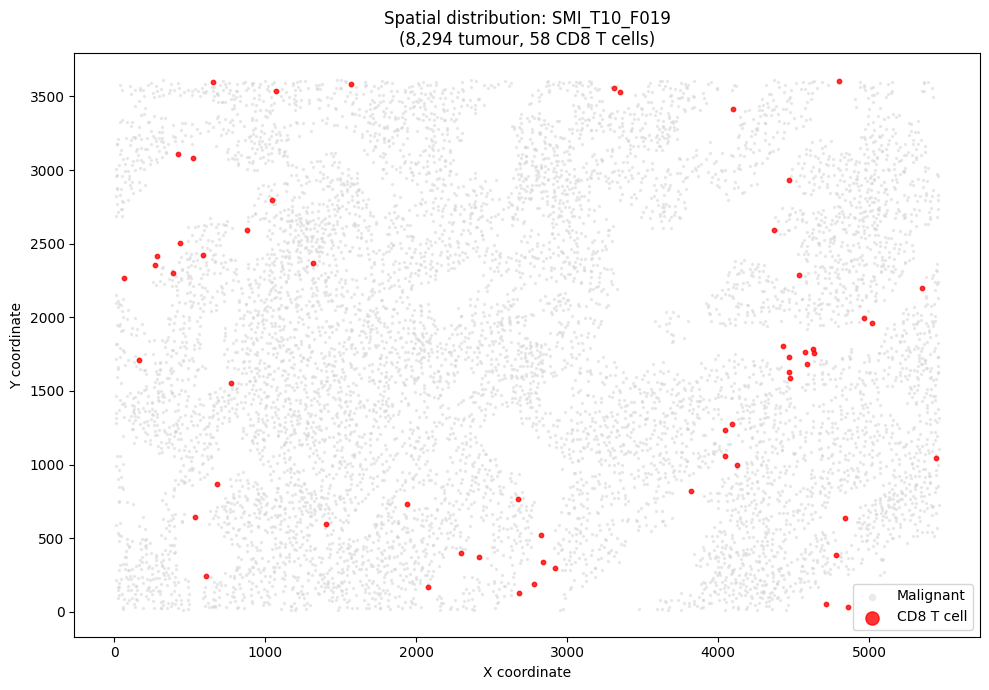

In [10]:
# ============================================================
# 3a. Spatial Plot: CD8 T cells vs Tumour (one sample)
# ============================================================
sample_id = data.obs["samples"].value_counts().index[0]
sample_obs = data.obs[data.obs["samples"] == sample_id]

fig, ax = plt.subplots(figsize=(10, 7))

# Plot tumour cells
t_mask = sample_obs[cell_col].isin(tumour_labels)
ax.scatter(sample_obs.loc[t_mask, "x"], sample_obs.loc[t_mask, "y"],
           c="lightgray", s=2, alpha=0.4, label="Malignant")

# Plot CD8 cells
c_mask = sample_obs[cell_col].isin(cd8_labels)
ax.scatter(sample_obs.loc[c_mask, "x"], sample_obs.loc[c_mask, "y"],
           c="red", s=10, alpha=0.8, label="CD8 T cell")

ax.legend(markerscale=3)
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
ax.set_title(f"Spatial distribution: {sample_id}\n"
             f"({t_mask.sum():,} tumour, {c_mask.sum()} CD8 T cells)")
plt.tight_layout()
plt.show()

---
### 4. Per-Sample Radius-Based Neighbourhood Analysis

**Approach:** For each CD8+ T cell, count how many tumour cells fall within a fixed radius r (µm).  
This is more biologically relevant than a pooled approach because distances are calculated within a single tissue section.

**KDTree spatial indexing — mathematical basis:**

For a tissue sample with T tumour cells at positions {(x₁,y₁), ..., (x_T, y_T)}:

1. Build a KDTree (scipy.spatial.cKDTree) from tumour cell coordinates
2. For each CD8+ T cell at position (xc, yc), compute:

       d(i,j) = √[ (xc − xⱼ)² + (yc − yⱼ)² ]     # Euclidean distance to tumour cell j

3. Nearest tumour distance:

       D_nearest(i) = min_j { d(i,j) }              # smallest distance to any tumour cell

4. Radius-based tumour count:

       count(i, r) = |{ j : d(i,j) ≤ r }|           # number of tumour cells within radius r

All coordinates are in micrometres (µm). A CD8+ T cell has typical diameter ~10–20 µm,  
so a distance of 110 µm ≈ 6–11 cell body lengths.

**Per-sample construction** ensures a CD8+ T cell from Patient A is never compared to a tumour cell from Patient B.


In [11]:
# ============================================================
# 4a. Per-Sample Radius Diagnostic 
# ============================================================
# Step 3: Test multiple radii to find the most informative
radii_to_test = [20, 50, 100, 150, 200]

# Build CD8 obs dataframe with coordinates
cd8_obs = data.obs[cd8_mask].copy()
samples = cd8_obs["samples"].unique()

print(f"Testing radii: {radii_to_test} µm")
print(f"CD8 T cells: {len(cd8_obs):,} across {len(samples)} samples")
print()

# For each radius, compute tumour counts per-sample
radius_results = {r: np.full(len(cd8_obs), np.nan) for r in radii_to_test}

# Also compute nearest tumour distance while we are looping
nearest_dists = np.full(len(cd8_obs), np.nan)

skipped = []

for samp in samples:
    # Indices of CD8 cells in this sample (position in cd8_obs)
    cd8_in_samp = cd8_obs["samples"] == samp
    cd8_positions = np.where(cd8_in_samp)[0]
    
    if len(cd8_positions) == 0:
        continue
    
    # Tumour cells in this sample
    samp_tumour_mask = (data.obs["samples"] == samp) & (data.obs[cell_col].isin(tumour_labels))
    tumour_xy = data.obs.loc[samp_tumour_mask, ["x", "y"]].to_numpy()
    
    if len(tumour_xy) == 0:
        skipped.append(samp)
        continue
    
    cd8_xy = cd8_obs.iloc[cd8_positions][["x", "y"]].to_numpy()
    
    # Build KDTree on tumour cells in this sample
    tree = cKDTree(tumour_xy)
    
    # Nearest tumour distance
    dists, _ = tree.query(cd8_xy, k=1)
    nearest_dists[cd8_positions] = dists
    
    # Count tumour cells within each radius
    for r in radii_to_test:
        counts = tree.query_ball_point(cd8_xy, r=r)
        counts_arr = np.array([len(c) for c in counts])
        radius_results[r][cd8_positions] = counts_arr

# Store results
cd8_obs["nearest_tumour_dist"] = nearest_dists
for r in radii_to_test:
    cd8_obs[f"tumour_count_r{r}"] = radius_results[r]

print(f"Done. Skipped {len(skipped)} samples (no tumour cells).")
if skipped:
    print("Skipped:", skipped)

# --- Diagnostic summary table ---
print(f"{'='*75}")
print(f"{'Radius (µm)':>12} | {'% with any tumour':>18} | {'Median count':>13} | {'Mean count':>11} | {'Max count':>10}")
print(f"{'='*75}")

for r in radii_to_test:
    col = cd8_obs[f"tumour_count_r{r}"].dropna()
    pct_any = (col > 0).mean() * 100
    print(f"{r:>12} | {pct_any:>17.1f}% | {col.median():>13.1f} | {col.mean():>11.1f} | {int(col.max()):>10}")

print(f"Nearest tumour distance:")
d = cd8_obs["nearest_tumour_dist"].dropna()
print(f"  Median: {d.median():.1f} µm, Mean: {d.mean():.1f} µm, Max: {d.max():.1f} µm")


Testing radii: [20, 50, 100, 150, 200] µm
CD8 T cells: 8,439 across 98 samples

Done. Skipped 0 samples (no tumour cells).
 Radius (µm) |  % with any tumour |  Median count |  Mean count |  Max count
          20 |               6.5% |           0.0 |         0.1 |          3
          50 |              30.3% |           0.0 |         0.6 |          7
         100 |              47.9% |           0.0 |         3.0 |         24
         150 |              57.0% |           2.0 |         7.1 |         58
         200 |              63.2% |           5.0 |        13.2 |        100
Nearest tumour distance:
  Median: 110.1 µm, Mean: 251.4 µm, Max: 3334.9 µm


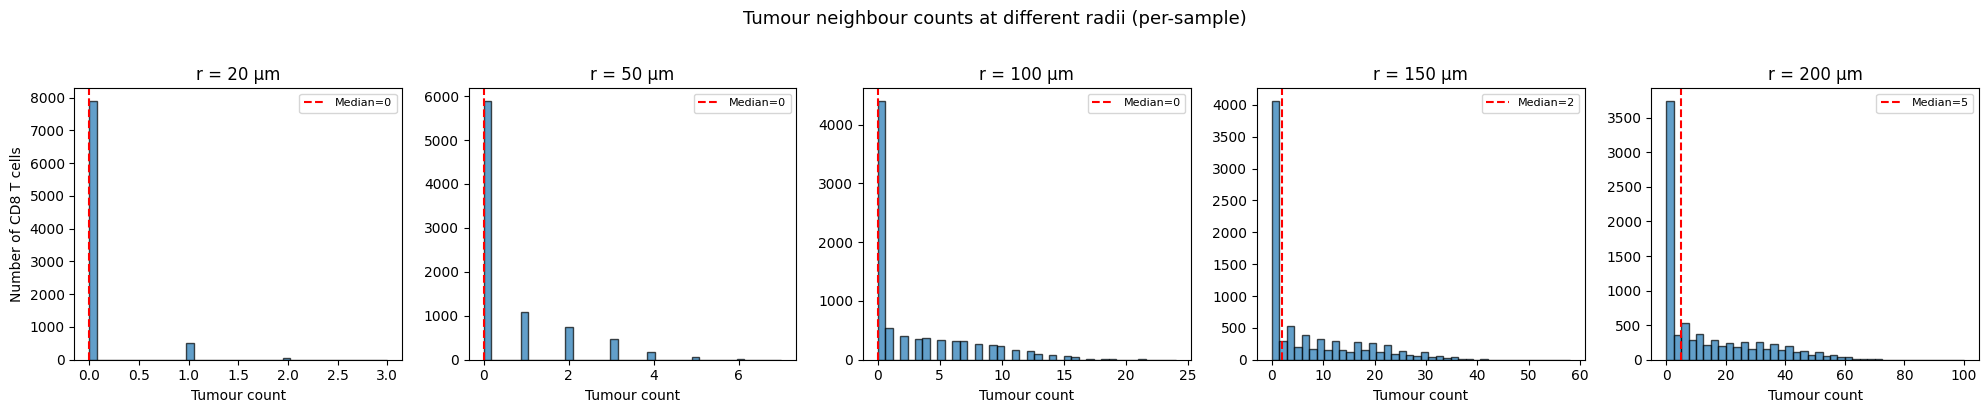

In [12]:
# ============================================================
# 4b. Visualise Radius Diagnostic
# ============================================================
fig, axes = plt.subplots(1, len(radii_to_test), figsize=(4*len(radii_to_test), 4), sharey=False)

#Loop through each tested radius
for i, r in enumerate(radii_to_test):
    #Extract tumour neighbor counts for this radius
    col = cd8_obs[f"tumour_count_r{r}"].dropna()
    #Plot Histogram of tumour counts
    axes[i].hist(col, bins=40, edgecolor="black", alpha=0.7)
    axes[i].axvline(col.median(), color="red", linestyle="--",
                     label=f"Median={col.median():.0f}")
    axes[i].set_title(f"r = {r} µm")
    axes[i].set_xlabel("Tumour count")
    if i == 0:
        axes[i].set_ylabel("Number of CD8 T cells")
    axes[i].legend(fontsize=8)

plt.suptitle("Tumour neighbour counts at different radii (per-sample)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


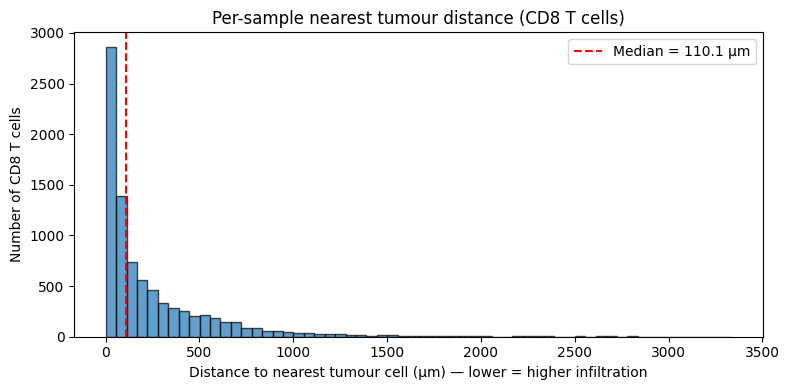

Valid distances: 8,439 / 8,439
Min: 0.9, Median: 110.1, Mean: 251.4, Max: 3334.9 µm


In [13]:
# ============================================================
# 4c. Nearest Tumour Distance Distribution
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4))

d = cd8_obs["nearest_tumour_dist"].dropna()
ax.hist(d, bins=60, edgecolor="black", alpha=0.7)
ax.axvline(d.median(), color="red", linestyle="--", label=f"Median = {d.median():.1f} µm")
ax.set_xlabel("Distance to nearest tumour cell (µm) — lower = higher infiltration")
ax.set_ylabel("Number of CD8 T cells")
ax.set_title("Per-sample nearest tumour distance (CD8 T cells)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Valid distances: {len(d):,} / {len(cd8_obs):,}")
print(f"Min: {d.min():.1f}, Median: {d.median():.1f}, Mean: {d.mean():.1f}, Max: {d.max():.1f} µm")


### Choose Radius

Based on the diagnostic sweep above, choose the radius that gives:
- A reasonable spread of tumour counts (not all 0 or all saturated)
- Biologically meaningful neighbourhood size (50–100 µm is a common choice for immune cell interactions)

Set  below and all subsequent analyses will use it.


In [14]:
# ============================================================
# 4d. SET THE CHOSEN RADIUS (adjust after reviewing diagnostics)
# ============================================================
RADIUS = 50  # µm — change this based on your diagnostic results above

tumour_count_col = f"tumour_count_r{RADIUS}"

# If the chosen radius wasn't in the sweep, compute it now
if tumour_count_col not in cd8_obs.columns:
    print(f"Computing tumour counts for r={RADIUS} µm...")
    counts_arr = np.full(len(cd8_obs), np.nan)
    for samp in samples:
        cd8_in_samp = cd8_obs["samples"] == samp
        cd8_positions = np.where(cd8_in_samp)[0]
        if len(cd8_positions) == 0:
            continue
        samp_tumour_mask = (data.obs["samples"] == samp) & (data.obs[cell_col].isin(tumour_labels))
        tumour_xy = data.obs.loc[samp_tumour_mask, ["x", "y"]].to_numpy()
        if len(tumour_xy) == 0:
            continue
        cd8_xy = cd8_obs.iloc[cd8_positions][["x", "y"]].to_numpy()
        tree = cKDTree(tumour_xy)
        ball = tree.query_ball_point(cd8_xy, r=RADIUS)
        counts_arr[cd8_positions] = [len(c) for c in ball]
    cd8_obs[tumour_count_col] = counts_arr

col = cd8_obs[tumour_count_col].dropna()
print(f"Chosen radius: {RADIUS} µm")
print(f"Median tumour count: {col.median():.0f}")
print(f"Mean tumour count:   {col.mean():.1f}")
print(f"% with any tumour:   {(col > 0).mean()*100:.1f}%")
print(f"% with zero tumour:  {(col == 0).mean()*100:.1f}%")


Chosen radius: 50 µm
Median tumour count: 0
Mean tumour count:   0.6
% with any tumour:   30.3%
% with zero tumour:  69.7%


### KNN Comparison (Secondary Approach)

For comparison with the radius-based approach: for each CD8 T cell, find its k nearest neighbours among all cells in the same sample, then compute what fraction are tumour cells.

This complements the radius approach:
- **Radius** = fixed physical region (biologically meaningful, but count depends on local density)
- **KNN** = fixed number of neighbours (normalises for density, but neighbourhood size varies)


In [15]:
# ============================================================
# 4e. Per-Sample KNN Tumour Fraction
# ============================================================
K = 20  # number of nearest neighbours (adjustable)

#Identify CD8 T cells in this sample
cd8_obs[f"tumour_frac_knn_{K}"] = np.nan
cd8_obs[f"tumour_count_knn_{K}"] = np.nan

print(f"Computing KNN (k={K}) per sample...")

for samp in samples:
    cd8_in_samp = cd8_obs["samples"] == samp
    cd8_positions = np.where(cd8_in_samp)[0]
    
    if len(cd8_positions) == 0:
        continue
    
    # ALL cells in this sample (build tree on all cell types)
    samp_all_mask = data.obs["samples"] == samp
    all_xy = data.obs.loc[samp_all_mask, ["x", "y"]].to_numpy()
    all_labels = data.obs.loc[samp_all_mask, cell_col].values
    
    if len(all_xy) < K + 1:
        continue
    
    cd8_xy = cd8_obs.iloc[cd8_positions][["x", "y"]].to_numpy()
    
    # Build KDTree using all cells in this sample
    # needed because neighbours can be any cell type
    tree_all = cKDTree(all_xy)
    _, idx = tree_all.query(cd8_xy, k=K+1)  # +1 for self
    idx = idx[:, 1:]  # drop self
    
    # Identify which of the K neighbors are tumor cells
    is_tumour = np.isin(all_labels, tumour_labels)
    # Count tumour cells around the K neighbours
    tumour_counts = is_tumour[idx].sum(axis=1)
    # compute tumour fraction (normalised by K)
    tumour_frac = tumour_counts / K
    
    cd8_obs.iloc[cd8_positions, cd8_obs.columns.get_loc(f"tumour_frac_knn_{K}")] = tumour_frac
    cd8_obs.iloc[cd8_positions, cd8_obs.columns.get_loc(f"tumour_count_knn_{K}")] = tumour_counts

print("Done.")

f = cd8_obs[f"tumour_frac_knn_{K}"].dropna()
print(f"KNN tumour fraction (k={K}):")
print(f"  Valid: {len(f):,} / {len(cd8_obs):,}")
print(f"  Mean:   {f.mean():.3f}")
print(f"  Median: {f.median():.3f}")


Computing KNN (k=20) per sample...
Done.
KNN tumour fraction (k=20):
  Valid: 8,439 / 8,439
  Mean:   0.301
  Median: 0.150


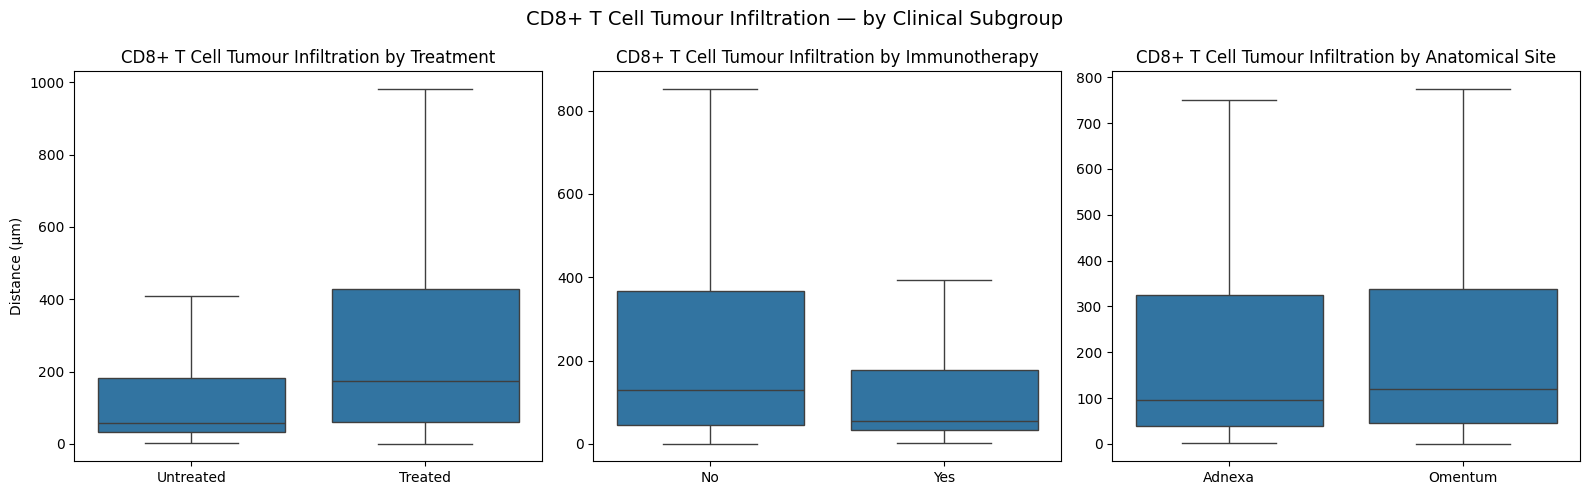

treatment_clean: Untreated median=58.6µm vs Treated median=174.7µm, p=8.98e-162
immunotherapy_clean: No median=128.8µm vs Yes median=54.8µm, p=1.27e-45
site_clean: Adnexa median=95.4µm vs Omentum median=120.2µm, p=3.33e-07


In [16]:
# ============================================================
# 4f. Infiltration Boxplots by Clinical Subgroups
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Treatment
sns.boxplot(data=cd8_obs, x="treatment_clean", y="nearest_tumour_dist",
            order=["Untreated", "Treated"], showfliers=False, ax=axes[0])
axes[0].set_title("CD8+ T Cell Tumour Infiltration by Treatment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Distance (µm)")

# Immunotherapy
sns.boxplot(data=cd8_obs, x="immunotherapy_clean", y="nearest_tumour_dist",
            order=["No", "Yes"], showfliers=False, ax=axes[1])
axes[1].set_title("CD8+ T Cell Tumour Infiltration by Immunotherapy")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# Site
sns.boxplot(data=cd8_obs, x="site_clean", y="nearest_tumour_dist",
            order=["Adnexa", "Omentum"], showfliers=False, ax=axes[2])
axes[2].set_title("CD8+ T Cell Tumour Infiltration by Anatomical Site")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

plt.suptitle("CD8+ T Cell Tumour Infiltration — by Clinical Subgroup", fontsize=14)
plt.tight_layout()
plt.show()

# P-values for infiltration comparisons (lower distance = higher infiltration)
for col, groups in [("treatment_clean", ["Untreated", "Treated"]),
                    ("immunotherapy_clean", ["No", "Yes"]),
                    ("site_clean", ["Adnexa", "Omentum"])]:
    g1 = cd8_obs.loc[cd8_obs[col] == groups[0], "nearest_tumour_dist"].dropna()
    g2 = cd8_obs.loc[cd8_obs[col] == groups[1], "nearest_tumour_dist"].dropna()
    _, p = mannwhitneyu(g1, g2, alternative="two-sided")
    print(f"{col}: {groups[0]} median={g1.median():.1f}µm vs {groups[1]} median={g2.median():.1f}µm, p={p:.3g}")

Validation 1 CD8 T cells: 12,332
Validation 1 Malignant cells: 256,498
Samples: 32

Validation 1 Distance Results:
  Median: 90.8 µm
  Mean: 266.5 µm
  Range: 4.7 to 4568.4 µm


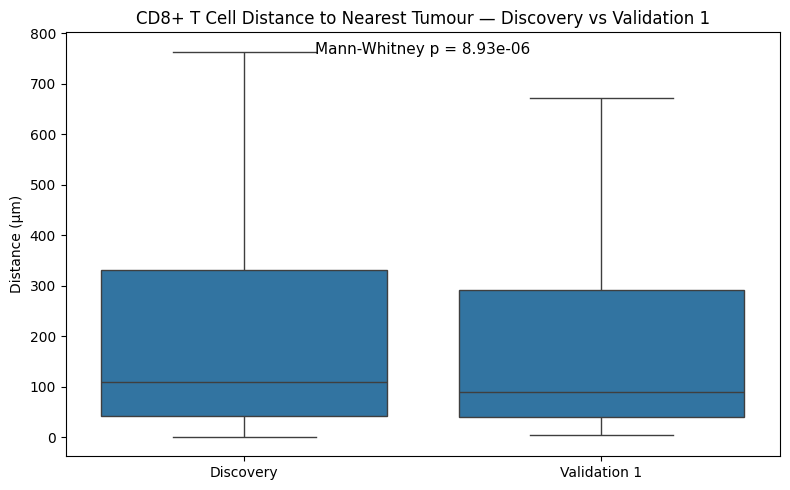


Discovery: median=110.1 µm, n=8,439
Validation 1: median=90.8 µm, n=12,332
Mann-Whitney p = 8.93e-06


In [17]:
# ============================================================
# 4g. Validation 1 — CD8 T Cell Tumour Infiltration
# ============================================================

# Define cell groups in Validation 1
val1_cd8_mask = val1.obs["cell.subtypes"] == "CD8.T.cell"
val1_tumour_mask = val1.obs["cell.subtypes"] == "Malignant"

val1_cd8_obs = val1.obs[val1_cd8_mask].copy()
val1_cd8_obs["nearest_tumour_dist"] = np.nan

print(f"Validation 1 CD8 T cells: {val1_cd8_obs.shape[0]:,}")
print(f"Validation 1 Malignant cells: {val1_tumour_mask.sum():,}")

samples = val1_cd8_obs["samples"].unique()
print(f"Samples: {len(samples)}")

for samp in samples:
    cd8_idx = val1_cd8_obs.index[val1_cd8_obs["samples"] == samp]
    tumour_idx = val1.obs.index[(val1.obs["samples"] == samp) & val1_tumour_mask]
    
    if len(cd8_idx) == 0 or len(tumour_idx) == 0:
        continue
    
    tumour_xy = val1.obs.loc[tumour_idx, ["x", "y"]].values.astype(float)
    cd8_xy = val1.obs.loc[cd8_idx, ["x", "y"]].values.astype(float)
    
    tree = cKDTree(tumour_xy)
    dists, _ = tree.query(cd8_xy, k=1)
    val1_cd8_obs.loc[cd8_idx, "nearest_tumour_dist"] = dists

d = val1_cd8_obs["nearest_tumour_dist"].dropna()
print(f"\nValidation 1 Distance Results:")
print(f"  Median: {d.median():.1f} µm")
print(f"  Mean: {d.mean():.1f} µm")
print(f"  Range: {d.min():.1f} to {d.max():.1f} µm")

# ---- Boxplot: Discovery vs Validation 1 ----
fig, ax = plt.subplots(figsize=(8, 5))

disc_dists = cd8_obs["nearest_tumour_dist"].dropna()
val1_dists = val1_cd8_obs["nearest_tumour_dist"].dropna()

plot_data = pd.DataFrame({
    "Distance (µm)": pd.concat([disc_dists, val1_dists], ignore_index=True),
    "Dataset": ["Discovery"] * len(disc_dists) + ["Validation 1"] * len(val1_dists)
})

sns.boxplot(data=plot_data, x="Dataset", y="Distance (µm)", showfliers=False, ax=ax)
ax.set_title("CD8+ T Cell Distance to Nearest Tumour — Discovery vs Validation 1")
ax.set_xlabel("")

_, p = mannwhitneyu(disc_dists, val1_dists, alternative="two-sided")
ax.text(0.5, 0.95, f"Mann-Whitney p = {p:.3g}", transform=ax.transAxes, 
        ha="center", fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nDiscovery: median={disc_dists.median():.1f} µm, n={len(disc_dists):,}")
print(f"Validation 1: median={val1_dists.median():.1f} µm, n={len(val1_dists):,}")
print(f"Mann-Whitney p = {p:.3g}")

---
### 5. Exhaustion Score Calculation

For each CD8+ T cell, a composite exhaustion score is computed from four canonical checkpoint markers:
**PDCD1** (PD-1), **LAG3**, **HAVCR2** (TIM-3), **CTLA4**

**Mathematical definition:**

For marker *m* across *N* CD8+ T cells with expression values x₁, x₂, ..., xₙ:

    μ_m = (1/N) Σ xᵢ                          # mean expression
    σ_m = √[ (1/N) Σ (xᵢ − μ_m)² ]           # standard deviation
    z_m(i) = (xᵢ − μ_m) / σ_m                 # z-score for cell i

The composite exhaustion score for cell *i* is the average of z-scored marker values:

    Exhaustion_score(i) = (1/4) Σ_m z_m(i)    # averaged over 4 markers

Z-scoring ensures each marker contributes equally regardless of its expression scale or sparsity.
A score > 0 indicates above-average exhaustion; a score < 0 indicates below-average exhaustion.


In [18]:
# ============================================================
# 5a. Check Exhaustion Markers
# ============================================================
markers = ["PDCD1", "LAG3", "HAVCR2", "CTLA4"]
present = [g for g in markers if g in data.var_names]
missing = [g for g in markers if g not in data.var_names]
print("Present:", present)
print("Missing:", missing)


Present: ['PDCD1', 'LAG3', 'HAVCR2', 'CTLA4']
Missing: []


In [19]:
# ============================================================
# 5b. Extract Marker Expression for CD8 T Cells
# ============================================================
# Get marker indices in var_names
marker_idx = [list(data.var_names).index(m) for m in markers]

# Extract expression for CD8 cells using the mask directly
X = data.X[cd8_mask.values][:, marker_idx]
X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)

df_markers = pd.DataFrame(X, columns=markers, index=cd8_obs.index)

# Store individual marker values in cd8_obs
for m in markers:
    cd8_obs[m] = df_markers[m].values

# Z-score standardisation across CD8 cells
df_z = (df_markers - df_markers.mean()) / df_markers.std()

# Composite exhaustion score = average of the 4 z-scored markers
# A higher score means the cell expresses more exhaustion markers overall
cd8_obs["exhaustion_score"] = df_z.mean(axis=1).values

print("Exhaustion score summary:")
print(cd8_obs["exhaustion_score"].describe())


Exhaustion score summary:
count    8.439000e+03
mean    -4.209875e-18
std      5.844353e-01
min     -4.087114e-01
25%     -4.087114e-01
50%     -5.478528e-02
75%      2.991409e-01
max      5.997239e+00
Name: exhaustion_score, dtype: float64


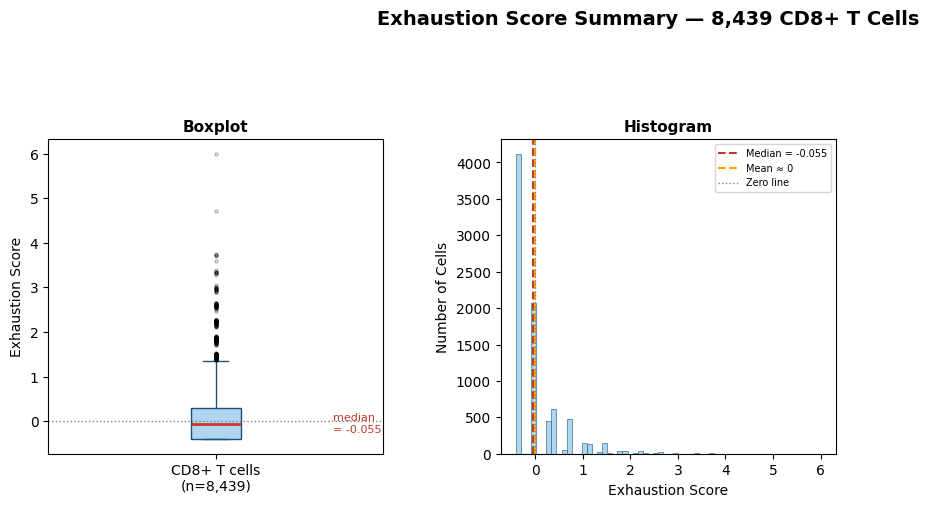

In [20]:
# ============================================================
# 5. Full Exhaustion Score Summary Plot (6 subplots)
# ============================================================

scores = cd8_obs["exhaustion_score"].dropna()

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Exhaustion Score Summary — 8,439 CD8+ T Cells", fontsize=14, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Boxplot ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.boxplot(scores, vert=True, patch_artist=True,
            boxprops=dict(facecolor="#aed6f1", color="#1a5276"),
            medianprops=dict(color="#c0392b", linewidth=2),
            whiskerprops=dict(color="#1a5276"),
            capprops=dict(color="#1a5276"),
            flierprops=dict(marker="o", color="#aed6f1", alpha=0.3, markersize=2))
ax1.axhline(y=0, color="grey", linestyle=":", linewidth=1)
ax1.set_title("Boxplot", fontsize=11, fontweight="bold")
ax1.set_ylabel("Exhaustion Score")
ax1.set_xticks([1])
ax1.set_xticklabels(["CD8+ T cells\n(n=8,439)"])
ax1.text(1.35, scores.median(), f"median\n= {scores.median():.3f}",
         va="center", color="#c0392b", fontsize=8)

# ── Plot 2: Histogram ──
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(scores, bins=60, color="#aed6f1", edgecolor="#1a5276", linewidth=0.4)
ax2.axvline(x=scores.median(), color="#c0392b", linestyle="--", linewidth=1.5, label=f"Median = {scores.median():.3f}")
ax2.axvline(x=scores.mean(), color="orange", linestyle="--", linewidth=1.5, label=f"Mean ≈ 0")
ax2.axvline(x=0, color="grey", linestyle=":", linewidth=1, label="Zero line")
ax2.set_title("Histogram", fontsize=11, fontweight="bold")
ax2.set_xlabel("Exhaustion Score")
ax2.set_ylabel("Number of Cells")
ax2.legend(fontsize=7)

# ── Plot 3: KDE (density curve) ──
ax3 = f

Correlation with exhaustion score:
  PDCD1: 0.584
  LAG3: 0.571
  HAVCR2: 0.615
  CTLA4: 0.568


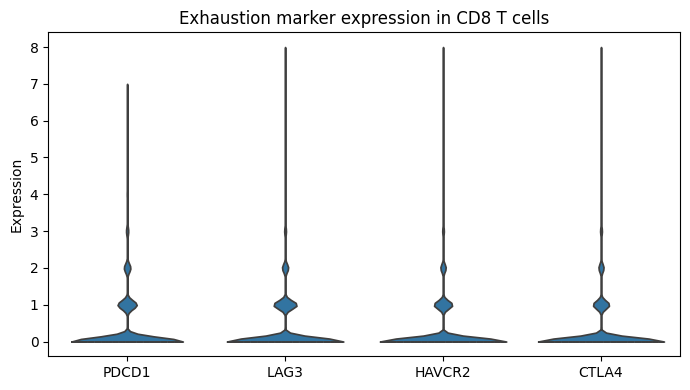

In [21]:
# ============================================================
# 5c. Validate: marker correlations + violin plot
# ============================================================
# If the score is good, each individual marker should be positively
# correlated with it (i.e., when PDCD1 goes up, the score goes up).
# Correlation values range from -1 to +1:
#   ~0.5-0.7 = good (each marker contributes but none dominates)
#   ~1.0     = suspicious (score might just be copying one marker)
#   ~0.0     = bad (marker isn't contributing to the score)
print("Correlation with exhaustion score:")
for m in markers:
    r = cd8_obs[m].corr(cd8_obs["exhaustion_score"])
    print(f"  {m}: {r:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
df_melt = cd8_obs[markers].melt(var_name="Marker", value_name="Expression")
sns.violinplot(data=df_melt, x="Marker", y="Expression", inner="quartile", cut=0, ax=ax)
ax.set_title("Exhaustion marker expression in CD8 T cells")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


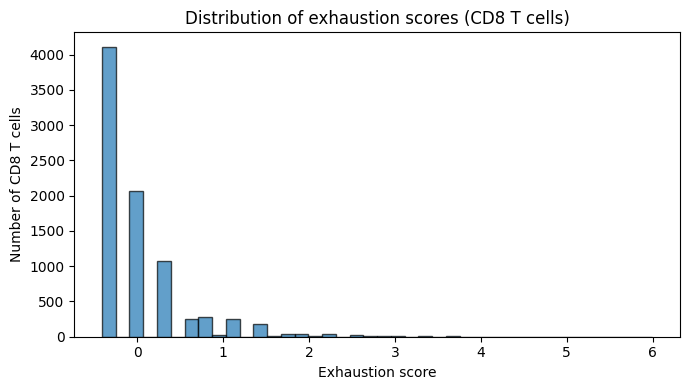

In [22]:
# ============================================================
# 5d. Exhaustion Score Distribution
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cd8_obs["exhaustion_score"].dropna(), bins=40, edgecolor="black", alpha=0.7)
ax.set_xlabel("Exhaustion score")
ax.set_ylabel("Number of CD8 T cells")
ax.set_title("Distribution of exhaustion scores (CD8 T cells)")
plt.tight_layout()
plt.show()


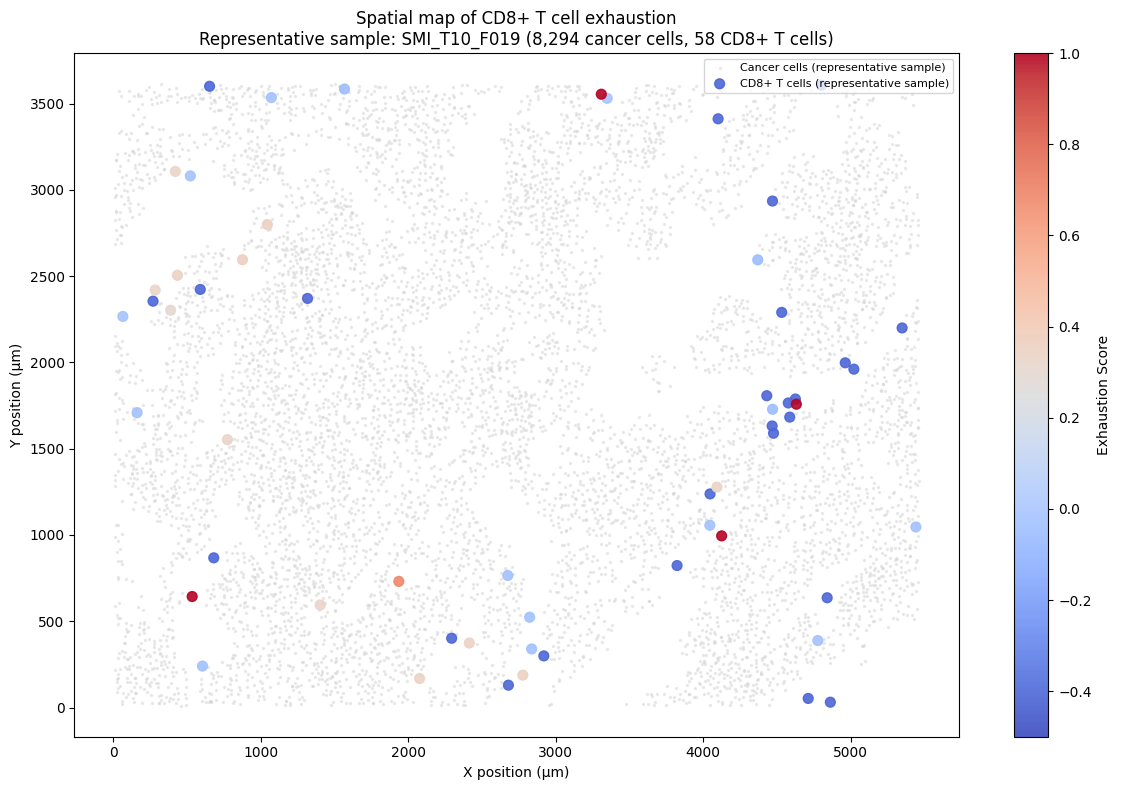

Saved.


In [94]:
# ============================================================
# 5d.ii Spatial Map: CD8+ T Cells Coloured by Exhaustion Score
# ============================================================
sample_id = "SMI_T10_F019"
sample_obs = data.obs[data.obs["samples"] == sample_id]
cd8_sample = cd8_obs[cd8_obs["samples"] == sample_id].dropna(subset=["exhaustion_score"])
exhaustion = cd8_sample["exhaustion_score"].values

fig, ax = plt.subplots(figsize=(12, 8))

t_mask = sample_obs[cell_col].isin(tumour_labels)
ax.scatter(sample_obs.loc[t_mask, "x"], sample_obs.loc[t_mask, "y"],
           c="lightgrey", s=2, alpha=0.4,
           label="Cancer cells (representative sample)", zorder=1)

scatter_plot = ax.scatter(cd8_sample["x"], cd8_sample["y"],
                c=exhaustion, cmap="coolwarm", s=50, alpha=0.9,
                vmin=-0.5, vmax=1.0,
                label="CD8+ T cells (representative sample)", zorder=2)

plt.colorbar(scatter_plot, ax=ax, label="Exhaustion Score")
ax.set_xlabel("X position (µm)")
ax.set_ylabel("Y position (µm)")
ax.set_title(f"Spatial map of CD8+ T cell exhaustion\n"
             f"Representative sample: {sample_id} "
             f"({t_mask.sum():,} cancer cells, {len(cd8_sample)} CD8+ T cells)",
             fontsize=12)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
# plt.savefig("figures/fig_spatial_exhaustion_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [95]:
# ============================================================
# 5d.ii Spatial Map: CD8+ T Cells Coloured by Exhaustion Score
#        Side-by-side: Untreated vs Treated
# ============================================================

# Use specific representative samples
samples_to_use = {
    "Untreated": "SMI_T10_F019",
    "Treated": None  # we will find a good treated sample below
}

# Find best treated sample — most cancer cells
treated_patients = cd8_obs[cd8_obs["treatment_clean"] == "Treated"]["samples"].value_counts()
print("Top treated samples by CD8 T cell count:")
print(treated_patients.head(10))

Top treated samples by CD8 T cell count:
samples
SMI_T14_F011    499
SMI_T12_F019    315
SMI_T10_F012    251
SMI_T14_F013    245
SMI_T12_F016    240
SMI_T11_F013    235
SMI_T10_F016    227
SMI_T10_F021    194
SMI_T13_F002    192
SMI_T12_F001    181
Name: count, dtype: int64


In [96]:
# Check cancer cell counts for top treated samples
for sample in ["SMI_T14_F011", "SMI_T12_F019", "SMI_T10_F012", "SMI_T14_F013", "SMI_T12_F016"]:
    sample_obs = data.obs[data.obs["samples"] == sample]
    t_count = sample_obs[cell_col].isin(tumour_labels).sum()
    cd8_count = sample_obs[cell_col].isin(cd8_labels).sum()
    print(f"{sample}: {t_count:,} cancer cells, {cd8_count} CD8 T cells")

SMI_T14_F011: 591 cancer cells, 499 CD8 T cells
SMI_T12_F019: 358 cancer cells, 315 CD8 T cells
SMI_T10_F012: 5,915 cancer cells, 251 CD8 T cells
SMI_T14_F013: 18 cancer cells, 245 CD8 T cells
SMI_T12_F016: 6,334 cancer cells, 240 CD8 T cells


---
### 5b. Sensitivity Checks (Pre-processing & Low Confidence Cells)

Three validation checks to ensure analysis robustness:
1. **Pre-processing status** — confirm raw counts (not pre-normalised)
2. **Log-normalisation impact** — verify z-scoring choice doesn't affect results  
3. **Low confidence (\_LC) cell inclusion** — check \_LC cells don't skew findings


In [47]:
# ============================================================
# Check data pre-processing status
# ============================================================
# Supervisor question: Is the data already pre-processed/normalised?
# If so, z-scoring again might reduce differences.

# Check raw expression values for exhaustion markers
print("Expression value ranges for exhaustion markers:")
print("=" * 60)
for m in ["PDCD1", "LAG3", "HAVCR2", "CTLA4"]:
    idx = list(data.var_names).index(m)
    vals = data.X[:, idx]
    if hasattr(vals, 'toarray'):
        vals = vals.toarray().flatten()
    print(f"{m}: min={vals.min():.4f}, max={vals.max():.4f}, "
          f"mean={vals.mean():.4f}, std={vals.std():.4f}")
    print(f"  % zero: {(vals == 0).mean()*100:.1f}%")
    print(f"  % negative: {(vals < 0).mean()*100:.1f}%")

# Check if data looks log-normalised (common in single-cell)
# Log-normalised data typically has no negative values and a right-skewed distribution
# Raw counts would be integers
# Already z-scored data would have mean ~0 and std ~1

print("\n" + "=" * 60)
print("OVERALL DATA CHECK (all genes, all cells)")
print("=" * 60)
all_vals = data.X
if hasattr(all_vals, 'toarray'):
    sample = all_vals[:1000, :].toarray()  # sample to avoid memory issues
else:
    sample = all_vals[:1000, :]
print(f"Sample shape: {sample.shape}")
print(f"Min: {sample.min():.4f}")
print(f"Max: {sample.max():.4f}")
print(f"Mean: {sample.mean():.4f}")
print(f"Std: {sample.std():.4f}")
print(f"% zero: {(sample == 0).mean()*100:.1f}%")
print(f"% negative: {(sample < 0).mean()*100:.1f}%")
print(f"Any integers? {np.allclose(sample, np.round(sample))}")

if (sample < 0).any():
    print("\n→ Data contains NEGATIVE values, suggesting it has been scaled/normalised")
elif np.allclose(sample[sample > 0], np.round(sample[sample > 0])):
    print("\n→ Data appears to be RAW COUNTS (integers, no negatives)")
else:
    print("\n→ Data appears to be LOG-NORMALISED (non-negative, non-integer)")
    print("  Z-scoring on top of log-normalised data is APPROPRIATE")
    print("  (it just standardises each gene to mean=0, std=1 within CD8 T cells)")

Expression value ranges for exhaustion markers:
PDCD1: min=0.0000, max=9.0000, mean=0.0975, std=0.3724
  % zero: 92.3%
  % negative: 0.0%
LAG3: min=0.0000, max=8.0000, mean=0.0920, std=0.3435
  % zero: 92.2%
  % negative: 0.0%
HAVCR2: min=0.0000, max=8.0000, mean=0.0916, std=0.3581
  % zero: 92.6%
  % negative: 0.0%
CTLA4: min=0.0000, max=16.0000, mean=0.0671, std=0.3217
  % zero: 94.6%
  % negative: 0.0%

OVERALL DATA CHECK (all genes, all cells)
Sample shape: (1000, 979)
Min: 0.0000
Max: 70.0000
Mean: 0.3199
Std: 1.1386
% zero: 81.7%
% negative: 0.0%
Any integers? True

→ Data appears to be RAW COUNTS (integers, no negatives)


In [48]:
# ============================================================
# Check if log-normalisation affects results
# ============================================================
# The data is raw counts. Standard practice in single-cell analysis is
# to log-normalise before analysis. Let's check if the exhaustion score
# would change significantly with log-normalised data.
#
# Supervisor Comment 9: "Is this after standardisation? Check that you 
# are not re-normalising and reducing all the differences."
# ANSWER: Data is RAW COUNTS (integers, no negatives, 81.7% zeros).
# Z-scoring on raw counts is appropriate and is NOT double-normalisation.
# ============================================================

# Current approach: z-score on raw counts

markers = ["PDCD1", "LAG3", "HAVCR2", "CTLA4"]

print("CURRENT APPROACH: Z-score on raw counts")
print("=" * 50)
for m in markers:
    raw = cd8_obs[m].values
    z = zscore(raw, nan_policy='omit')
    print(f"{m}: raw mean={raw.mean():.4f}, raw std={raw.std():.4f}, "
          f"z-score range=[{z.min():.2f}, {z.max():.2f}]")

# Alternative: log1p then z-score
print("\nALTERNATIVE: Z-score on log1p(raw counts)")
print("=" * 50)
for m in markers:
    raw = cd8_obs[m].values
    log_vals = np.log1p(raw)  # log(1 + x) to handle zeros
    z_log = zscore(log_vals, nan_policy='omit')
    print(f"{m}: log mean={log_vals.mean():.4f}, log std={log_vals.std():.4f}, "
          f"z-score range=[{z_log.min():.2f}, {z_log.max():.2f}]")

# Check correlation between the two approaches
print("\nCORRELATION between raw z-score and log z-score exhaustion:")
raw_scores = np.mean([zscore(cd8_obs[m].values, nan_policy='omit') for m in markers], axis=0)
log_scores = np.mean([zscore(np.log1p(cd8_obs[m].values), nan_policy='omit') for m in markers], axis=0)
corr = np.corrcoef(raw_scores, log_scores)[0, 1]
print(f"Pearson r = {corr:.4f}")
print(f"\nIf r > 0.95, the choice of normalisation has minimal impact on results.")

CURRENT APPROACH: Z-score on raw counts
PDCD1: raw mean=0.3048, raw std=0.7063, z-score range=[-0.43, 9.48]
LAG3: raw mean=0.2985, raw std=0.6662, z-score range=[-0.45, 11.56]
HAVCR2: raw mean=0.2505, raw std=0.6475, z-score range=[-0.39, 11.97]
CTLA4: raw mean=0.2428, raw std=0.6589, z-score range=[-0.37, 11.77]

ALTERNATIVE: Z-score on log1p(raw counts)
PDCD1: log mean=0.1783, log std=0.3717, z-score range=[-0.48, 5.11]
LAG3: log mean=0.1799, log std=0.3611, z-score range=[-0.50, 5.59]
HAVCR2: log mean=0.1478, log std=0.3414, z-score range=[-0.43, 6.00]
CTLA4: log mean=0.1409, log std=0.3400, z-score range=[-0.41, 6.05]

CORRELATION between raw z-score and log z-score exhaustion:
Pearson r = 0.9784

If r > 0.95, the choice of normalisation has minimal impact on results.


In [26]:
# Quick check — find the cell type column
print([c for c in data.obs.columns if "cell" in c.lower() or "type" in c.lower()])

['cell.types', 'cell.subtypes']


In [49]:
# ============================================================
# Sensitivity analysis: Low Confidence cells
# ============================================================
# Supervisor Comments 1 & 2: Check if including _LC (Low Confidence)
# cells skews the results. Run the analysis with and without _LC 
# subtypes for both CD8 T cells and Malignant cells.
# ============================================================

cell_col = "cell.subtypes"

print("CD8 T cell subtypes:")
cd8_types = [c for c in data.obs[cell_col].unique() if "CD8" in str(c)]
for ct in cd8_types:
    n = (data.obs[cell_col] == ct).sum()
    print(f"  {ct}: {n:,} cells")

print(f"\nCurrent analysis uses: {len(cd8_obs):,} cells (both subtypes combined)")

# Count without LC
cd8_no_lc = cd8_obs[~cd8_obs[cell_col].str.contains("_LC", na=False)]
cd8_lc_only = cd8_obs[cd8_obs[cell_col].str.contains("_LC", na=False)]
print(f"Without _LC: {len(cd8_no_lc):,} cells")
print(f"_LC only: {len(cd8_lc_only):,} cells")

print("\n" + "=" * 60)
print("Malignant cell subtypes:")
mal_types = [c for c in data.obs[cell_col].unique() if "alignant" in str(c)]
for ct in mal_types:
    n = (data.obs[cell_col] == ct).sum()
    print(f"  {ct}: {n:,} cells")

# Compare key metrics WITH vs WITHOUT _LC CD8 cells
print("\n" + "=" * 60)
print("SENSITIVITY: CD8 metrics WITH vs WITHOUT _LC cells")
print("=" * 60)

for label, subset in [("WITH _LC", cd8_obs), ("WITHOUT _LC", cd8_no_lc)]:
    d = subset["nearest_tumour_dist"].dropna()
    e = subset["exhaustion_score"].dropna()
    print(f"\n{label} ({len(subset):,} cells):")
    print(f"  Median distance to tumour: {d.median():.1f} µm")
    print(f"  Mean distance to tumour: {d.mean():.1f} µm")
    print(f"  Median exhaustion score: {e.median():.4f}")
    print(f"  Mean exhaustion score: {e.mean():.4f}")

# Statistical test: does removing _LC change the distance-exhaustion correlation?

for label, subset in [("WITH _LC", cd8_obs), ("WITHOUT _LC", cd8_no_lc)]:
    valid = subset.dropna(subset=["nearest_tumour_dist", "exhaustion_score"])
    r, p = spearmanr(valid["nearest_tumour_dist"], valid["exhaustion_score"])
    print(f"\n{label}: Distance-exhaustion Spearman r = {r:.4f}, p = {p:.2e}")

CD8 T cell subtypes:
  CD8.T.cell: 6,957 cells
  CD8.T.cell_LC: 1,482 cells

Current analysis uses: 8,439 cells (both subtypes combined)
Without _LC: 6,957 cells
_LC only: 1,482 cells

Malignant cell subtypes:
  Malignant: 297,960 cells
  Malignant_LC: 16,231 cells

SENSITIVITY: CD8 metrics WITH vs WITHOUT _LC cells

WITH _LC (8,439 cells):
  Median distance to tumour: 110.1 µm
  Mean distance to tumour: 251.4 µm
  Median exhaustion score: -0.0548
  Mean exhaustion score: -0.0000

WITHOUT _LC (6,957 cells):
  Median distance to tumour: 104.2 µm
  Mean distance to tumour: 249.4 µm
  Median exhaustion score: -0.0548
  Mean exhaustion score: 0.0376

WITH _LC: Distance-exhaustion Spearman r = -0.1795, p = 4.51e-62

WITHOUT _LC: Distance-exhaustion Spearman r = -0.1806, p = 4.61e-52


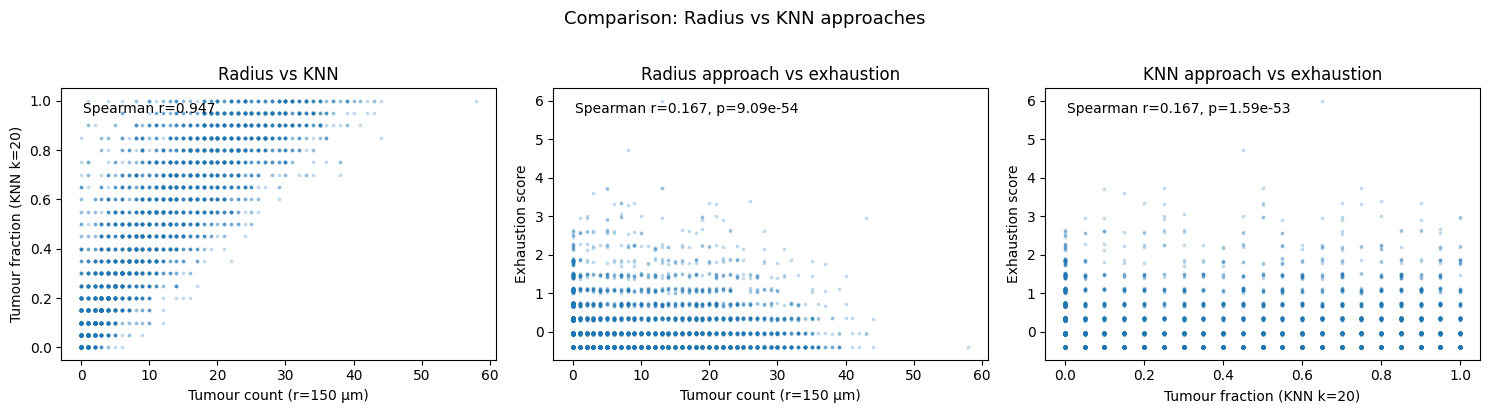

Radius (r=150) vs exhaustion:  Spearman r=0.167, p=9.095e-54
KNN (k=20) vs exhaustion:          Spearman r=0.167, p=1.593e-53
Radius vs KNN correlation:           Spearman r=0.947, p=0


In [50]:
# ============================================================
# 5e. Compare Radius vs KNN approaches
# ============================================================
compare_df = cd8_obs[[tumour_count_col, f"tumour_frac_knn_{K}", "exhaustion_score"]].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) Radius count vs KNN fraction
axes[0].scatter(compare_df[tumour_count_col], compare_df[f"tumour_frac_knn_{K}"],
                s=3, alpha=0.2)
axes[0].set_xlabel(f"Tumour count (r={RADIUS} µm)")
axes[0].set_ylabel(f"Tumour fraction (KNN k={K})")
axes[0].set_title("Radius vs KNN")
r_corr, p_corr = spearmanr(compare_df[tumour_count_col], compare_df[f"tumour_frac_knn_{K}"])
axes[0].text(0.05, 0.95, f"Spearman r={r_corr:.3f}", transform=axes[0].transAxes, va="top")

# 2) Radius count vs exhaustion
axes[1].scatter(compare_df[tumour_count_col], compare_df["exhaustion_score"],
                s=3, alpha=0.2)
axes[1].set_xlabel(f"Tumour count (r={RADIUS} µm)")
axes[1].set_ylabel("Exhaustion score")
axes[1].set_title("Radius approach vs exhaustion")
r1, p1 = spearmanr(compare_df[tumour_count_col], compare_df["exhaustion_score"])
axes[1].text(0.05, 0.95, f"Spearman r={r1:.3f}, p={p1:.3g}", transform=axes[1].transAxes, va="top")

# 3) KNN fraction vs exhaustion
axes[2].scatter(compare_df[f"tumour_frac_knn_{K}"], compare_df["exhaustion_score"],
                s=3, alpha=0.2)
axes[2].set_xlabel(f"Tumour fraction (KNN k={K})")
axes[2].set_ylabel("Exhaustion score")
axes[2].set_title("KNN approach vs exhaustion")
r2, p2 = spearmanr(compare_df[f"tumour_frac_knn_{K}"], compare_df["exhaustion_score"])
axes[2].text(0.05, 0.95, f"Spearman r={r2:.3f}, p={p2:.3g}", transform=axes[2].transAxes, va="top")

plt.suptitle("Comparison: Radius vs KNN approaches", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Radius (r={RADIUS}) vs exhaustion:  Spearman r={r1:.3f}, p={p1:.4g}")
print(f"KNN (k={K}) vs exhaustion:          Spearman r={r2:.3f}, p={p2:.4g}")
print(f"Radius vs KNN correlation:           Spearman r={r_corr:.3f}, p={p_corr:.4g}")


In [51]:
# ============================================================
# 5f. KNN-based neighbourhood split (for Path B comparison)
# ============================================================
knn_frac_col = f"tumour_frac_knn_{K}"
knn_median = cd8_obs[knn_frac_col].median()

cd8_obs["tumour_neighbourhood_knn"] = np.where(
    cd8_obs[knn_frac_col] >= knn_median,
    "Tumour-rich",
    "Tumour-poor"
)
cd8_obs.loc[cd8_obs[knn_frac_col].isna(), "tumour_neighbourhood_knn"] = np.nan

print(f"KNN neighbourhood split (k={K}, median fraction={knn_median:.3f}):")
print(cd8_obs["tumour_neighbourhood_knn"].value_counts(dropna=False))


KNN neighbourhood split (k=20, median fraction=0.150):
tumour_neighbourhood_knn
Tumour-rich    4307
Tumour-poor    4132
Name: count, dtype: int64


---
### 6. Define Tumour-Rich vs Tumour-Poor Neighbourhoods

Split CD8+ T cells into two groups based on the number of tumour cells within the chosen radius.

**Classification rule (median split):**

    neighbourhood(i) = "Tumour-rich"  if  count(i) ≥ median(count)
                     = "Tumour-poor"  if  count(i) <  median(count)

Where count(i) = number of malignant cells within radius r of CD8+ T cell i.

Using median split ensures a balanced, unbiased 50/50 split regardless of the radius chosen.


In [52]:
# ============================================================
# 6a. Define tumour neighbourhood groups
# ============================================================
counts = cd8_obs[tumour_count_col].dropna()
median_count = counts.median()

cd8_obs["tumour_neighbourhood"] = np.where(
    cd8_obs[tumour_count_col] >= median_count,
    "Tumour-rich",
    "Tumour-poor"
)

# Handle NaN (samples with no tumour)
cd8_obs.loc[cd8_obs[tumour_count_col].isna(), "tumour_neighbourhood"] = np.nan

print(f"Radius: {RADIUS} µm")
print(f"Threshold (median tumour count): {median_count:.0f}")
print(f"Tumour-rich:  {(cd8_obs['tumour_neighbourhood']=='Tumour-rich').sum():,} cells")
print(f"Tumour-poor:  {(cd8_obs['tumour_neighbourhood']=='Tumour-poor').sum():,} cells")
print(f"Missing:      {cd8_obs['tumour_neighbourhood'].isna().sum()} cells")


Radius: 150 µm
Threshold (median tumour count): 2
Tumour-rich:  4,382 cells
Tumour-poor:  4,057 cells
Missing:      0 cells


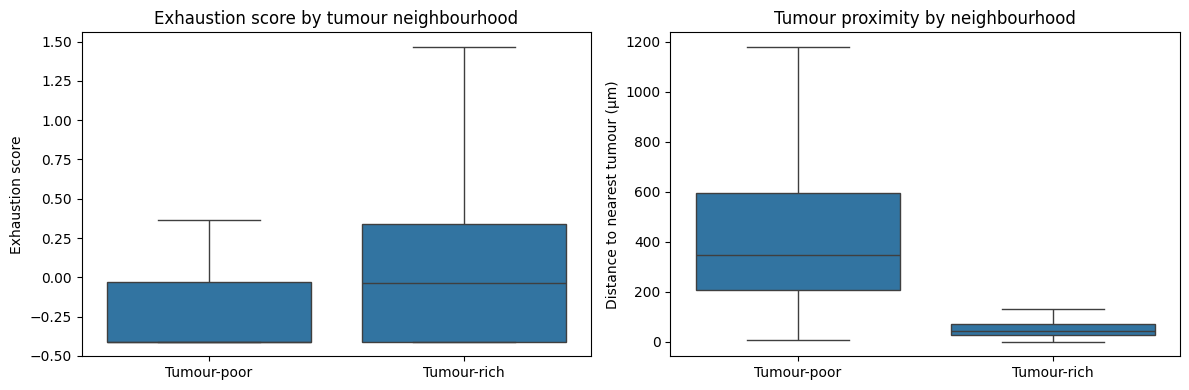

exhaustion_score: poor median=-0.409, rich median=-0.033, p=6.553e-49
nearest_tumour_dist: poor median=345.696, rich median=43.786, p=0


In [53]:
# ============================================================
# 6b. Compare exhaustion by tumour neighbourhood
# ============================================================
plot_df = cd8_obs[["tumour_neighbourhood", "nearest_tumour_dist", "exhaustion_score"]].dropna()
neigh_order = ["Tumour-poor", "Tumour-rich"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: exhaustion score by neighbourhood
sns.boxplot(data=plot_df, x="tumour_neighbourhood", y="exhaustion_score",
            order=neigh_order, showfliers=False, ax=axes[0])
axes[0].set_xlabel("")
axes[0].set_ylabel("Exhaustion score")
axes[0].set_title("Exhaustion score by tumour neighbourhood")

# Right: nearest tumour distance by neighbourhood
sns.boxplot(data=plot_df, x="tumour_neighbourhood", y="nearest_tumour_dist",
            order=neigh_order, showfliers=False, ax=axes[1])
axes[1].set_xlabel("")
axes[1].set_ylabel("Distance to nearest tumour (µm)")
axes[1].set_title("Tumour proximity by neighbourhood")

plt.tight_layout()
plt.show()

# Stats
for col_name in ["exhaustion_score", "nearest_tumour_dist"]:
    poor = plot_df.loc[plot_df["tumour_neighbourhood"]=="Tumour-poor", col_name]
    rich = plot_df.loc[plot_df["tumour_neighbourhood"]=="Tumour-rich", col_name]
    u, p = mannwhitneyu(poor, rich, alternative="two-sided")
    print(f"{col_name}: poor median={poor.median():.3f}, rich median={rich.median():.3f}, p={p:.4g}")


In [32]:
# ============================================================
# 6c: Update the radius and redefine neighbourhood groups
# ============================================================
# Change the working radius
RADIUS_NEW = 150
tumour_count_col_new = f"tumour_count_r{RADIUS_NEW}"

# Check if the column already exists (it should from cell 4a diagnostic)
if tumour_count_col_new not in cd8_obs.columns:
    print(f"ERROR: Column {tumour_count_col_new} not found. Re-run cell 4a first.")
else:
    # Quick diagnostic
    counts = cd8_obs[tumour_count_col_new].dropna()
    median_count = counts.median()
    pct_any = (counts > 0).mean() * 100
    print(f"Radius: {RADIUS_NEW} µm")
    print(f"Median tumour count: {median_count:.0f}")
    print(f"% of CD8 cells with any tumour neighbour: {pct_any:.1f}%")
    print()
    
    # Define tumour-rich vs tumour-poor using median split
    cd8_obs["tumour_neighbourhood_r150"] = np.where(
        cd8_obs[tumour_count_col_new] >= median_count,
        "Tumour-rich",
        "Tumour-poor"
    )
    cd8_obs.loc[cd8_obs[tumour_count_col_new].isna(), "tumour_neighbourhood_r150"] = np.nan
    
    n_rich = (cd8_obs["tumour_neighbourhood_r150"] == "Tumour-rich").sum()
    n_poor = (cd8_obs["tumour_neighbourhood_r150"] == "Tumour-poor").sum()
    print(f"Tumour-rich: {n_rich:,} cells")
    print(f"Tumour-poor: {n_poor:,} cells")
    print(f"Split ratio: {n_rich/(n_rich+n_poor):.1%} rich vs {n_poor/(n_rich+n_poor):.1%} poor")

    # Also update the main variables for Path B to use the new radius
    RADIUS = RADIUS_NEW
    tumour_count_col = tumour_count_col_new
    cd8_obs["tumour_neighbourhood"] = cd8_obs["tumour_neighbourhood_r150"]
    print(f"\nUpdated RADIUS to {RADIUS} µm for all subsequent Path B analysis.")


Radius: 150 µm
Median tumour count: 2
% of CD8 cells with any tumour neighbour: 57.0%

Tumour-rich: 4,382 cells
Tumour-poor: 4,057 cells
Split ratio: 51.9% rich vs 48.1% poor

Updated RADIUS to 150 µm for all subsequent Path B analysis.


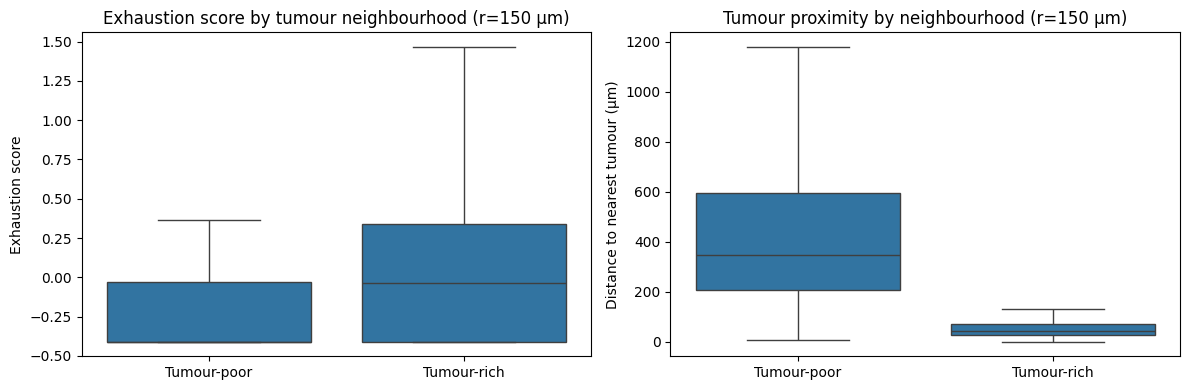

exhaustion_score: poor median=-0.409, rich median=-0.033, p=6.55e-49
nearest_tumour_dist: poor median=345.696, rich median=43.786, p=0


In [33]:
# ============================================================
# 6d: Visualise the new neighbourhood split
# ============================================================
plot_df = cd8_obs[["tumour_neighbourhood", "nearest_tumour_dist", "exhaustion_score"]].dropna()
neigh_order = ["Tumour-poor", "Tumour-rich"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: exhaustion score by neighbourhood
sns.boxplot(data=plot_df, x="tumour_neighbourhood", y="exhaustion_score",
            order=neigh_order, showfliers=False, ax=axes[0])
axes[0].set_xlabel("")
axes[0].set_ylabel("Exhaustion score")
axes[0].set_title(f"Exhaustion score by tumour neighbourhood (r={RADIUS} µm)")

# Right: nearest tumour distance by neighbourhood
sns.boxplot(data=plot_df, x="tumour_neighbourhood", y="nearest_tumour_dist",
            order=neigh_order, showfliers=False, ax=axes[1])
axes[1].set_xlabel("")
axes[1].set_ylabel("Distance to nearest tumour (µm)")
axes[1].set_title(f"Tumour proximity by neighbourhood (r={RADIUS} µm)")

plt.tight_layout()
plt.show()

# Stats
for col_name in ["exhaustion_score", "nearest_tumour_dist"]:
    poor = plot_df.loc[plot_df["tumour_neighbourhood"] == "Tumour-poor", col_name].dropna()
    rich = plot_df.loc[plot_df["tumour_neighbourhood"] == "Tumour-rich", col_name].dropna()
    if len(poor) > 0 and len(rich) > 0:
        u, p = mannwhitneyu(poor, rich, alternative="two-sided")
        print(f"{col_name}: poor median={poor.median():.3f}, rich median={rich.median():.3f}, p={p:.3g}")
    else:
        print(f"{col_name}: Cannot compare — one group is empty")

PATH B — RADIUS-BASED (r=150 µm) — Treatment Status


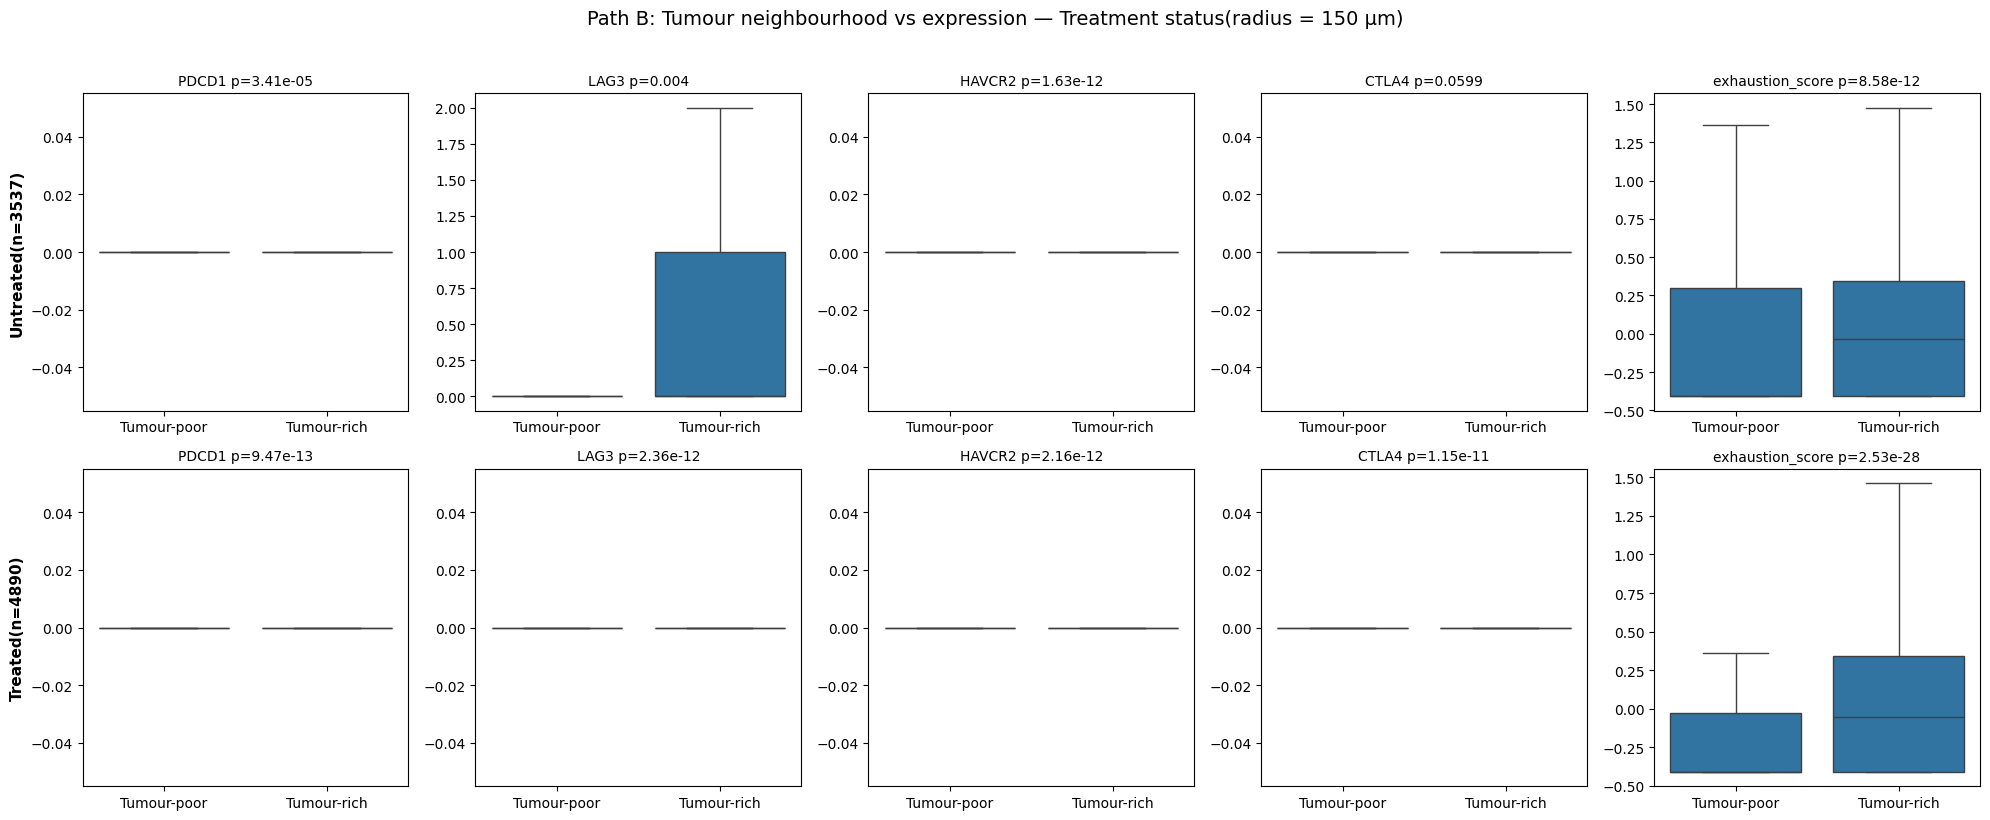

Summary: Treatment status (radius = 150 µm)
Untreated (total=3537, poor=1155, rich=2382):
  PDCD1                 poor=0.000  rich=0.000  p=3.413e-05
  LAG3                  poor=0.000  rich=0.000  p=0.003998
  HAVCR2                poor=0.000  rich=0.000  p=1.631e-12
  CTLA4                 poor=0.000  rich=0.000  p=0.05986
  exhaustion_score      poor=-0.409  rich=-0.033  p=8.578e-12
Treated (total=4890, poor=2899, rich=1991):
  PDCD1                 poor=0.000  rich=0.000  p=9.469e-13
  LAG3                  poor=0.000  rich=0.000  p=2.363e-12
  HAVCR2                poor=0.000  rich=0.000  p=2.164e-12
  CTLA4                 poor=0.000  rich=0.000  p=1.146e-11
  exhaustion_score      poor=-0.409  rich=-0.055  p=2.529e-28

PATH B — RADIUS-BASED (r=150 µm) — Immunotherapy


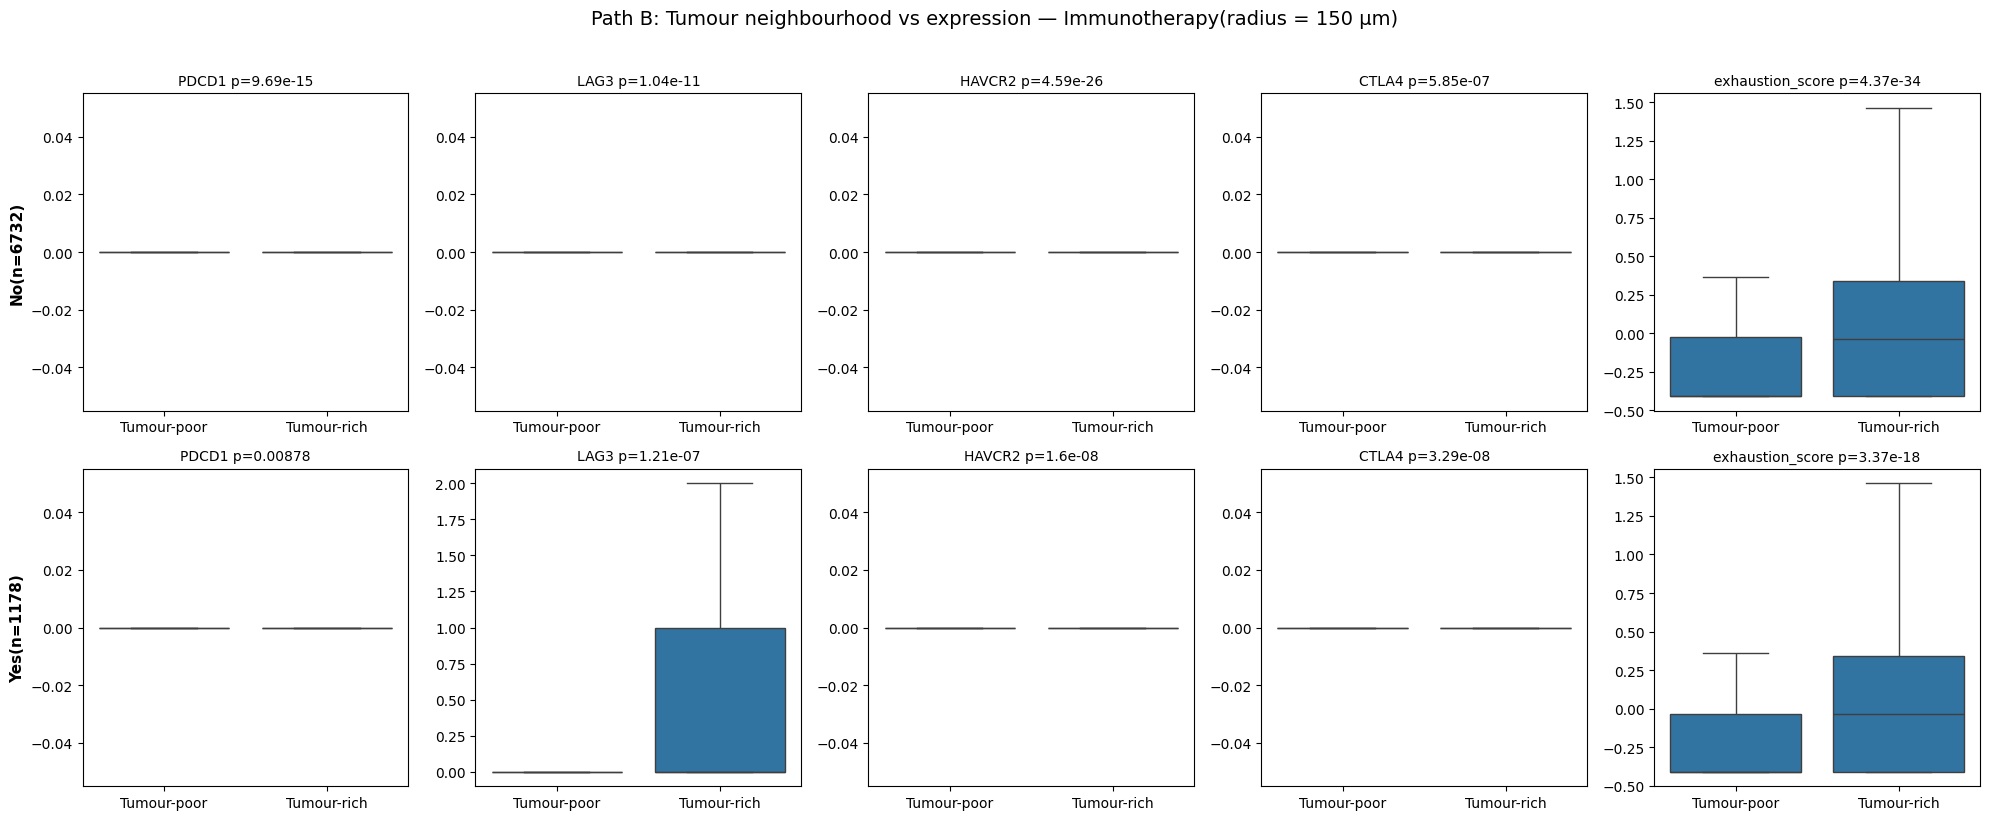

Summary: Immunotherapy (radius = 150 µm)
No (total=6732, poor=3478, rich=3254):
  PDCD1                 poor=0.000  rich=0.000  p=9.693e-15
  LAG3                  poor=0.000  rich=0.000  p=1.041e-11
  HAVCR2                poor=0.000  rich=0.000  p=4.592e-26
  CTLA4                 poor=0.000  rich=0.000  p=5.847e-07
  exhaustion_score      poor=-0.409  rich=-0.033  p=4.369e-34
Yes (total=1178, poor=358, rich=820):
  PDCD1                 poor=0.000  rich=0.000  p=0.008776
  LAG3                  poor=0.000  rich=0.000  p=1.209e-07
  HAVCR2                poor=0.000  rich=0.000  p=1.6e-08
  CTLA4                 poor=0.000  rich=0.000  p=3.29e-08
  exhaustion_score      poor=-0.409  rich=-0.033  p=3.37e-18

PATH B — RADIUS-BASED (r=150 µm) — Anatomical Site


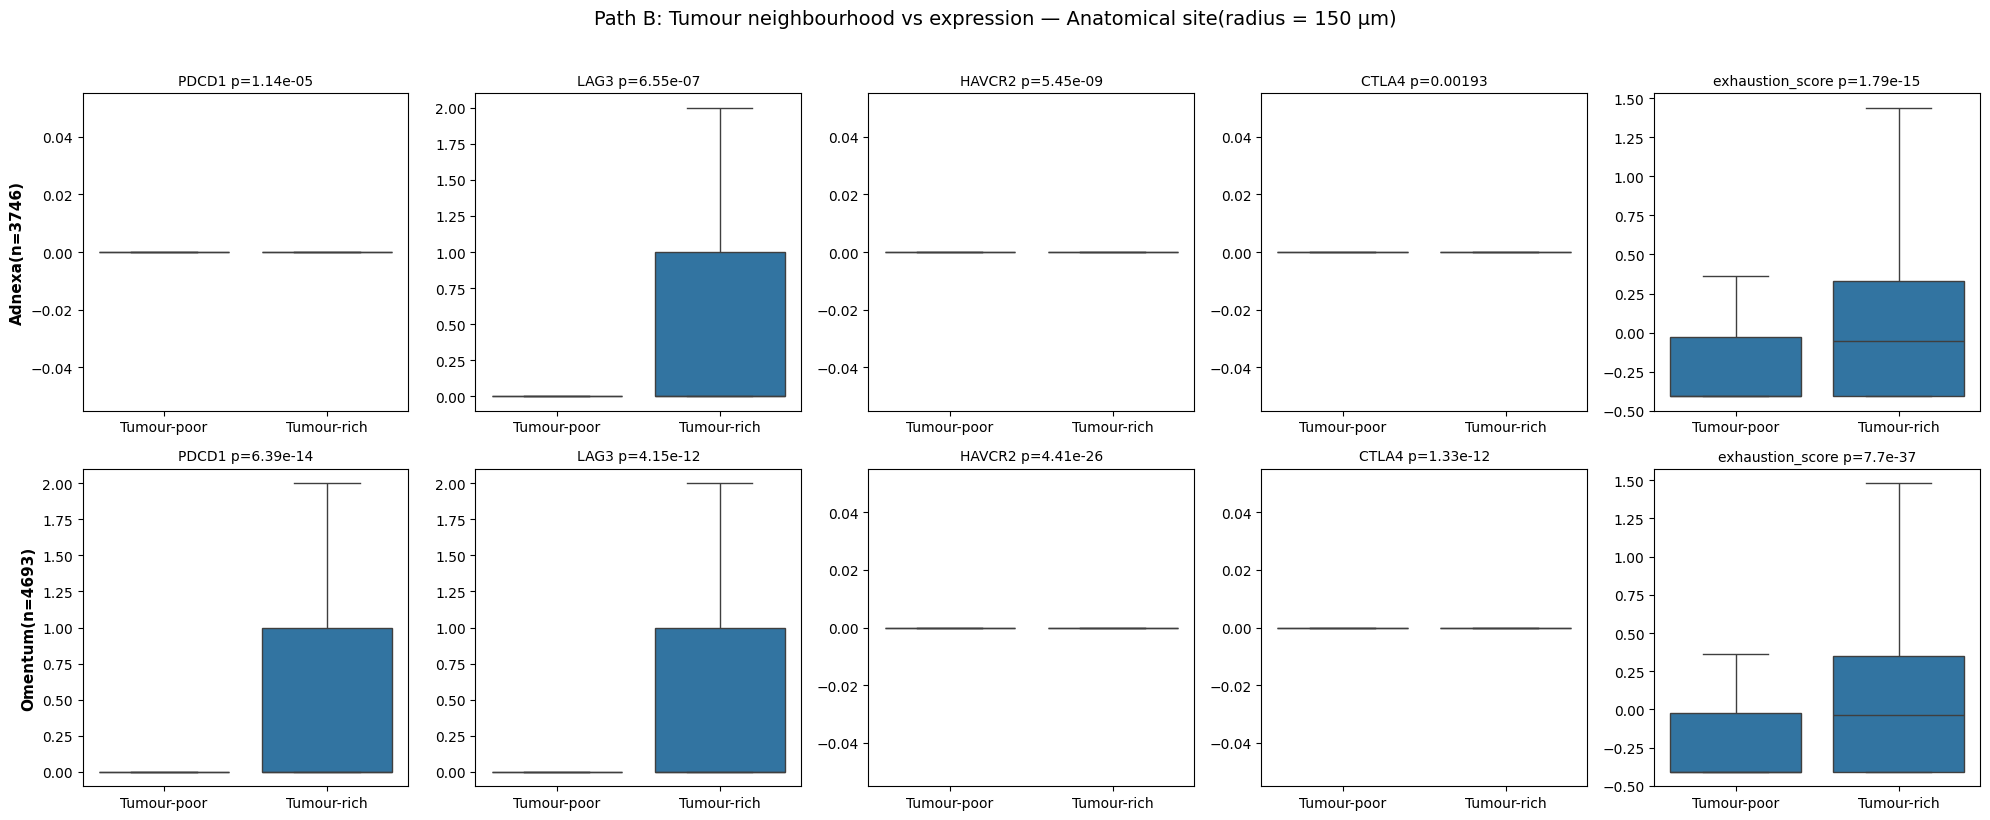

Summary: Anatomical site (radius = 150 µm)
Adnexa (total=3746, poor=1724, rich=2022):
  PDCD1                 poor=0.000  rich=0.000  p=1.138e-05
  LAG3                  poor=0.000  rich=0.000  p=6.549e-07
  HAVCR2                poor=0.000  rich=0.000  p=5.451e-09
  CTLA4                 poor=0.000  rich=0.000  p=0.001932
  exhaustion_score      poor=-0.409  rich=-0.055  p=1.785e-15
Omentum (total=4693, poor=2333, rich=2360):
  PDCD1                 poor=0.000  rich=0.000  p=6.388e-14
  LAG3                  poor=0.000  rich=0.000  p=4.148e-12
  HAVCR2                poor=0.000  rich=0.000  p=4.412e-26
  CTLA4                 poor=0.000  rich=0.000  p=1.327e-12
  exhaustion_score      poor=-0.409  rich=-0.033  p=7.697e-37


In [41]:
# ============================================================
# 6e: Re-run Path B with the new radius (r=150µm)
# ============================================================
# Treatment
print("=" * 70)
print("PATH B — RADIUS-BASED (r=150 µm) — Treatment Status")
print("=" * 70)
path_b_comparison(cd8_obs, "treatment_clean", ["Untreated", "Treated"],
                  "Treatment status")

# Immunotherapy
print("\n" + "=" * 70)
print("PATH B — RADIUS-BASED (r=150 µm) — Immunotherapy")
print("=" * 70)
path_b_comparison(cd8_obs, "immunotherapy_clean", ["No", "Yes"],
                  "Immunotherapy")

# Anatomical Site
print("\n" + "=" * 70)
print("PATH B — RADIUS-BASED (r=150 µm) — Anatomical Site")
print("=" * 70)
path_b_comparison(cd8_obs, "site_clean", ["Adnexa", "Omentum"],
                  "Anatomical site")

In [35]:
# ============================================================
# 6f: Side-by-side comparison table — Radius r=150 vs KNN k=20
# ============================================================
print("=" * 80)
print("COMPARISON: Radius (r=150 µm) vs KNN (k=20) — Path B p-values")
print("=" * 80)
print(f"{'Clinical Group':<20} {'Marker':<20} {'Radius p-value':<18} {'KNN p-value':<18}")
print("-" * 80)

for clinical_col, clinical_groups, label in [
    ("treatment_clean", ["Untreated", "Treated"], "Treatment"),
    ("immunotherapy_clean", ["No", "Yes"], "Immunotherapy"),
    ("site_clean", ["Adnexa", "Omentum"], "Site")
]:
    for grp in clinical_groups:
        grp_data = cd8_obs[(cd8_obs[clinical_col] == grp)].dropna(
            subset=["tumour_neighbourhood", "tumour_neighbourhood_knn"])
        
        genes = markers + ["exhaustion_score"]
        for gene in genes:
            # Radius-based
            poor_r = grp_data.loc[grp_data["tumour_neighbourhood"] == "Tumour-poor", gene].dropna()
            rich_r = grp_data.loc[grp_data["tumour_neighbourhood"] == "Tumour-rich", gene].dropna()
            if len(poor_r) > 0 and len(rich_r) > 0:
                _, p_r = mannwhitneyu(poor_r, rich_r, alternative="two-sided")
                p_r_str = f"{p_r:.3g}"
            else:
                p_r_str = "NaN"
            
            # KNN-based
            poor_k = grp_data.loc[grp_data["tumour_neighbourhood_knn"] == "Tumour-poor", gene].dropna()
            rich_k = grp_data.loc[grp_data["tumour_neighbourhood_knn"] == "Tumour-rich", gene].dropna()
            if len(poor_k) > 0 and len(rich_k) > 0:
                _, p_k = mannwhitneyu(poor_k, rich_k, alternative="two-sided")
                p_k_str = f"{p_k:.3g}"
            else:
                p_k_str = "NaN"
            
            print(f"{grp:<20} {gene:<20} {p_r_str:<18} {p_k_str:<18}")
    print("-" * 80)

COMPARISON: Radius (r=150 µm) vs KNN (k=20) — Path B p-values
Clinical Group       Marker               Radius p-value     KNN p-value       
--------------------------------------------------------------------------------
Untreated            PDCD1                3.41e-05           0.00869           
Untreated            LAG3                 0.004              0.00732           
Untreated            HAVCR2               1.63e-12           5.28e-10          
Untreated            CTLA4                0.0599             0.0491            
Untreated            exhaustion_score     8.58e-12           6.9e-09           
Treated              PDCD1                9.47e-13           7.13e-13          
Treated              LAG3                 2.36e-12           5.25e-18          
Treated              HAVCR2               2.16e-12           5.72e-13          
Treated              CTLA4                1.15e-11           2.78e-09          
Treated              exhaustion_score     2.53e-28       

---
### 7. Path A — Gene Expression Across Clinical Groups

For **all** CD8+ T cells (regardless of neighbourhood), compare exhaustion marker expression  
and composite score across clinical conditions:

- **Treatment status:** Treated (primarily chemotherapy) vs Untreated
- **Immunotherapy:** Yes vs No  
- **Anatomical site:** Adnexa vs Omentum

**Statistical test:** Mann-Whitney U (non-parametric, appropriate for zero-inflated count data)


In [36]:
# ============================================================
# 7a. Path A helper function
# ============================================================
def path_a_boxplots(df, group_col, group_order, title_suffix):
    """
    Boxplots of exhaustion markers + composite score across clinical groups.
    Works on cd8_obs DataFrame (not AnnData).
    """
    plot_data = df[[group_col, "exhaustion_score"] + markers].dropna(subset=[group_col])
    plot_data = plot_data[plot_data[group_col] != "Unknown"]
    
    valid_order = [g for g in group_order if g in plot_data[group_col].values]
    if len(valid_order) == 0:
        print(f"No valid groups for {group_col}")
        return
    
    genes = markers + ["exhaustion_score"]
    n = len(genes)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4), sharey=False)
    
    for i, gene in enumerate(genes):
        sns.boxplot(data=plot_data, x=group_col, y=gene, order=valid_order,
                    showfliers=False, ax=axes[i])
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Expression" if i == 0 else "")
        
        # p-value for 2-group comparison
        if len(valid_order) == 2:
            g1 = plot_data.loc[plot_data[group_col]==valid_order[0], gene].dropna()
            g2 = plot_data.loc[plot_data[group_col]==valid_order[1], gene].dropna()
            if len(g1) > 0 and len(g2) > 0:
                _, p = mannwhitneyu(g1, g2, alternative="two-sided")
                axes[i].set_title(f"{gene} p={p:.3g}")
            else:
                axes[i].set_title(gene)
        else:
            axes[i].set_title(gene)
    
    fig.suptitle(f"Path A: Exhaustion markers by {title_suffix}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Group sizes
    print(f"Group sizes ({title_suffix}):")
    for g in valid_order:
        n_cells = (plot_data[group_col] == g).sum()
        print(f"  {g}: {n_cells:,}")


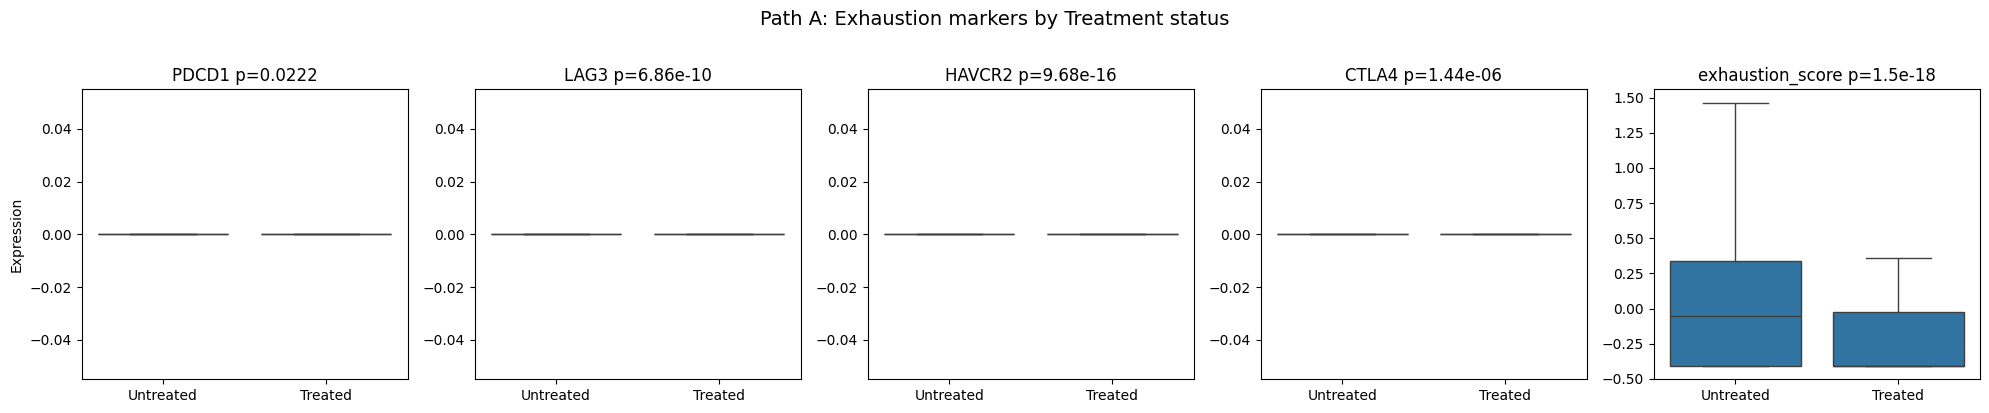

Group sizes (Treatment status):
  Untreated: 3,537
  Treated: 4,890


In [37]:
# ============================================================
# 7b. Path A: Treatment (Treated vs Untreated)
# ============================================================
path_a_boxplots(cd8_obs, "treatment_clean", ["Untreated", "Treated"],
                "Treatment status")


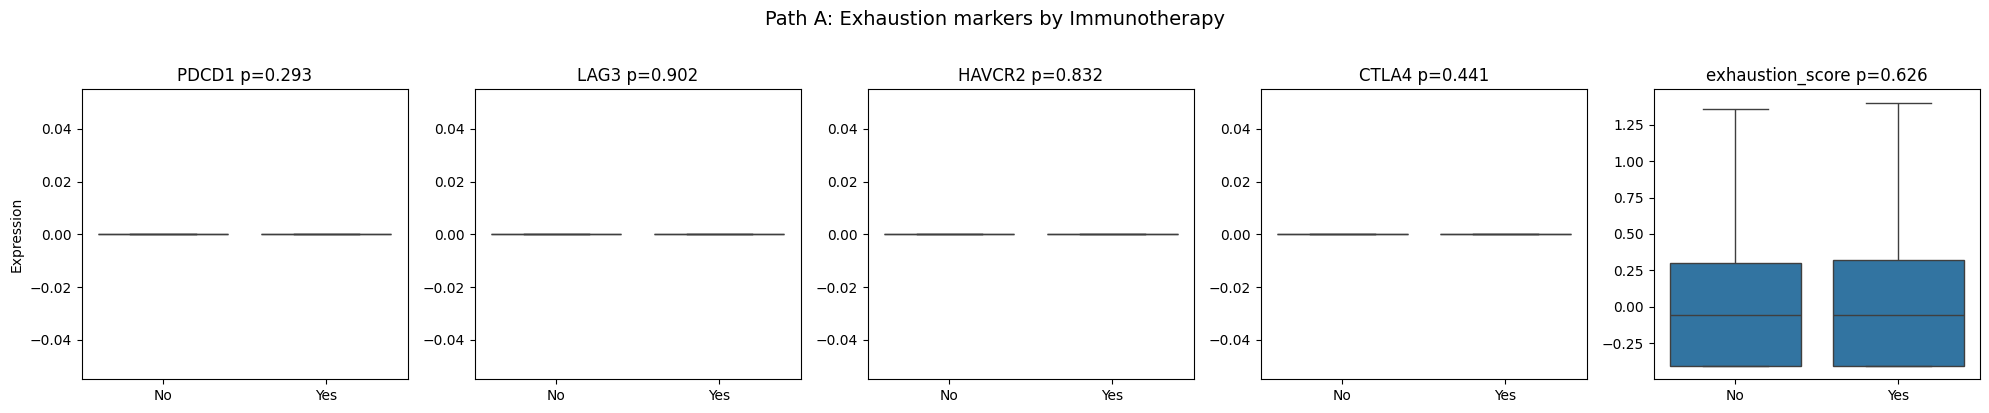

Group sizes (Immunotherapy):
  No: 6,732
  Yes: 1,178


In [38]:
# ============================================================
# 7c. Path A: Immunotherapy (Yes vs No)
# ============================================================
path_a_boxplots(cd8_obs, "immunotherapy_clean", ["No", "Yes"],
                "Immunotherapy")


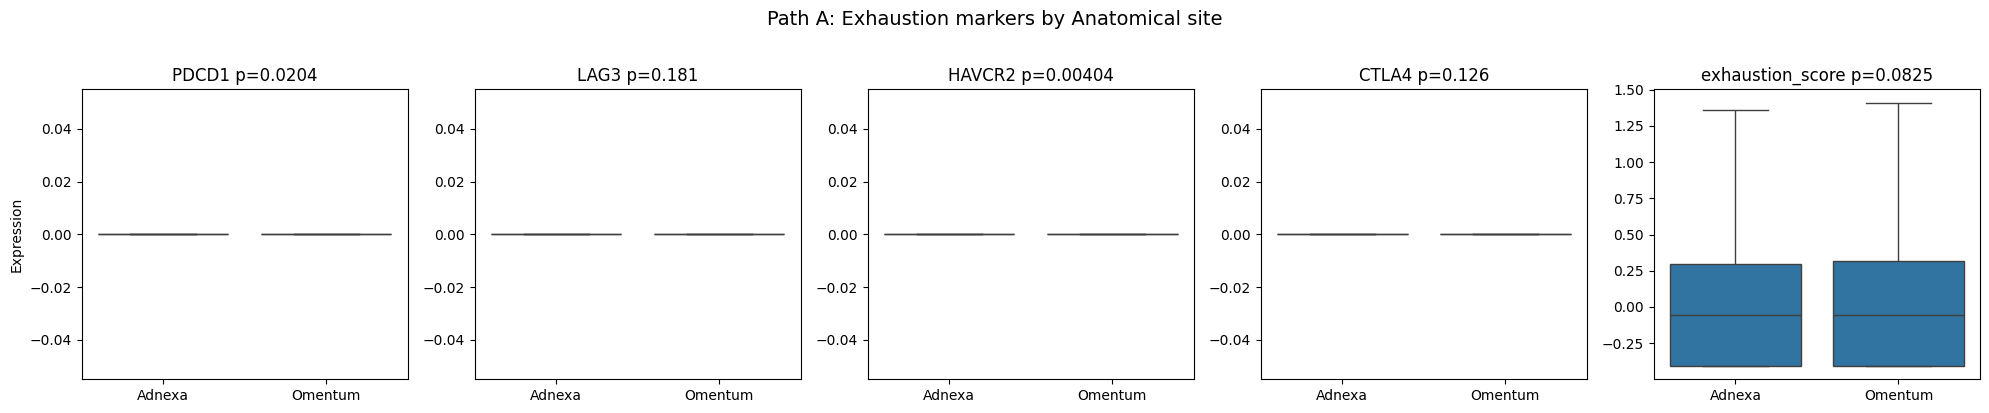

Group sizes (Anatomical site):
  Adnexa: 3,746
  Omentum: 4,693


In [39]:
# ============================================================
# 7d. Path A: Anatomical Site (Adnexa vs Omentum)
# ============================================================
path_a_boxplots(cd8_obs, "site_clean", ["Adnexa", "Omentum"],
                "Anatomical site")


---
### 8. Path B — Tumour-Rich vs Tumour-Poor Neighbourhood Comparison

**Core analysis:** Within each clinical group, do CD8+ T cells in tumour-rich neighbourhoods  
show higher exhaustion than those in tumour-poor neighbourhoods?

Groups per clinical condition:
- **Tumour-rich:** CD8+ T cells with ≥ median tumour neighbours within radius
- **Tumour-poor:** CD8+ T cells with < median tumour neighbours within radius

This directly tests the hypothesis: *proximity to cancer cells drives CD8+ T cell exhaustion*.

**Statistical test:** Mann-Whitney U with Bonferroni correction across markers


In [40]:
# ============================================================
# 8a. Path B helper function
# ============================================================
def path_b_comparison(df, clinical_col, clinical_groups, title_suffix):
    """
    For each clinical group: split CD8 T cells by tumour neighbourhood,
    then compare exhaustion markers + score.
    """
    plot_data = df.dropna(subset=[clinical_col, "tumour_neighbourhood"])
    plot_data = plot_data[plot_data[clinical_col] != "Unknown"]
    
    valid_groups = [g for g in clinical_groups if g in plot_data[clinical_col].values]
    if len(valid_groups) == 0:
        print(f"No valid groups for {clinical_col}")
        return
    
    genes = markers + ["exhaustion_score"]
    neigh_order = ["Tumour-poor", "Tumour-rich"]
    n_genes = len(genes)
    n_groups = len(valid_groups)
    
    fig, axes = plt.subplots(n_groups, n_genes, figsize=(4*n_genes, 4*n_groups),
                              squeeze=False)
    
    for row, grp in enumerate(valid_groups):
        grp_data = plot_data[plot_data[clinical_col] == grp]
        
        for col_idx, gene in enumerate(genes):
            ax = axes[row, col_idx]
            sns.boxplot(data=grp_data, x="tumour_neighbourhood", y=gene,
                        order=neigh_order, showfliers=False, ax=ax)
            
            poor = grp_data.loc[grp_data["tumour_neighbourhood"]=="Tumour-poor", gene].dropna()
            rich = grp_data.loc[grp_data["tumour_neighbourhood"]=="Tumour-rich", gene].dropna()
            
            if len(poor) > 0 and len(rich) > 0:
                _, p = mannwhitneyu(poor, rich, alternative="two-sided")
                ax.set_title(f"{gene} p={p:.3g}", fontsize=10)
            else:
                ax.set_title(gene, fontsize=10)
            
            ax.set_xlabel("")
            if col_idx == 0:
                ax.set_ylabel(f"{grp}(n={len(grp_data)})", fontsize=11, fontweight="bold")
            else:
                ax.set_ylabel("")
    
    fig.suptitle(f"Path B: Tumour neighbourhood vs expression — {title_suffix}"
                 f"(radius = {RADIUS} µm)",
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print(f"{'='*70}")
    print(f"Summary: {title_suffix} (radius = {RADIUS} µm)")
    print(f"{'='*70}")
    for grp in valid_groups:
        grp_data = plot_data[plot_data[clinical_col] == grp]
        n_poor = (grp_data["tumour_neighbourhood"]=="Tumour-poor").sum()
        n_rich = (grp_data["tumour_neighbourhood"]=="Tumour-rich").sum()
        print(f"{grp} (total={len(grp_data)}, poor={n_poor}, rich={n_rich}):")
        for gene in genes:
            poor = grp_data.loc[grp_data["tumour_neighbourhood"]=="Tumour-poor", gene].dropna()
            rich = grp_data.loc[grp_data["tumour_neighbourhood"]=="Tumour-rich", gene].dropna()
            if len(poor) > 0 and len(rich) > 0:
                _, p = mannwhitneyu(poor, rich, alternative="two-sided")
                print(f"  {gene:20s}  poor={poor.median():.3f}  rich={rich.median():.3f}  p={p:.4g}")


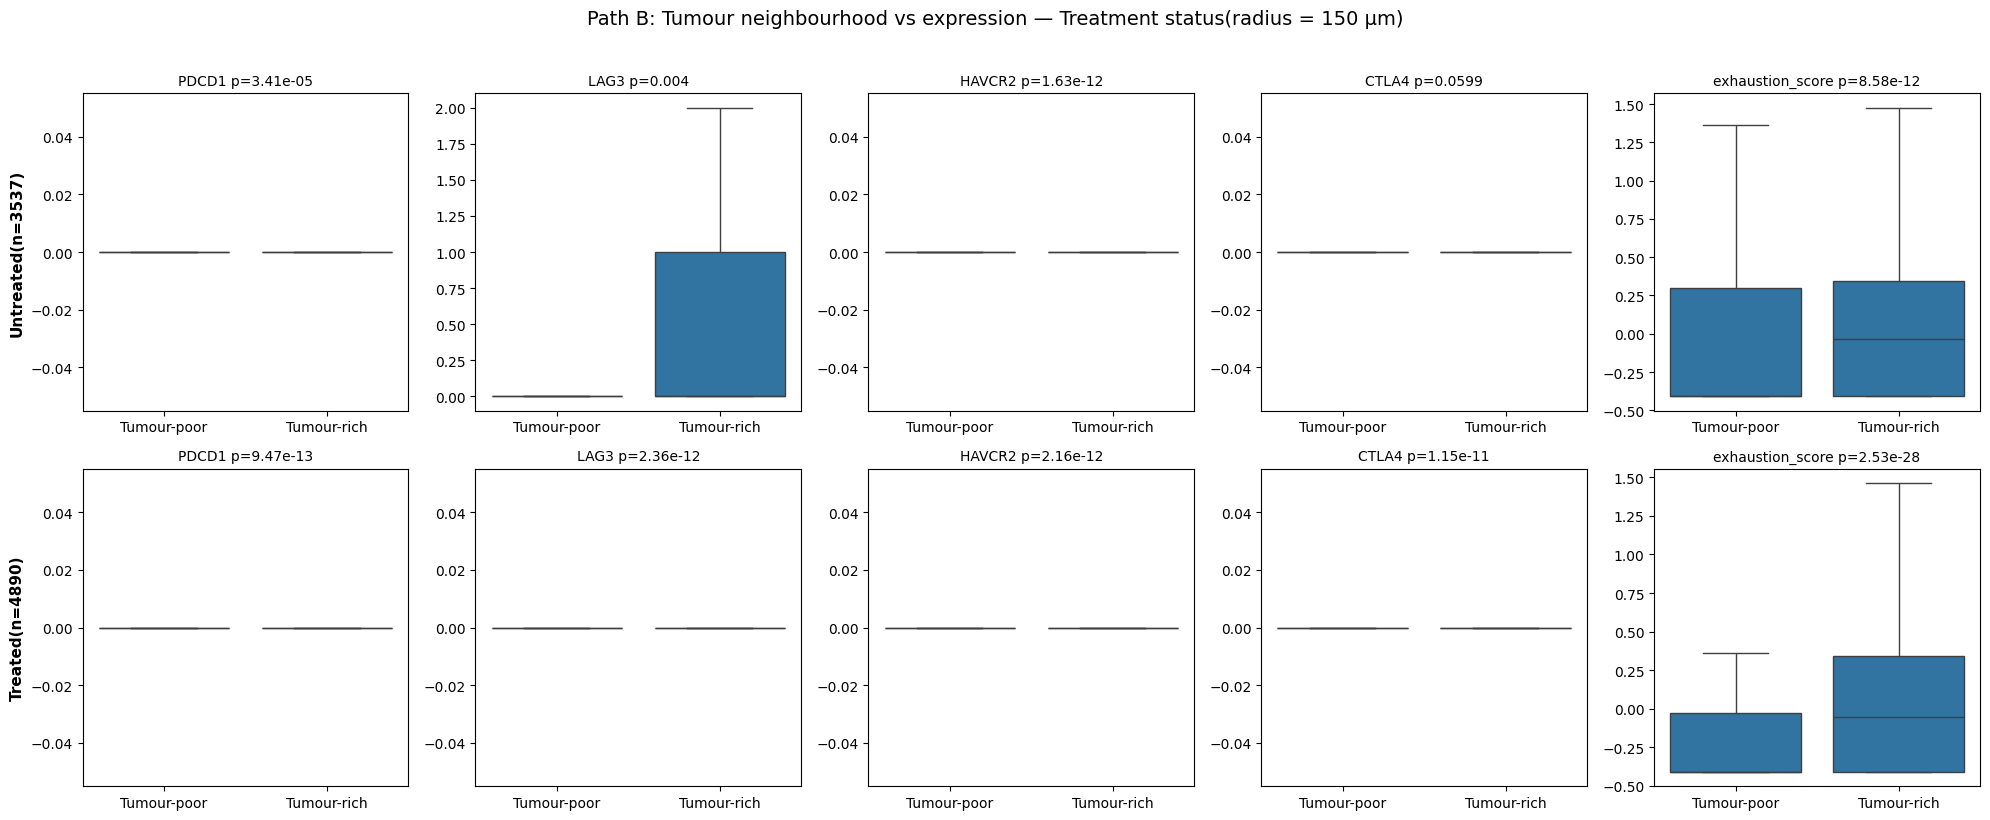

Summary: Treatment status (radius = 150 µm)
Untreated (total=3537, poor=1155, rich=2382):
  PDCD1                 poor=0.000  rich=0.000  p=3.413e-05
  LAG3                  poor=0.000  rich=0.000  p=0.003998
  HAVCR2                poor=0.000  rich=0.000  p=1.631e-12
  CTLA4                 poor=0.000  rich=0.000  p=0.05986
  exhaustion_score      poor=-0.409  rich=-0.033  p=8.578e-12
Treated (total=4890, poor=2899, rich=1991):
  PDCD1                 poor=0.000  rich=0.000  p=9.469e-13
  LAG3                  poor=0.000  rich=0.000  p=2.363e-12
  HAVCR2                poor=0.000  rich=0.000  p=2.164e-12
  CTLA4                 poor=0.000  rich=0.000  p=1.146e-11
  exhaustion_score      poor=-0.409  rich=-0.055  p=2.529e-28


In [54]:
# ============================================================
# 8b. Path B: Treatment (Treated vs Untreated)
# ============================================================
path_b_comparison(cd8_obs, "treatment_clean", ["Untreated", "Treated"],
                  "Treatment status")


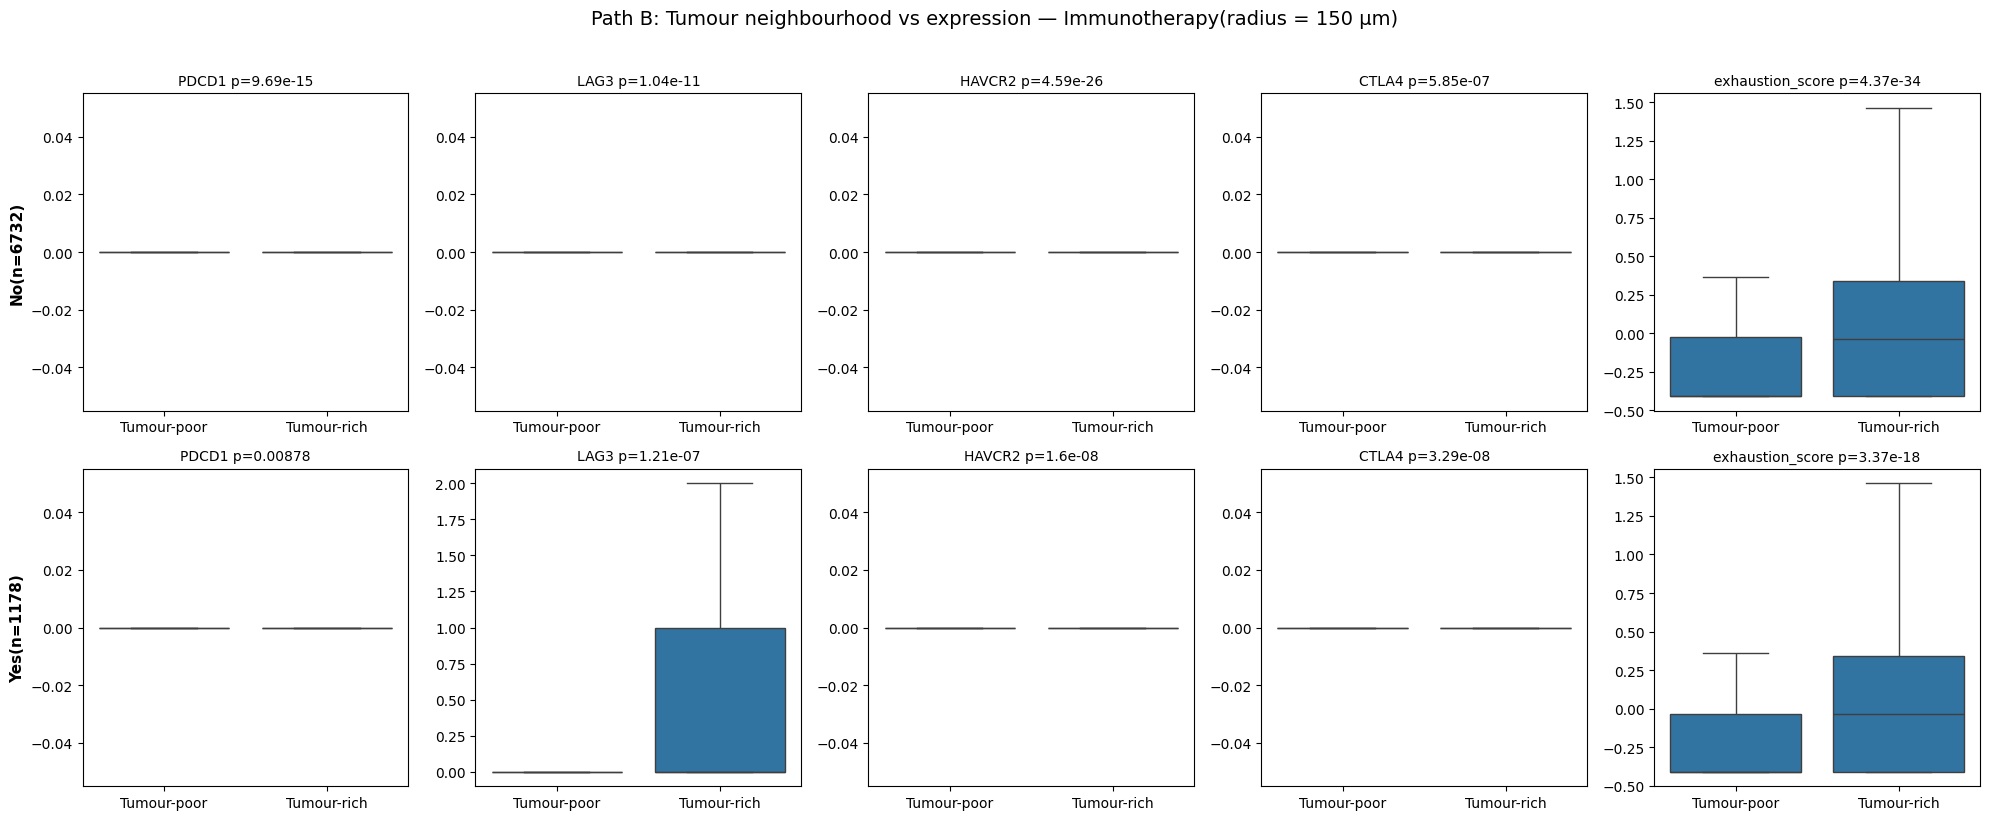

Summary: Immunotherapy (radius = 150 µm)
No (total=6732, poor=3478, rich=3254):
  PDCD1                 poor=0.000  rich=0.000  p=9.693e-15
  LAG3                  poor=0.000  rich=0.000  p=1.041e-11
  HAVCR2                poor=0.000  rich=0.000  p=4.592e-26
  CTLA4                 poor=0.000  rich=0.000  p=5.847e-07
  exhaustion_score      poor=-0.409  rich=-0.033  p=4.369e-34
Yes (total=1178, poor=358, rich=820):
  PDCD1                 poor=0.000  rich=0.000  p=0.008776
  LAG3                  poor=0.000  rich=0.000  p=1.209e-07
  HAVCR2                poor=0.000  rich=0.000  p=1.6e-08
  CTLA4                 poor=0.000  rich=0.000  p=3.29e-08
  exhaustion_score      poor=-0.409  rich=-0.033  p=3.37e-18


In [55]:
# ============================================================
# 8c. Path B: Immunotherapy (Yes vs No)
# ============================================================
path_b_comparison(cd8_obs, "immunotherapy_clean", ["No", "Yes"],
                  "Immunotherapy")


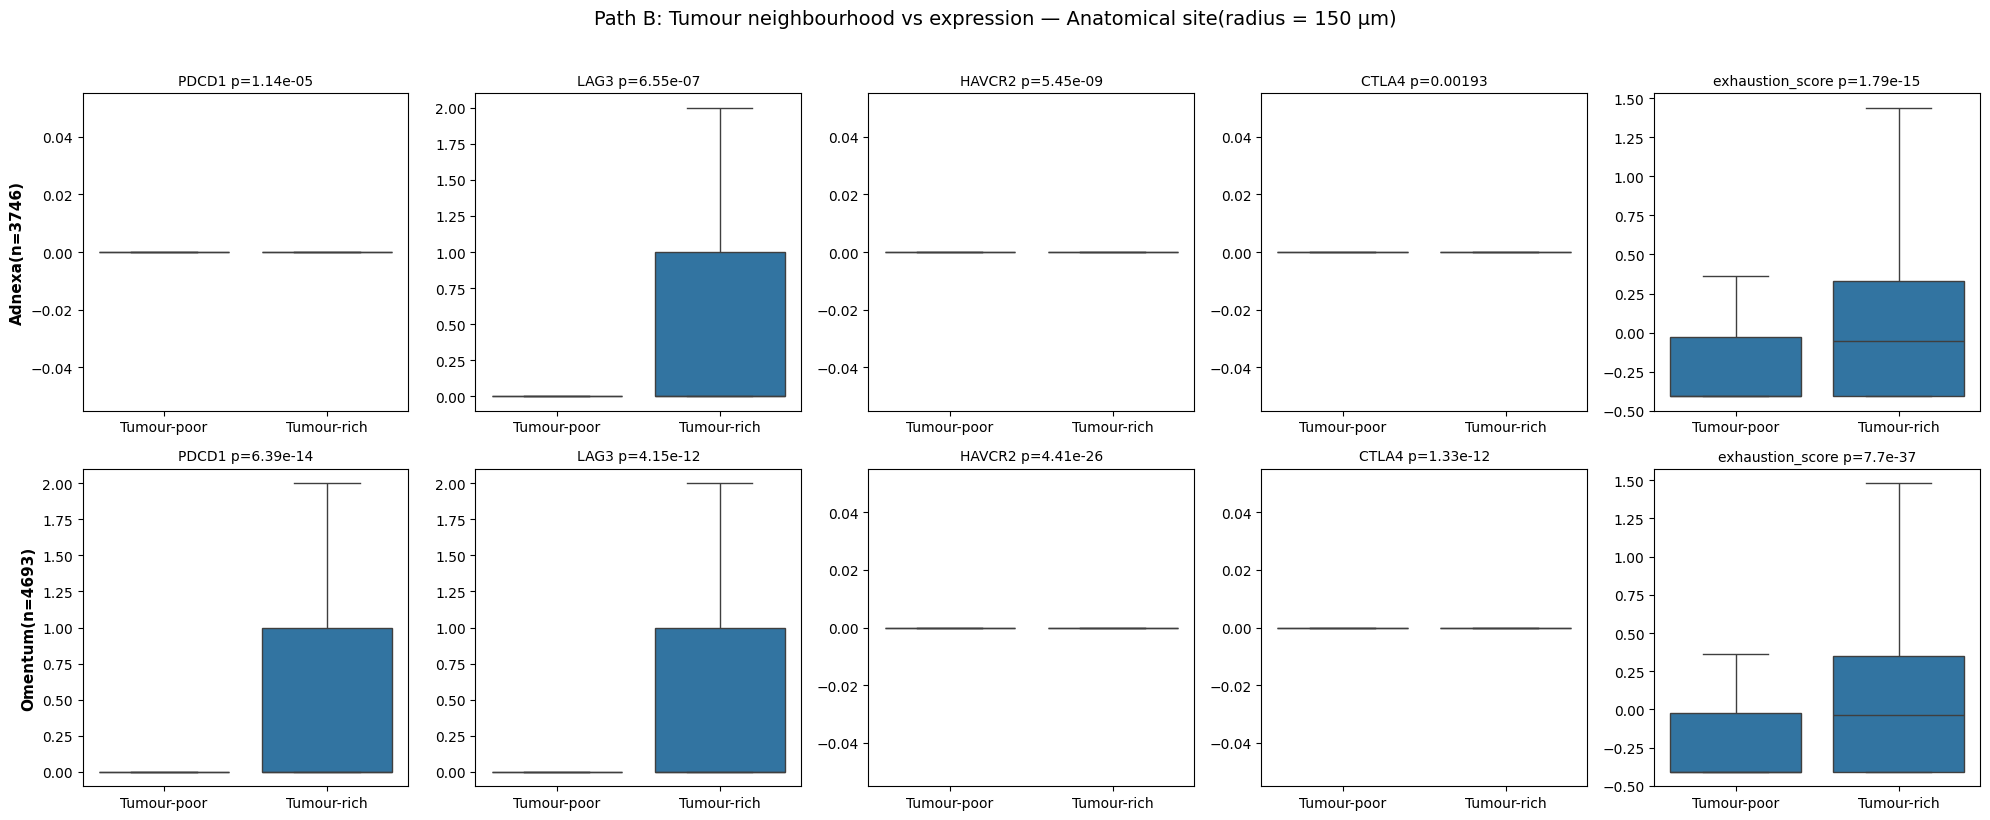

Summary: Anatomical site (radius = 150 µm)
Adnexa (total=3746, poor=1724, rich=2022):
  PDCD1                 poor=0.000  rich=0.000  p=1.138e-05
  LAG3                  poor=0.000  rich=0.000  p=6.549e-07
  HAVCR2                poor=0.000  rich=0.000  p=5.451e-09
  CTLA4                 poor=0.000  rich=0.000  p=0.001932
  exhaustion_score      poor=-0.409  rich=-0.055  p=1.785e-15
Omentum (total=4693, poor=2333, rich=2360):
  PDCD1                 poor=0.000  rich=0.000  p=6.388e-14
  LAG3                  poor=0.000  rich=0.000  p=4.148e-12
  HAVCR2                poor=0.000  rich=0.000  p=4.412e-26
  CTLA4                 poor=0.000  rich=0.000  p=1.327e-12
  exhaustion_score      poor=-0.409  rich=-0.033  p=7.697e-37


In [56]:
# ============================================================
# 8d. Path B: Anatomical Site (Adnexa vs Omentum)
# ============================================================
path_b_comparison(cd8_obs, "site_clean", ["Adnexa", "Omentum"],
                  "Anatomical site")


---
### 8e–8i. Path B — KNN Comparison

Repeat Path B using KNN-based neighbourhood split (k=20) for comparison with the radius approach.

**KNN neighbourhood definition:**

For each CD8+ T cell i, find its k=20 nearest neighbours among all cells in the same sample.  
Tumour fraction = (number of those k neighbours that are malignant) / k

    tumour_frac_knn(i) = |{ j ∈ KNN(i) : cell_type(j) = "Malignant" }| / k

Split threshold: median tumour fraction across all CD8+ T cells.  
KNN produces a more balanced split (51%/49%) than radius at small radii.


In [58]:
# ============================================================
# 8e. Path B with KNN neighbourhood (for comparison)
# ============================================================
def path_b_comparison_knn(df, clinical_col, clinical_groups, title_suffix):
    """Same as path_b_comparison but using KNN neighbourhood split."""
    plot_data = df.dropna(subset=[clinical_col, "tumour_neighbourhood_knn"])
    plot_data = plot_data[plot_data[clinical_col] != "Unknown"]
    
    valid_groups = [g for g in clinical_groups if g in plot_data[clinical_col].values]
    if len(valid_groups) == 0:
        print(f"No valid groups for {clinical_col}")
        return
    
    genes = markers + ["exhaustion_score"]
    neigh_order = ["Tumour-poor", "Tumour-rich"]
    n_genes = len(genes)
    n_groups = len(valid_groups)
    
    fig, axes = plt.subplots(n_groups, n_genes, figsize=(4*n_genes, 4*n_groups),
                              squeeze=False)
    
    for row, grp in enumerate(valid_groups):
        grp_data = plot_data[plot_data[clinical_col] == grp]
        
        for col_idx, gene in enumerate(genes):
            ax = axes[row, col_idx]
            sns.boxplot(data=grp_data, x="tumour_neighbourhood_knn", y=gene,
                        order=neigh_order, showfliers=False, ax=ax)
            
            poor = grp_data.loc[grp_data["tumour_neighbourhood_knn"]=="Tumour-poor", gene].dropna()
            rich = grp_data.loc[grp_data["tumour_neighbourhood_knn"]=="Tumour-rich", gene].dropna()
            
            if len(poor) > 0 and len(rich) > 0:
                _, p = mannwhitneyu(poor, rich, alternative="two-sided")
                ax.set_title(f"{gene}p={p:.3g}", fontsize=10)
            else:
                ax.set_title(gene, fontsize=10)
            
            ax.set_xlabel("")
            if col_idx == 0:
                ax.set_ylabel(f"{grp}(n={len(grp_data)})", fontsize=11, fontweight="bold")
            else:
                ax.set_ylabel("")
    
    fig.suptitle(f"Path B (KNN k={K}): Tumour neighbourhood vs expression — {title_suffix}",
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Summary
    print(f"{'='*70}")
    print(f"Summary (KNN k={K}): {title_suffix}")
    print(f"{'='*70}")
    for grp in valid_groups:
            grp_data = plot_data[plot_data[clinical_col] == grp]
            n_poor = (grp_data["tumour_neighbourhood_knn"]=="Tumour-poor").sum()
            n_rich = (grp_data["tumour_neighbourhood_knn"]=="Tumour-rich").sum()
    print(f"{grp} (total={len(grp_data)}, poor={n_poor}, rich={n_rich}):")
    for gene in genes:
            poor = grp_data.loc[grp_data["tumour_neighbourhood_knn"]=="Tumour-poor", gene].dropna()
            rich = grp_data.loc[grp_data["tumour_neighbourhood_knn"]=="Tumour-rich", gene].dropna()
            if len(poor) > 0 and len(rich) > 0:
                _, p = mannwhitneyu(poor, rich, alternative="two-sided")
                print(f"  {gene:20s}  poor={poor.median():.3f}  rich={rich.median():.3f}  p={p:.4g}")


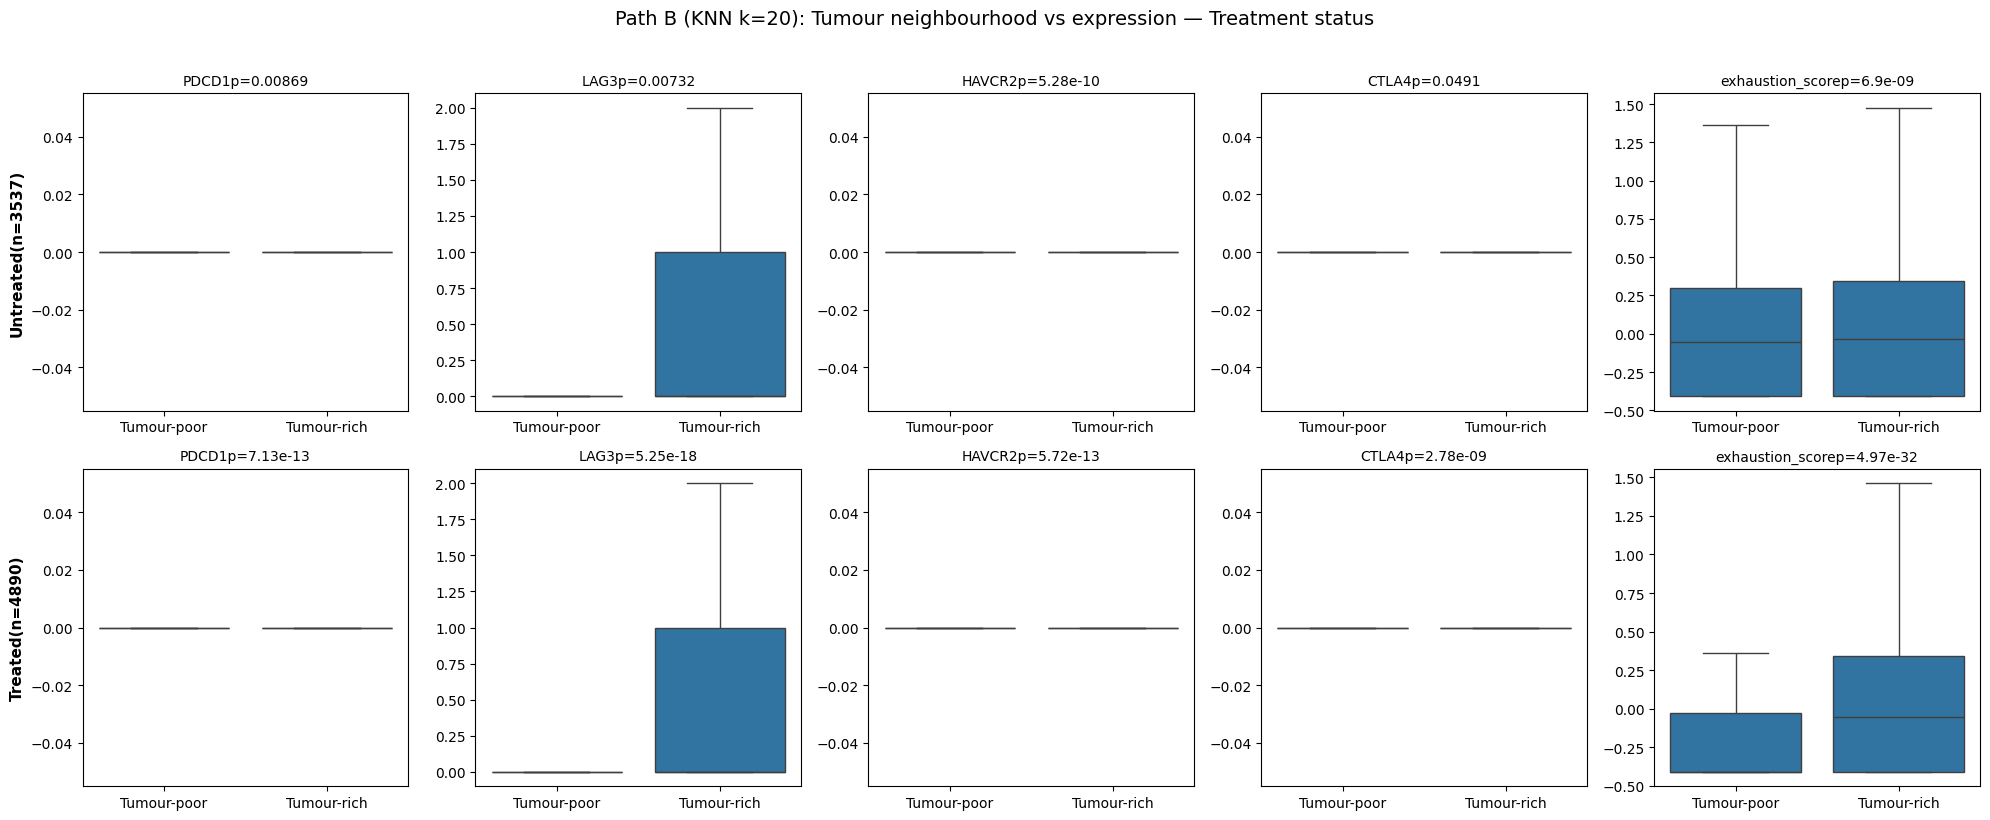

Summary (KNN k=20): Treatment status
Treated (total=4890, poor=2909, rich=1981):
  PDCD1                 poor=0.000  rich=0.000  p=7.135e-13
  LAG3                  poor=0.000  rich=0.000  p=5.25e-18
  HAVCR2                poor=0.000  rich=0.000  p=5.723e-13
  CTLA4                 poor=0.000  rich=0.000  p=2.78e-09
  exhaustion_score      poor=-0.409  rich=-0.055  p=4.974e-32


In [59]:
# ============================================================
# 8f. Path B KNN: Treatment
# ============================================================
path_b_comparison_knn(cd8_obs, "treatment_clean", ["Untreated", "Treated"],
                      "Treatment status")


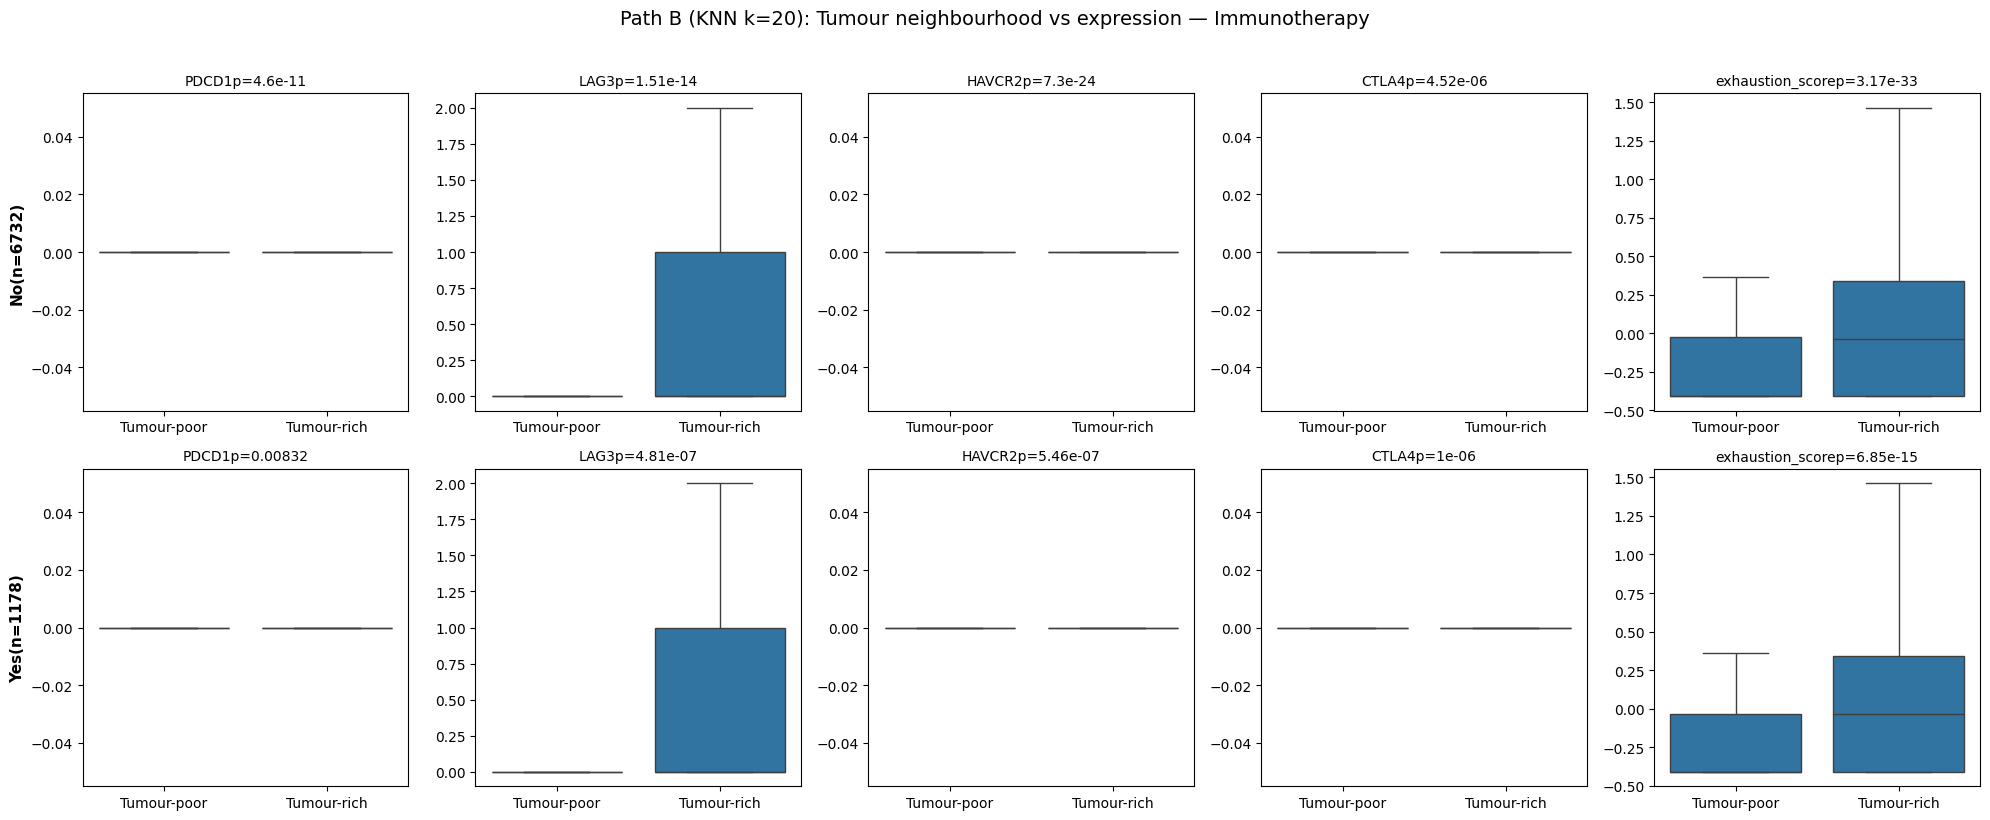

Summary (KNN k=20): Immunotherapy
Yes (total=1178, poor=345, rich=833):
  PDCD1                 poor=0.000  rich=0.000  p=0.008321
  LAG3                  poor=0.000  rich=0.000  p=4.806e-07
  HAVCR2                poor=0.000  rich=0.000  p=5.461e-07
  CTLA4                 poor=0.000  rich=0.000  p=1.001e-06
  exhaustion_score      poor=-0.409  rich=-0.033  p=6.846e-15


In [60]:
# ============================================================
# 8g. Path B KNN: Immunotherapy
# ============================================================
path_b_comparison_knn(cd8_obs, "immunotherapy_clean", ["No", "Yes"],
                      "Immunotherapy")


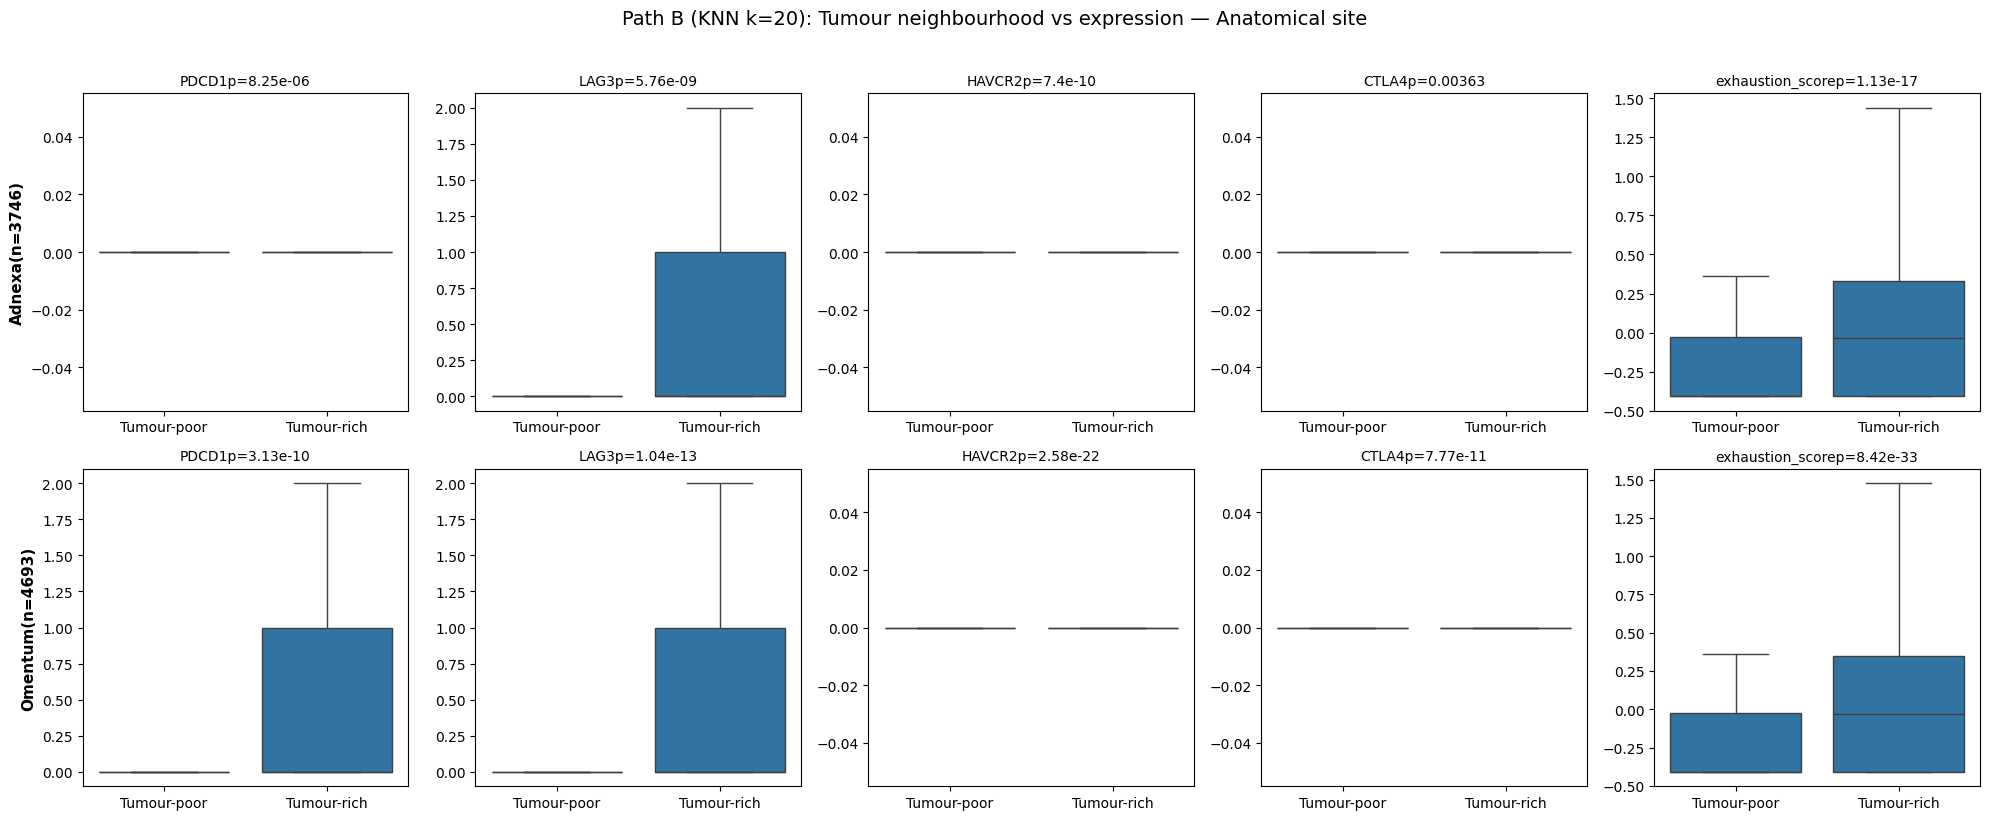

Summary (KNN k=20): Anatomical site
Omentum (total=4693, poor=2424, rich=2269):
  PDCD1                 poor=0.000  rich=0.000  p=3.134e-10
  LAG3                  poor=0.000  rich=0.000  p=1.04e-13
  HAVCR2                poor=0.000  rich=0.000  p=2.579e-22
  CTLA4                 poor=0.000  rich=0.000  p=7.77e-11
  exhaustion_score      poor=-0.409  rich=-0.033  p=8.423e-33


In [61]:
# ============================================================
# 8h. Path B KNN: Anatomical Site
# ============================================================
path_b_comparison_knn(cd8_obs, "site_clean", ["Adnexa", "Omentum"],
                      "Anatomical site")


### Radius vs KNN — Side-by-Side Summary

Compare p-values from both approaches to see if conclusions are robust to the neighbourhood definition method.


In [62]:
# ============================================================
# 8i. Side-by-side summary: Radius vs KNN
# ============================================================
genes = markers + ["exhaustion_score"]

print(f"{'='*85}")
print(f"{'COMPARISON: Radius (r=' + str(RADIUS) + ' µm) vs KNN (k=' + str(K) + ')':^85}")
print(f"{'='*85}")

for clinical_col, clinical_groups, label in [
    ("treatment_clean", ["Untreated", "Treated"], "Treatment"),
    ("immunotherapy_clean", ["No", "Yes"], "Immunotherapy"),
    ("site_clean", ["Adnexa", "Omentum"], "Anatomical site"),
]:
    plot_data = cd8_obs.dropna(subset=[clinical_col, "tumour_neighbourhood", "tumour_neighbourhood_knn"])
    plot_data = plot_data[plot_data[clinical_col] != "Unknown"]
    valid_groups = [g for g in clinical_groups if g in plot_data[clinical_col].values]
    
    print(f"--- {label} ---")
    for grp in valid_groups:
        grp_data = plot_data[plot_data[clinical_col] == grp]
        print(f"  {grp} (n={len(grp_data)}):")
        print(f"    {'Gene':20s}  {'Radius p':>10s}  {'KNN p':>10s}  {'Agree?':>8s}")
        
        for gene in genes:
            # Radius
            poor_r = grp_data.loc[grp_data["tumour_neighbourhood"]=="Tumour-poor", gene].dropna()
            rich_r = grp_data.loc[grp_data["tumour_neighbourhood"]=="Tumour-rich", gene].dropna()
            # KNN
            poor_k = grp_data.loc[grp_data["tumour_neighbourhood_knn"]=="Tumour-poor", gene].dropna()
            rich_k = grp_data.loc[grp_data["tumour_neighbourhood_knn"]=="Tumour-rich", gene].dropna()
            
            p_r = mannwhitneyu(poor_r, rich_r, alternative="two-sided")[1] if len(poor_r)>0 and len(rich_r)>0 else np.nan
            p_k = mannwhitneyu(poor_k, rich_k, alternative="two-sided")[1] if len(poor_k)>0 and len(rich_k)>0 else np.nan
            
            agree = "Yes" if (p_r < 0.05) == (p_k < 0.05) else "NO"
            print(f"    {gene:20s}  {p_r:>10.4g}  {p_k:>10.4g}  {agree:>8s}")


                     COMPARISON: Radius (r=150 µm) vs KNN (k=20)                     
--- Treatment ---
  Untreated (n=3537):
    Gene                    Radius p       KNN p    Agree?
    PDCD1                  3.413e-05    0.008691       Yes
    LAG3                    0.003998     0.00732       Yes
    HAVCR2                 1.631e-12    5.28e-10       Yes
    CTLA4                    0.05986     0.04914        NO
    exhaustion_score       8.578e-12   6.899e-09       Yes
  Treated (n=4890):
    Gene                    Radius p       KNN p    Agree?
    PDCD1                  9.469e-13   7.135e-13       Yes
    LAG3                   2.363e-12    5.25e-18       Yes
    HAVCR2                 2.164e-12   5.723e-13       Yes
    CTLA4                  1.146e-11    2.78e-09       Yes
    exhaustion_score       2.529e-28   4.974e-32       Yes
--- Immunotherapy ---
  No (n=6732):
    Gene                    Radius p       KNN p    Agree?
    PDCD1                  9.693e-15   4.603e-11  

---
### 9. Sanity Checks & Validation


In [63]:
# ============================================================
# 9a. Data validation
# ============================================================
print("=== Per-sample infiltration distance sanity check ===")
d = cd8_obs["nearest_tumour_dist"].dropna()
print(f"Valid: {len(d):,} / {len(cd8_obs):,}")
print(f"Min: {d.min():.1f}, Median: {d.median():.1f}, Max: {d.max():.1f} µm")
print(f"Zeros: {(d==0).sum()}, Negatives: {(d<0).sum()}")

print(f"=== Exhaustion score ===")
s = cd8_obs["exhaustion_score"]
print(f"Mean: {s.mean():.6f} (should be ~0)")
print(f"Std: {s.std():.4f}")
print(f"Unique values: {s.nunique()}")

print(f"=== Group balance ===")
print(cd8_obs["tumour_neighbourhood"].value_counts(dropna=False))

print(f"=== Clinical coverage ===")
for col in ["treatment_clean", "immunotherapy_clean", "site_clean"]:
    print(f"{col}:")
    print(cd8_obs[col].value_counts(dropna=False))


=== Per-sample infiltration distance sanity check ===
Valid: 8,439 / 8,439
Min: 0.9, Median: 110.1, Max: 3334.9 µm
Zeros: 0, Negatives: 0
=== Exhaustion score ===
Mean: -0.000000 (should be ~0)
Std: 0.5844
Unique values: 279
=== Group balance ===
tumour_neighbourhood
Tumour-rich    4382
Tumour-poor    4057
Name: count, dtype: int64
=== Clinical coverage ===
treatment_clean:
treatment_clean
Treated      4890
Untreated    3537
Unknown        12
Name: count, dtype: int64
immunotherapy_clean:
immunotherapy_clean
No         6732
Yes        1178
Unknown     529
Name: count, dtype: int64
site_clean:
site_clean
Omentum    4693
Adnexa     3746
Name: count, dtype: int64


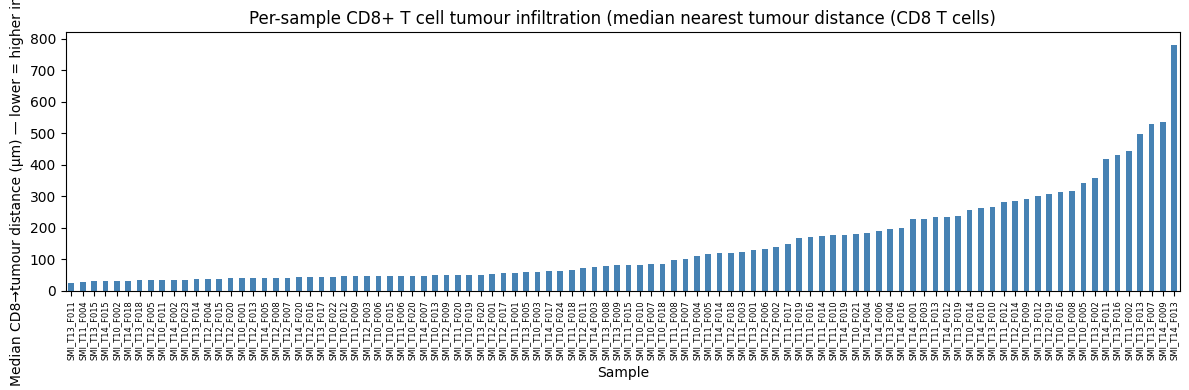

Samples with distances: 98
Range: 26.4 to 780.6 µm


In [64]:
# ============================================================
# 9b. Per-sample median distance (check no outlier samples)
# ============================================================
sample_medians = cd8_obs.groupby("samples")["nearest_tumour_dist"].median().dropna()

fig, ax = plt.subplots(figsize=(12, 4))
sample_medians.sort_values().plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Median CD8→tumour distance (µm) — lower = higher infiltration")
ax.set_xlabel("Sample")
ax.set_title("Per-sample CD8+ T cell tumour infiltration (median nearest tumour distance (CD8 T cells)")
ax.tick_params(axis="x", labelsize=6, rotation=90)
plt.tight_layout()
plt.show()

print(f"Samples with distances: {len(sample_medians)}")
print(f"Range: {sample_medians.min():.1f} to {sample_medians.max():.1f} µm")


---
### 10. Patient-Level Aggregation (Robustness Check)

Cell-level tests treat each cell as independent, but cells from the same patient are correlated.  
Here we aggregate to patient-level medians and test correlations using Spearman's ρ.

**Aggregation:**

    median_exhaustion(p) = median { exhaustion_score(i) : patient(i) = p }
    median_distance(p)   = median { D_nearest(i) : patient(i) = p }

**Spearman correlation (rank-based, robust to outliers):**

    ρ = 1 − [ 6 Σ dᵢ² / (n(n²−1)) ]

Where dᵢ is the difference in ranks between the two variables for patient i, and n = 58 patients.


Patients with complete data: 58


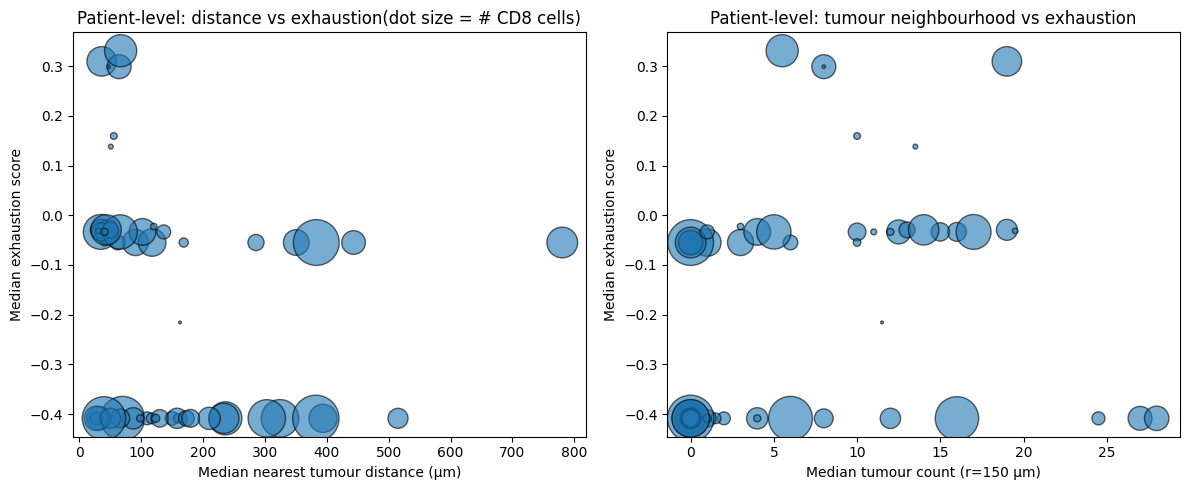

Distance vs exhaustion:      Spearman r=-0.419, p=0.001052
Tumour count vs exhaustion:  Spearman r=0.443, p=0.0005022


In [65]:
# ============================================================
# 10. Patient-level analysis
# ============================================================
patient_agg = (
    cd8_obs
    .groupby("patients")
    .agg(
        median_exhaustion=("exhaustion_score", "median"),
        median_tumour_dist=("nearest_tumour_dist", "median"),
        median_tumour_count=(tumour_count_col, "median"),
        n_cd8=("exhaustion_score", "count"),
        treatment=("treatment_clean", "first"),
        immunotherapy=("immunotherapy_clean", "first"),
        site=("site_clean", "first"),
    )
    .dropna()
)

print(f"Patients with complete data: {len(patient_agg)}")

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(patient_agg["median_tumour_dist"], patient_agg["median_exhaustion"],
                s=patient_agg["n_cd8"]*2, alpha=0.6, edgecolor="black")
axes[0].set_xlabel("Median nearest tumour distance (µm)")
axes[0].set_ylabel("Median exhaustion score")
axes[0].set_title("Patient-level: distance vs exhaustion(dot size = # CD8 cells)")

axes[1].scatter(patient_agg["median_tumour_count"], patient_agg["median_exhaustion"],
                s=patient_agg["n_cd8"]*2, alpha=0.6, edgecolor="black")
axes[1].set_xlabel(f"Median tumour count (r={RADIUS} µm)")
axes[1].set_ylabel("Median exhaustion score")
axes[1].set_title("Patient-level: tumour neighbourhood vs exhaustion")

plt.tight_layout()
plt.show()

# Spearman correlations
r1, p1 = spearmanr(patient_agg["median_tumour_dist"], patient_agg["median_exhaustion"])
r2, p2 = spearmanr(patient_agg["median_tumour_count"], patient_agg["median_exhaustion"])
print(f"Distance vs exhaustion:      Spearman r={r1:.3f}, p={p1:.4g}")
print(f"Tumour count vs exhaustion:  Spearman r={r2:.3f}, p={p2:.4g}")


In [66]:
# ============================================================
# 13e. Treatment impact analysis
# ============================================================
# Supervisor Comments 11 & 12: 
# "Would you say this suggests that treatment is not having any impact?"
# "When treatment is applied...more or less exhausted cells? 
#  Less T cells surrounded by tumour cells?"
# ============================================================

print("TREATMENT IMPACT ANALYSIS")
print("=" * 60)

for grp in ["Treated", "Untreated"]:
    subset = cd8_obs[cd8_obs["treatment_clean"] == grp]
    print(f"\n{grp} ({len(subset):,} cells):")
    print(f"  Median distance to tumour: {subset['nearest_tumour_dist'].median():.1f} µm")
    print(f"  Mean distance to tumour: {subset['nearest_tumour_dist'].mean():.1f} µm")
    print(f"  Median exhaustion score: {subset['exhaustion_score'].median():.4f}")
    print(f"  Mean exhaustion score: {subset['exhaustion_score'].mean():.4f}")
    print(f"  % in tumour-rich neighbourhood: {(subset['tumour_neighbourhood'] == 'Tumour-rich').mean()*100:.1f}%")

# Statistical comparison

treated = cd8_obs[cd8_obs["treatment_clean"] == "Treated"]
untreated = cd8_obs[cd8_obs["treatment_clean"] == "Untreated"]

stat, p = mannwhitneyu(treated["nearest_tumour_dist"].dropna(), 
                        untreated["nearest_tumour_dist"].dropna())
print(f"\nDistance: Treated vs Untreated p = {p:.2e}")

stat, p = mannwhitneyu(treated["exhaustion_score"].dropna(), 
                        untreated["exhaustion_score"].dropna())
print(f"Exhaustion: Treated vs Untreated p = {p:.2e}")

# Are treated cells further from tumours? (could indicate treatment effect)
print(f"\nTreated cells are {'FURTHER' if treated['nearest_tumour_dist'].median() > untreated['nearest_tumour_dist'].median() else 'CLOSER'} from tumours")
print(f"Treated cells are {'MORE' if treated['exhaustion_score'].median() > untreated['exhaustion_score'].median() else 'LESS'} exhausted")

TREATMENT IMPACT ANALYSIS

Treated (4,890 cells):
  Median distance to tumour: 174.7 µm
  Mean distance to tumour: 319.4 µm
  Median exhaustion score: -0.4087
  Mean exhaustion score: -0.0477
  % in tumour-rich neighbourhood: 40.7%

Untreated (3,537 cells):
  Median distance to tumour: 58.6 µm
  Mean distance to tumour: 158.0 µm
  Median exhaustion score: -0.0548
  Mean exhaustion score: 0.0651
  % in tumour-rich neighbourhood: 67.3%

Distance: Treated vs Untreated p = 8.98e-162
Exhaustion: Treated vs Untreated p = 1.50e-18

Treated cells are FURTHER from tumours
Treated cells are LESS exhausted


In [67]:
# ============================================================
# 13d. Identify immunotherapy patients
# ============================================================
# Supervisor Comment 6: "Do we know which two received immunotherapy? 
# It would be interesting to see if a different trend is observed 
# in these patients."
# ============================================================

immuno_patients = cd8_obs[cd8_obs["immunotherapy_clean"] == "Yes"]["patients"].unique()
print(f"Patients who received immunotherapy: {len(immuno_patients)}")
for p in immuno_patients:
    p_data = cd8_obs[cd8_obs["patients"] == p]
    print(f"\n  Patient: {p}")
    print(f"    CD8 T cells: {len(p_data)}")
    print(f"    Treatment: {p_data['treatment_clean'].iloc[0]}")
    print(f"    Median distance to tumour: {p_data['nearest_tumour_dist'].median():.1f} µm")
    print(f"    Median exhaustion score: {p_data['exhaustion_score'].median():.4f}")
    print(f"    Mean exhaustion score: {p_data['exhaustion_score'].mean():.4f}")

# Compare immunotherapy patients vs overall
print("\n" + "=" * 60)
print("COMPARISON: Immunotherapy patients vs all patients")
print("=" * 60)
overall_med_dist = cd8_obs["nearest_tumour_dist"].median()
overall_med_exh = cd8_obs["exhaustion_score"].median()
print(f"Overall median distance: {overall_med_dist:.1f} µm")
print(f"Overall median exhaustion: {overall_med_exh:.4f}")

Patients who received immunotherapy: 6

  Patient: HGSC8
    CD8 T cells: 177
    Treatment: Treated
    Median distance to tumour: 90.6 µm
    Median exhaustion score: -0.0548
    Mean exhaustion score: 0.0301

  Patient: HGSC2
    CD8 T cells: 226
    Treatment: Untreated
    Median distance to tumour: 36.1 µm
    Median exhaustion score: 0.3098
    Mean exhaustion score: 0.3907

  Patient: HGSC112
    CD8 T cells: 488
    Treatment: Untreated
    Median distance to tumour: 39.7 µm
    Median exhaustion score: -0.4087
    Mean exhaustion score: -0.1031

  Patient: HGSC33
    CD8 T cells: 80
    Treatment: Untreated
    Median distance to tumour: 130.0 µm
    Median exhaustion score: -0.4087
    Mean exhaustion score: -0.0055

  Patient: HGSC58
    CD8 T cells: 2
    Treatment: Untreated
    Median distance to tumour: 162.6 µm
    Median exhaustion score: -0.2157
    Mean exhaustion score: -0.2157

  Patient: HGSC42
    CD8 T cells: 205
    Treatment: Treated
    Median distance to tu

In [68]:
# Show all immunotherapy patients without truncation
for p in immuno_patients:
    p_data = cd8_obs[cd8_obs["patients"] == p]
    print(f"Patient: {p} | Cells: {len(p_data)} | Treatment: {p_data['treatment_clean'].iloc[0]} | "
          f"Infiltration (dist): {p_data['nearest_tumour_dist'].median():.1f} µm | "
          f"Exhaustion: {p_data['exhaustion_score'].median():.4f}")

Patient: HGSC8 | Cells: 177 | Treatment: Treated | Infiltration (dist): 90.6 µm | Exhaustion: -0.0548
Patient: HGSC2 | Cells: 226 | Treatment: Untreated | Infiltration (dist): 36.1 µm | Exhaustion: 0.3098
Patient: HGSC112 | Cells: 488 | Treatment: Untreated | Infiltration (dist): 39.7 µm | Exhaustion: -0.4087
Patient: HGSC33 | Cells: 80 | Treatment: Untreated | Infiltration (dist): 130.0 µm | Exhaustion: -0.4087
Patient: HGSC58 | Cells: 2 | Treatment: Untreated | Infiltration (dist): 162.6 µm | Exhaustion: -0.2157
Patient: HGSC42 | Cells: 205 | Treatment: Treated | Infiltration (dist): 393.8 µm | Exhaustion: -0.4087


In [69]:
# ============================================================
# 13f. Individual exhaustion marker analysis
# ============================================================
# Supervisor Comment 13: "Do these 4 markers must be overexpressed to 
# indicate exhaustion? If not, when averaging them, we might lose some info."
# 
# Check: do individual markers tell different stories than the average?
# ============================================================

markers = ["PDCD1", "LAG3", "HAVCR2", "CTLA4"]

print("INDIVIDUAL MARKER ANALYSIS")
print("=" * 60)

# 1. How often are they co-expressed?
print("\n1. Co-expression patterns:")
for m in markers:
    pct = (cd8_obs[m] > 0).mean() * 100
    print(f"  {m} expressed (>0): {pct:.1f}%")

# How many markers are expressed per cell?
n_expressed = sum((cd8_obs[m] > 0).astype(int) for m in markers)
print(f"\n  Cells expressing 0 markers: {(n_expressed == 0).mean()*100:.1f}%")
print(f"  Cells expressing 1 marker:  {(n_expressed == 1).mean()*100:.1f}%")
print(f"  Cells expressing 2 markers: {(n_expressed == 2).mean()*100:.1f}%")
print(f"  Cells expressing 3 markers: {(n_expressed == 3).mean()*100:.1f}%")
print(f"  Cells expressing 4 markers: {(n_expressed == 4).mean()*100:.1f}%")

# 2. Individual marker correlation with distance
print("\n2. Individual marker correlation with tumour distance:")
for m in markers:
    valid = cd8_obs.dropna(subset=["nearest_tumour_dist", m])
    r, p = spearmanr(valid["nearest_tumour_dist"], valid[m])
    print(f"  {m}: Spearman r = {r:.4f}, p = {p:.2e}")

# Compare with composite score
valid = cd8_obs.dropna(subset=["nearest_tumour_dist", "exhaustion_score"])
r, p = spearmanr(valid["nearest_tumour_dist"], valid["exhaustion_score"])
print(f"  Composite score: Spearman r = {r:.4f}, p = {p:.2e}")

# 3. Do individual markers give different treatment effects?
print("\n3. Treatment effect per marker (Treated vs Untreated median):")
for m in markers:
    t_med = treated[m].median()
    u_med = untreated[m].median()
    stat, p = mannwhitneyu(treated[m].dropna(), untreated[m].dropna())
    print(f"  {m}: Treated={t_med:.4f}, Untreated={u_med:.4f}, p={p:.2e}")

INDIVIDUAL MARKER ANALYSIS

1. Co-expression patterns:
  PDCD1 expressed (>0): 20.5%
  LAG3 expressed (>0): 21.7%
  HAVCR2 expressed (>0): 17.4%
  CTLA4 expressed (>0): 16.2%

  Cells expressing 0 markers: 48.7%
  Cells expressing 1 marker:  32.7%
  Cells expressing 2 markers: 13.5%
  Cells expressing 3 markers: 4.1%
  Cells expressing 4 markers: 0.9%

2. Individual marker correlation with tumour distance:
  PDCD1: Spearman r = -0.0936, p = 7.06e-18
  LAG3: Spearman r = -0.1136, p = 1.21e-25
  HAVCR2: Spearman r = -0.1392, p = 9.33e-38
  CTLA4: Spearman r = -0.0874, p = 8.66e-16
  Composite score: Spearman r = -0.1795, p = 4.51e-62

3. Treatment effect per marker (Treated vs Untreated median):
  PDCD1: Treated=0.0000, Untreated=0.0000, p=2.22e-02
  LAG3: Treated=0.0000, Untreated=0.0000, p=6.86e-10
  HAVCR2: Treated=0.0000, Untreated=0.0000, p=9.68e-16
  CTLA4: Treated=0.0000, Untreated=0.0000, p=1.44e-06


Q1: Is exhaustion driven by tumour cell percentage?
KNN tumour fraction vs exhaustion: r = 0.1665, p = 1.59e-53
Tumour count (r=150µm) vs exhaustion: r = 0.1669, p = 9.09e-54
Nearest tumour distance vs exhaustion: r = -0.1795, p = 4.51e-62

→ All three spatial measures correlate with exhaustion,
  but correlations are modest (|r| < 0.2), suggesting tumour
  proximity contributes to exhaustion but is NOT the only factor.


Q2: Is there a tumour count threshold for exhaustion?
Tumour count       N cells    Mean exhaustion  Median exhaustion
-----------------------------------------------------------------
0                    3,629            -0.1040            -0.4087
1-2                    728            -0.0224            -0.4087
3-4                    535            -0.0107            -0.0548
5-9                    927             0.1295            -0.0335
10-19                1,453             0.1194            -0.0335
20-49                1,166             0.0913            -0.0335

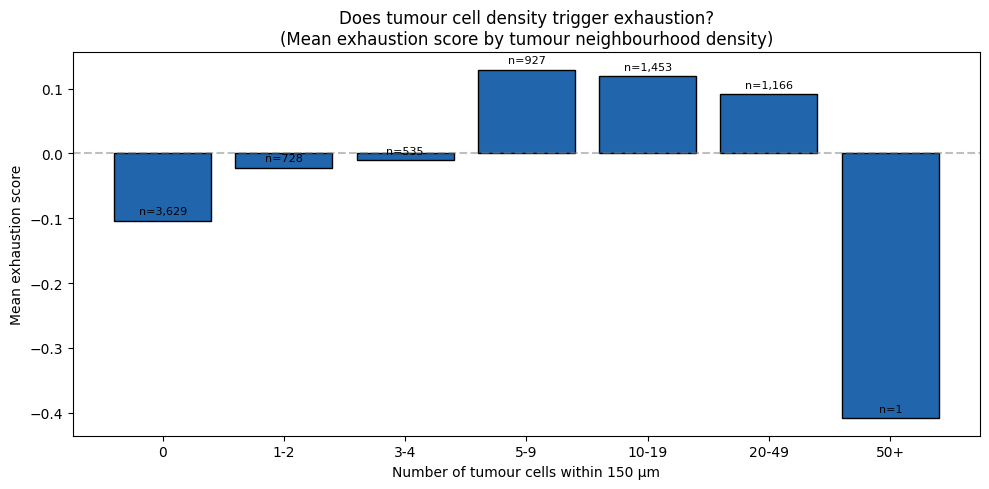

In [70]:
# ============================================================
# 13h. Discussion questions from supervisor
# ============================================================
# Q1: Are T cells exhausted because of the % of surrounding tumour 
#     cells? Or did they become exhausted due to other changes 
#     in the environment?
# Q2: Is there a threshold, such that if the T cell is surrounded 
#     by more than x malignant cells it becomes exhausted?
# ============================================================

tumour_col = f"tumour_count_r{RADIUS}"

# Q1: Correlation between tumour % and exhaustion
print("Q1: Is exhaustion driven by tumour cell percentage?")
print("=" * 60)

# Tumour fraction in KNN neighbourhood vs exhaustion
r, p = spearmanr(cd8_obs[f"tumour_frac_knn_{K}"].dropna(), 
                 cd8_obs.loc[cd8_obs[f"tumour_frac_knn_{K}"].notna(), "exhaustion_score"])
print(f"KNN tumour fraction vs exhaustion: r = {r:.4f}, p = {p:.2e}")

# Tumour count vs exhaustion  
r, p = spearmanr(cd8_obs[tumour_col].dropna(), 
                 cd8_obs.loc[cd8_obs[tumour_col].notna(), "exhaustion_score"])
print(f"Tumour count (r={RADIUS}µm) vs exhaustion: r = {r:.4f}, p = {p:.2e}")

# Distance vs exhaustion
r, p = spearmanr(cd8_obs["nearest_tumour_dist"].dropna(), 
                 cd8_obs.loc[cd8_obs["nearest_tumour_dist"].notna(), "exhaustion_score"])
print(f"Nearest tumour distance vs exhaustion: r = {r:.4f}, p = {p:.2e}")

print("\n→ All three spatial measures correlate with exhaustion,")
print("  but correlations are modest (|r| < 0.2), suggesting tumour")
print("  proximity contributes to exhaustion but is NOT the only factor.")

# Q2: Is there a threshold?
print("\n\nQ2: Is there a tumour count threshold for exhaustion?")
print("=" * 60)

# Bin cells by tumour count and calculate mean exhaustion per bin
bins = [0, 1, 3, 5, 10, 20, 50, 1000]
labels = ["0", "1-2", "3-4", "5-9", "10-19", "20-49", "50+"]
cd8_obs["tumour_bin"] = pd.cut(cd8_obs[tumour_col], bins=bins, labels=labels, right=False)

print(f"{'Tumour count':<15} {'N cells':>10} {'Mean exhaustion':>18} {'Median exhaustion':>18}")
print("-" * 65)
for label in labels:
    subset = cd8_obs[cd8_obs["tumour_bin"] == label]
    if len(subset) > 0:
        print(f"{label:<15} {len(subset):>10,} {subset['exhaustion_score'].mean():>18.4f} {subset['exhaustion_score'].median():>18.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
means = [cd8_obs[cd8_obs["tumour_bin"] == l]["exhaustion_score"].mean() for l in labels if len(cd8_obs[cd8_obs["tumour_bin"] == l]) > 0]
valid_labels = [l for l in labels if len(cd8_obs[cd8_obs["tumour_bin"] == l]) > 0]
counts = [len(cd8_obs[cd8_obs["tumour_bin"] == l]) for l in valid_labels]

ax.bar(range(len(valid_labels)), means, color="#2166ac", edgecolor="black")
ax.set_xticks(range(len(valid_labels)))
ax.set_xticklabels(valid_labels)
ax.set_xlabel(f"Number of tumour cells within {RADIUS} µm")
ax.set_ylabel("Mean exhaustion score")
ax.set_title("Does tumour cell density trigger exhaustion?\n(Mean exhaustion score by tumour neighbourhood density)")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)

# Add cell counts on bars
for i, (v, n) in enumerate(zip(means, counts)):
    ax.text(i, v + 0.01, f"n={n:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

---
### 11. CD47 / TSP-1 / PD1 Infiltration Analysis

**Research question:** Do CD8+ T cells with low expression of CD47, TSP-1 (THBS1), and PD1 (PDCD1)  
infiltrate tumours better — i.e., are they physically closer to malignant cells?

**Approach:** For each marker m, split CD8+ T cells into High/Low expression groups:

    Low expression:  xᵢ_m <  median(expression_m)   [or = 0 for zero-inflated markers]
    High expression: xᵢ_m ≥  median(expression_m)   [or > 0 for zero-inflated markers]

Then compare nearest tumour distance D_nearest between High and Low groups using Mann-Whitney U.

Extended to **19 infiltration-related genes** across five functional categories:
- Checkpoint receptors: PDCD1, CD274, CD47, TIGIT
- Chemokine receptors: CXCR3, CXCR4, CCR5, CCR7
- Chemokines: CXCL9, CXCL10, CCL5
- Adhesion molecules: ITGB2, ITGAL, ICAM1, VCAM1, SELL
- Other: THBS1 (TSP-1), MMP2, MMP9


In [71]:
# ============================================================
# 11. CD47/TSP-1/PD1 Infiltration Analysis (Objective 4)
# ============================================================
# 11a. Check if markers are available
# ============================================================
infiltration_markers = ["CD47", "THBS1", "PDCD1"]
for m in infiltration_markers:
    if m in data.var_names:
        print(f"{m} found in dataset")
    else:
        print(f"{m} NOT found in dataset")

CD47 found in dataset
THBS1 found in dataset
PDCD1 found in dataset


In [72]:
# ============================================================
# 11b. Extract infiltration marker expression for CD8+ T cells
# ============================================================
infiltration_markers = ["CD47", "THBS1", "PDCD1"]
marker_idx = [list(data.var_names).index(m) for m in infiltration_markers]

X_inf = data.X[cd8_mask.values][:, marker_idx]
if hasattr(X_inf, 'toarray'):
    X_inf = X_inf.toarray()

df_inf = pd.DataFrame(X_inf, columns=infiltration_markers, index=cd8_obs.index)
for m in infiltration_markers:
    cd8_obs[m] = df_inf[m].values

# Quick check
for m in infiltration_markers:
    expr = cd8_obs[m]
    pct_expressing = (expr > 0).mean() * 100
    print(f"{m}: mean={expr.mean():.4f}, median={expr.median():.4f}, "
          f"% expressing={pct_expressing:.1f}%")

CD47: mean=0.3491, median=0.0000, % expressing=24.6%
THBS1: mean=0.3098, median=0.0000, % expressing=18.2%
PDCD1: mean=0.3048, median=0.0000, % expressing=20.5%


In [73]:
# ============================================================
# 11c. Define High vs Low expression groups for each marker
# ============================================================
# Split CD8 T cells into High vs Low expression for each marker
# Using median split (0 vs >0 for zero-inflated markers)

for m in infiltration_markers:
    expr = cd8_obs[m]
    if expr.median() == 0:
        # Zero-inflated: split by expressing vs non-expressing
        cd8_obs[f"{m}_group"] = np.where(expr > 0, "High", "Low")
        print(f"{m}: split by >0 (expressing vs non-expressing)")
    else:
        # Use median split
        med = expr.median()
        cd8_obs[f"{m}_group"] = np.where(expr >= med, "High", "Low")
        print(f"{m}: split by median ({med:.4f})")
    
    print(cd8_obs[f"{m}_group"].value_counts())
    print()

CD47: split by >0 (expressing vs non-expressing)
CD47_group
Low     6364
High    2075
Name: count, dtype: int64

THBS1: split by >0 (expressing vs non-expressing)
THBS1_group
Low     6906
High    1533
Name: count, dtype: int64

PDCD1: split by >0 (expressing vs non-expressing)
PDCD1_group
Low     6706
High    1733
Name: count, dtype: int64



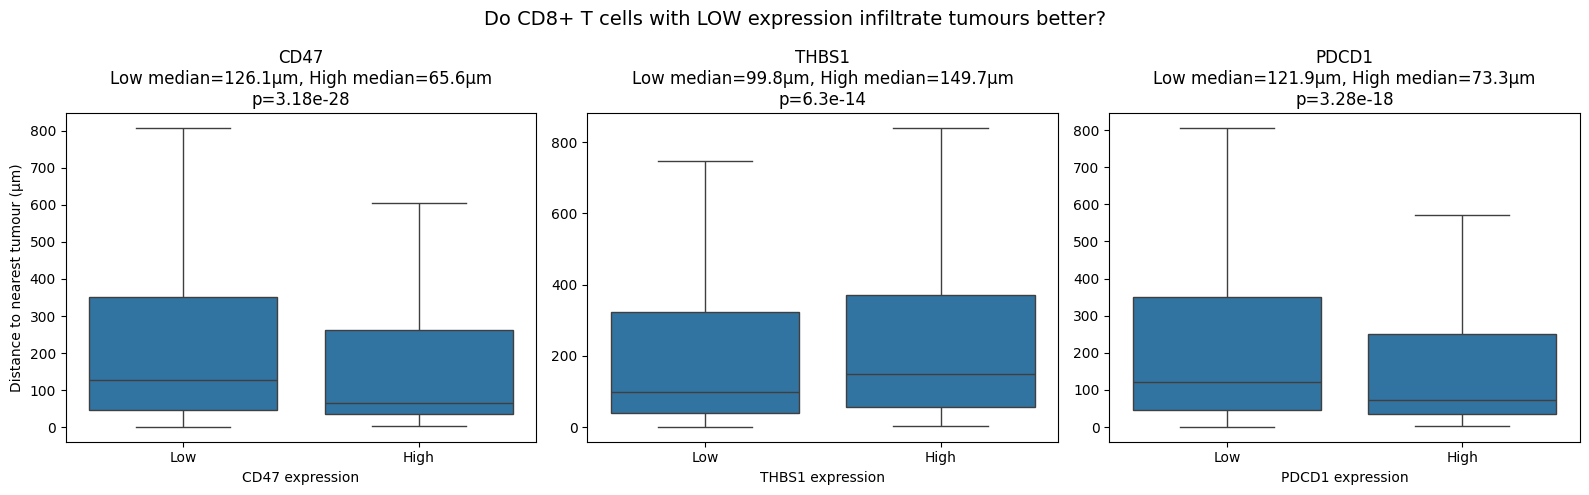

INFILTRATION ANALYSIS SUMMARY
CD47: Low median=126.1µm (n=6,364), High median=65.6µm (n=2,075), p=3.18e-28 → NO — High closer
THBS1: Low median=99.8µm (n=6,906), High median=149.7µm (n=1,533), p=6.3e-14 → YES — Low closer
PDCD1: Low median=121.9µm (n=6,706), High median=73.3µm (n=1,733), p=3.28e-18 → NO — High closer


In [74]:
# ============================================================
# 11d. Compare tumour infiltration: High vs Low expression
# ============================================================
# KEY QUESTION: Do CD8 T cells with LOW expression infiltrate better
# (i.e., are they CLOSER to tumour cells)?

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, m in enumerate(infiltration_markers):
    group_col = f"{m}_group"
    
    sns.boxplot(data=cd8_obs, x=group_col, y="nearest_tumour_dist",
                order=["Low", "High"], showfliers=False, ax=axes[i])
    
    low = cd8_obs.loc[cd8_obs[group_col] == "Low", "nearest_tumour_dist"].dropna()
    high = cd8_obs.loc[cd8_obs[group_col] == "High", "nearest_tumour_dist"].dropna()
    
    _, p = mannwhitneyu(low, high, alternative="two-sided")
    axes[i].set_title(f"{m}\nLow median={low.median():.1f}µm, High median={high.median():.1f}µm\np={p:.3g}")
    axes[i].set_xlabel(f"{m} expression")
    axes[i].set_ylabel("Distance to nearest tumour (µm)" if i == 0 else "")

plt.suptitle("Do CD8+ T cells with LOW expression infiltrate tumours better?", fontsize=14)
plt.tight_layout()
plt.show()

# Summary
print("=" * 70)
print("INFILTRATION ANALYSIS SUMMARY")
print("=" * 70)
for m in infiltration_markers:
    group_col = f"{m}_group"
    low = cd8_obs.loc[cd8_obs[group_col] == "Low", "nearest_tumour_dist"].dropna()
    high = cd8_obs.loc[cd8_obs[group_col] == "High", "nearest_tumour_dist"].dropna()
    _, p = mannwhitneyu(low, high, alternative="two-sided")
    direction = "YES — Low closer" if low.median() < high.median() else "NO — High closer"
    print(f"{m}: Low median={low.median():.1f}µm (n={len(low):,}), "
          f"High median={high.median():.1f}µm (n={len(high):,}), "
          f"p={p:.3g} → {direction}")

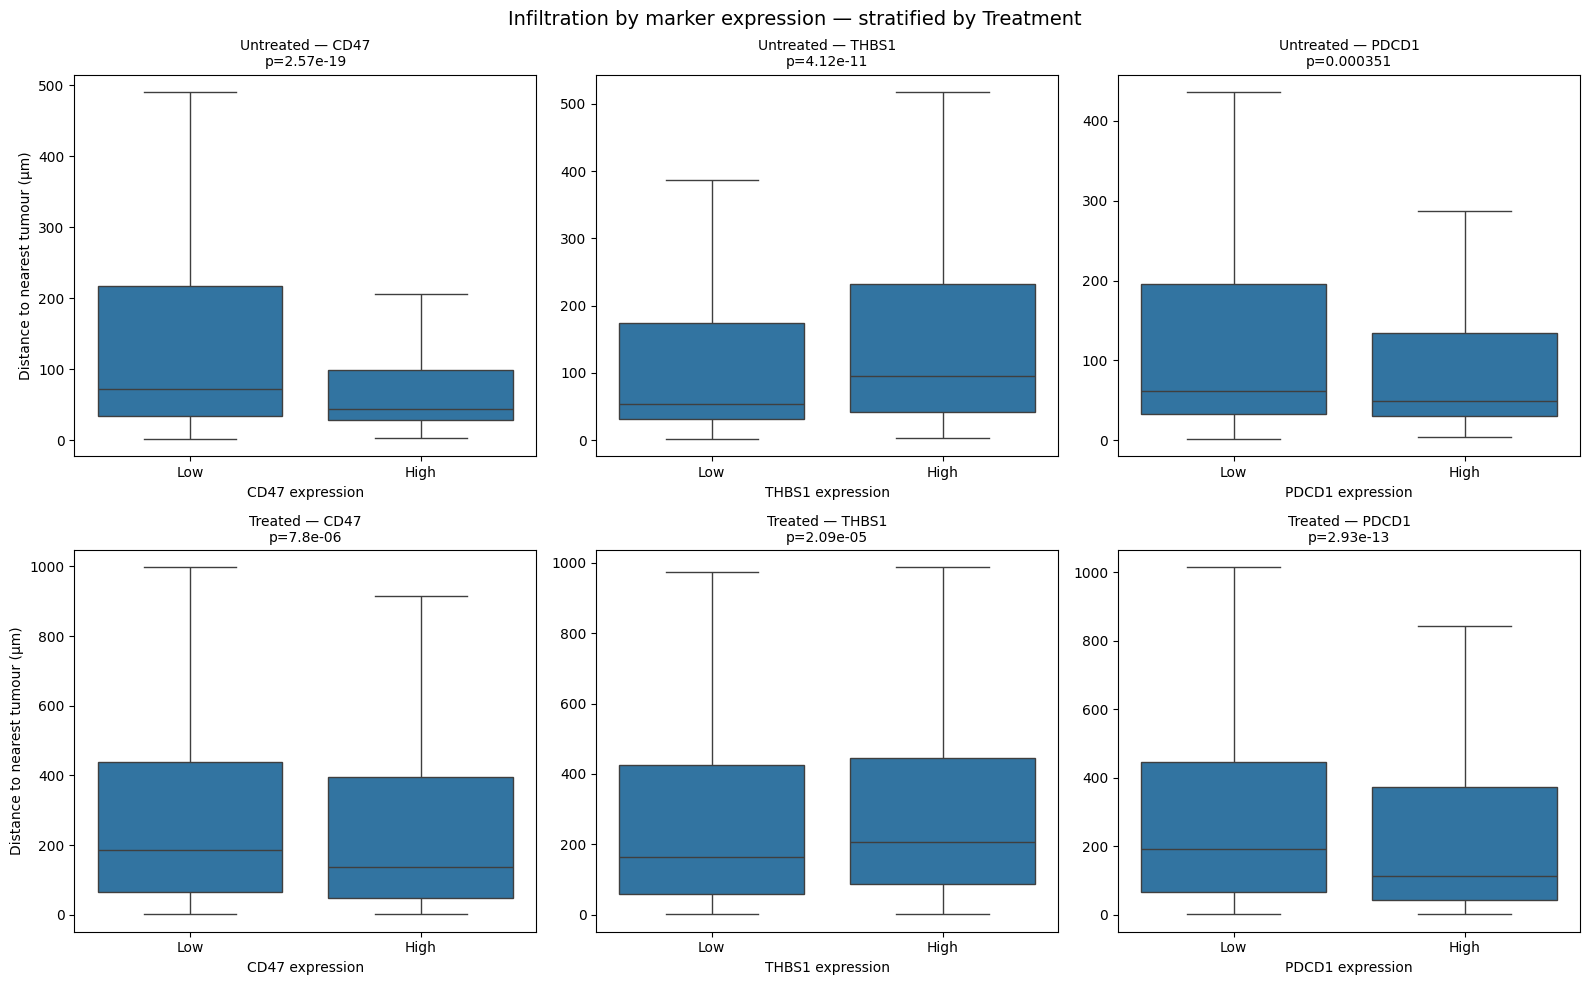

INFILTRATION BY TREATMENT GROUP

Untreated (n=3,537):
  CD47: Low=71.5µm (n=2,540) vs High=43.9µm (n=997), p=2.57e-19
  THBS1: Low=53.7µm (n=2,909) vs High=95.7µm (n=628), p=4.12e-11
  PDCD1: Low=62.2µm (n=2,766) vs High=49.5µm (n=771), p=0.000351

Treated (n=4,890):
  CD47: Low=184.5µm (n=3,816) vs High=137.3µm (n=1,074), p=7.8e-06
  THBS1: Low=164.7µm (n=3,990) vs High=207.7µm (n=900), p=2.09e-05
  PDCD1: Low=191.2µm (n=3,930) vs High=112.5µm (n=960), p=2.93e-13


In [75]:
# ============================================================
# 11e. Infiltration analysis stratified by Treatment group
# ============================================================
# Does the infiltration pattern differ between Treated and Untreated?

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row, treatment in enumerate(["Untreated", "Treated"]):
    subset = cd8_obs[cd8_obs["treatment_clean"] == treatment]
    
    for col, m in enumerate(infiltration_markers):
        group_col = f"{m}_group"
        
        sns.boxplot(data=subset, x=group_col, y="nearest_tumour_dist",
                    order=["Low", "High"], showfliers=False, ax=axes[row, col])
        
        low = subset.loc[subset[group_col] == "Low", "nearest_tumour_dist"].dropna()
        high = subset.loc[subset[group_col] == "High", "nearest_tumour_dist"].dropna()
        
        if len(low) > 0 and len(high) > 0:
            _, p = mannwhitneyu(low, high, alternative="two-sided")
            axes[row, col].set_title(f"{treatment} — {m}\np={p:.3g}", fontsize=10)
        else:
            axes[row, col].set_title(f"{treatment} — {m}", fontsize=10)
        
        axes[row, col].set_xlabel(f"{m} expression")
        axes[row, col].set_ylabel("Distance to nearest tumour (µm)" if col == 0 else "")

plt.suptitle("Infiltration by marker expression — stratified by Treatment", fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
print("=" * 70)
print("INFILTRATION BY TREATMENT GROUP")
print("=" * 70)
for treatment in ["Untreated", "Treated"]:
    subset = cd8_obs[cd8_obs["treatment_clean"] == treatment]
    print(f"\n{treatment} (n={len(subset):,}):")
    for m in infiltration_markers:
        group_col = f"{m}_group"
        low = subset.loc[subset[group_col] == "Low", "nearest_tumour_dist"].dropna()
        high = subset.loc[subset[group_col] == "High", "nearest_tumour_dist"].dropna()
        if len(low) > 0 and len(high) > 0:
            _, p = mannwhitneyu(low, high, alternative="two-sided")
            print(f"  {m}: Low={low.median():.1f}µm (n={len(low):,}) vs "
                  f"High={high.median():.1f}µm (n={len(high):,}), p={p:.3g}")

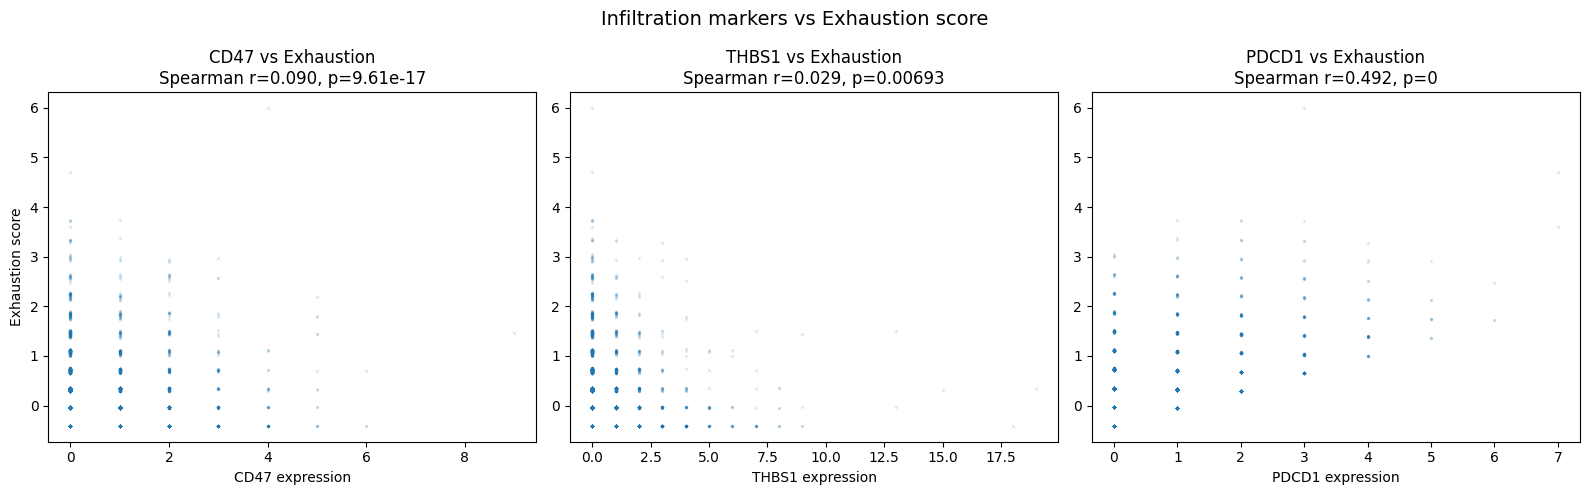

In [76]:
# ============================================================
# 11f. CD47 expression vs exhaustion score
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, m in enumerate(infiltration_markers):
    axes[i].scatter(cd8_obs[m], cd8_obs["exhaustion_score"], s=2, alpha=0.1)
    r, p = spearmanr(cd8_obs[m].dropna(), cd8_obs["exhaustion_score"].dropna())
    axes[i].set_xlabel(f"{m} expression")
    axes[i].set_ylabel("Exhaustion score" if i == 0 else "")
    axes[i].set_title(f"{m} vs Exhaustion\nSpearman r={r:.3f}, p={p:.3g}")

plt.suptitle("Infiltration markers vs Exhaustion score", fontsize=14)
plt.tight_layout()
plt.show()

In [78]:
# ============================================================
# 11g. Available infiltration-related genes in dataset (reference)
# ============================================================
# 19/21 genes found — currently using CD47, THBS1, PDCD1 as per proposal.
# Additional markers available if needed for extended analysis.
# ============================================================
# Check for infiltration-related genes in dataset
# ============================================================
infiltration_genes = {
    # Chemokine receptors (T cell homing/migration)
    "CXCR3": "T cell homing to tumours",
    "CXCR4": "T cell migration",
    "CCR5": "T cell recruitment",
    "CCR7": "Lymph node homing",
    
    # Chemokines (attract T cells)
    "CXCL9": "T cell attractant",
    "CXCL10": "T cell attractant",
    "CXCL13": "B/T cell attractant",
    "CCL5": "T cell recruitment",
    
    # Adhesion molecules (tissue entry)
    "ITGB2": "Integrin beta-2 (LFA-1)",
    "ITGAL": "Integrin alpha-L (LFA-1)",
    "ICAM1": "Intercellular adhesion",
    "VCAM1": "Vascular adhesion",
    "SELL": "L-selectin (lymph node entry)",
    
    # CD47-TSP1 axis
    "CD47": "Don't-eat-me signal",
    "THBS1": "TSP-1 (CD47 ligand)",
    "SIRPA": "CD47 receptor on macrophages",
    
    # Matrix/migration
    "MMP9": "Matrix remodelling",
    "MMP2": "Matrix remodelling",
    
    # Immune checkpoint (dual role)
    "PDCD1": "PD-1",
    "CD274": "PD-L1",
    "TIGIT": "Checkpoint/migration",
}

print(f"{'Gene':<10} {'Found':<8} {'Role'}")
print("-" * 60)
found = []
for gene, role in infiltration_genes.items():
    in_data = gene in data.var_names
    status = "Yes" if in_data else "No"
    print(f"{gene:<10} {status:<8} {role}")
    if in_data:
        found.append(gene)

print(f"\nFound {len(found)} / {len(infiltration_genes)} infiltration-related genes")
print(f"Available: {found}")

Gene       Found    Role
------------------------------------------------------------
CXCR3      Yes      T cell homing to tumours
CXCR4      Yes      T cell migration
CCR5       Yes      T cell recruitment
CCR7       Yes      Lymph node homing
CXCL9      Yes      T cell attractant
CXCL10     Yes      T cell attractant
CXCL13     No       B/T cell attractant
CCL5       Yes      T cell recruitment
ITGB2      Yes      Integrin beta-2 (LFA-1)
ITGAL      Yes      Integrin alpha-L (LFA-1)
ICAM1      Yes      Intercellular adhesion
VCAM1      Yes      Vascular adhesion
SELL       Yes      L-selectin (lymph node entry)
CD47       Yes      Don't-eat-me signal
THBS1      Yes      TSP-1 (CD47 ligand)
SIRPA      No       CD47 receptor on macrophages
MMP9       Yes      Matrix remodelling
MMP2       Yes      Matrix remodelling
PDCD1      Yes      PD-1
CD274      Yes      PD-L1
TIGIT      Yes      Checkpoint/migration

Found 19 / 21 infiltration-related genes
Available: ['CXCR3', 'CXCR4', 'CCR5', '

In [79]:
# ============================================================
# 11h. Extended Infiltration Analysis — All Available Markers
# ============================================================
extended_markers = {
    "Chemokine receptors": ["CXCR3", "CXCR4", "CCR5", "CCR7"],
    "Chemokines": ["CXCL9", "CXCL10", "CCL5"],
    "Adhesion molecules": ["ITGB2", "ITGAL", "ICAM1", "VCAM1", "SELL"],
    "CD47-TSP1 axis": ["CD47", "THBS1"],
    "Matrix remodelling": ["MMP9", "MMP2"],
    "Immune checkpoint": ["PDCD1", "CD274", "TIGIT"],
}

all_markers = []
for group, genes in extended_markers.items():
    all_markers.extend(genes)

# Extract expression for all markers
marker_idx = [list(data.var_names).index(m) for m in all_markers]
X_ext = data.X[cd8_mask.values][:, marker_idx]
if hasattr(X_ext, 'toarray'):
    X_ext = X_ext.toarray()

df_ext = pd.DataFrame(X_ext, columns=all_markers, index=cd8_obs.index)
for m in all_markers:
    cd8_obs[m] = df_ext[m].values

# Define High/Low groups
for m in all_markers:
    expr = cd8_obs[m]
    if expr.median() == 0:
        cd8_obs[f"{m}_group"] = np.where(expr > 0, "High", "Low")
    else:
        med = expr.median()
        cd8_obs[f"{m}_group"] = np.where(expr >= med, "High", "Low")

# Compare distance: High vs Low for ALL markers
print(f"{'Marker':<10} {'Low median':>12} {'High median':>12} {'p-value':>12} {'Result':<20}")
print("-" * 70)

results = []
for m in all_markers:
    group_col = f"{m}_group"
    low = cd8_obs.loc[cd8_obs[group_col] == "Low", "nearest_tumour_dist"].dropna()
    high = cd8_obs.loc[cd8_obs[group_col] == "High", "nearest_tumour_dist"].dropna()
    _, p = mannwhitneyu(low, high, alternative="two-sided")
    direction = "Low closer" if low.median() < high.median() else "High closer"
    print(f"{m:<10} {low.median():>10.1f}µm {high.median():>10.1f}µm {p:>12.3g} {direction:<20}")
    results.append({"marker": m, "low_median": low.median(), "high_median": high.median(), 
                     "p": p, "direction": direction, "n_low": len(low), "n_high": len(high)})

Marker       Low median  High median      p-value Result              
----------------------------------------------------------------------
CXCR3           112.3µm      100.6µm       0.0129 High closer         
CXCR4            83.9µm      139.2µm     7.96e-31 Low closer          
CCR5            117.0µm       92.1µm     9.27e-06 High closer         
CCR7            109.1µm      116.3µm        0.285 Low closer          
CXCL9           117.9µm       84.0µm     2.57e-08 High closer         
CXCL10          131.2µm       57.2µm     1.56e-61 High closer         
CCL5            144.9µm       84.6µm     2.04e-35 High closer         
ITGB2           120.4µm       98.4µm      0.00299 High closer         
ITGAL           116.0µm      101.1µm       0.0241 High closer         
ICAM1           116.9µm       73.0µm     7.01e-11 High closer         
VCAM1           111.4µm       99.7µm        0.073 High closer         
SELL            104.2µm      174.0µm        4e-13 Low closer          
CD47  

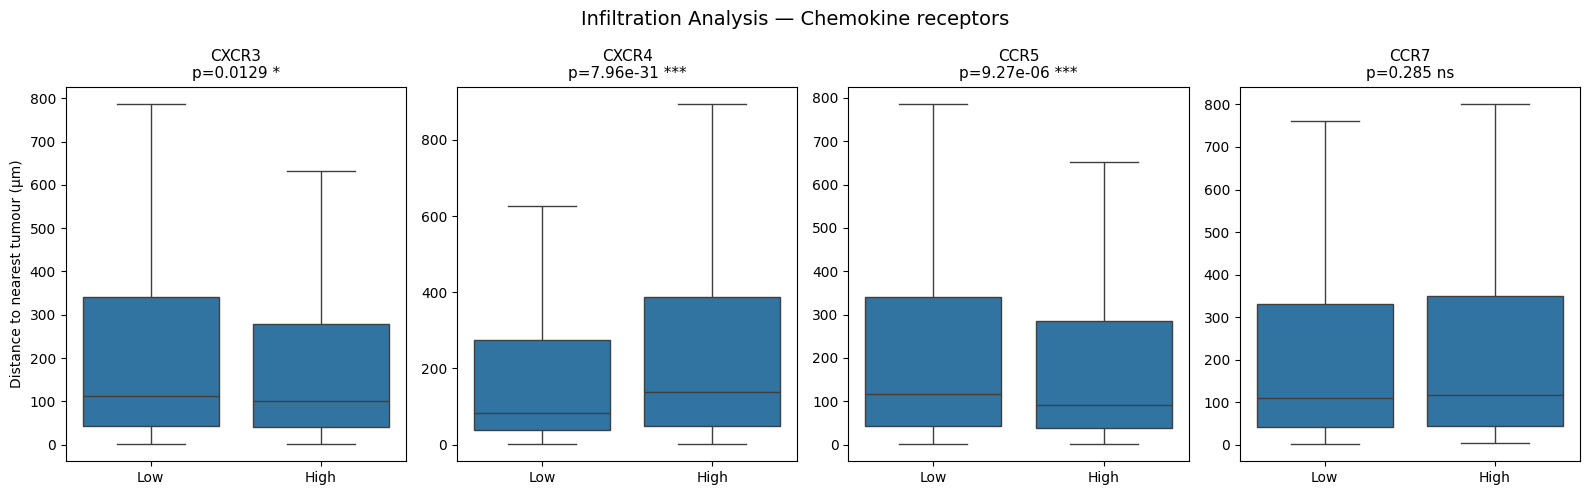

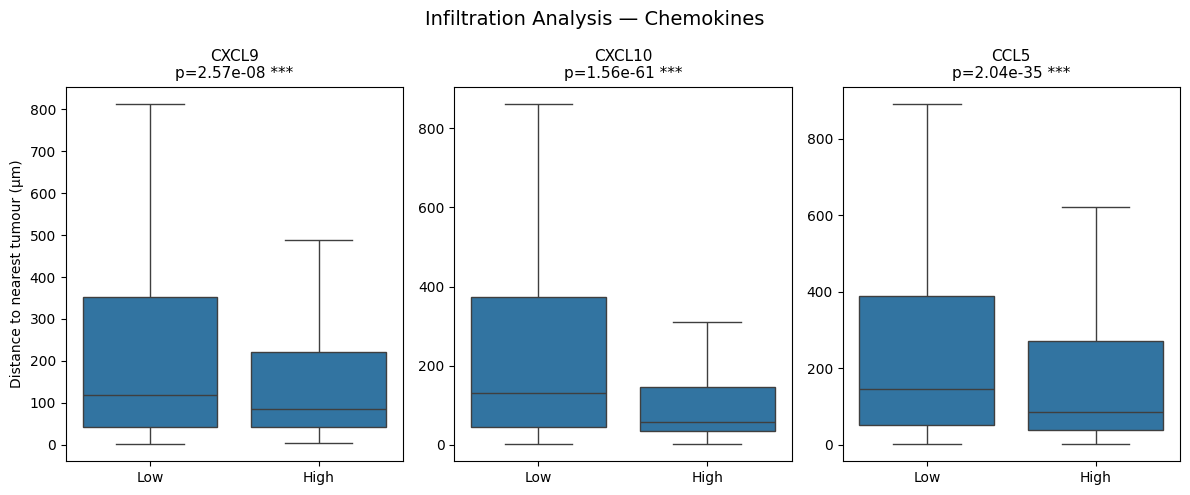

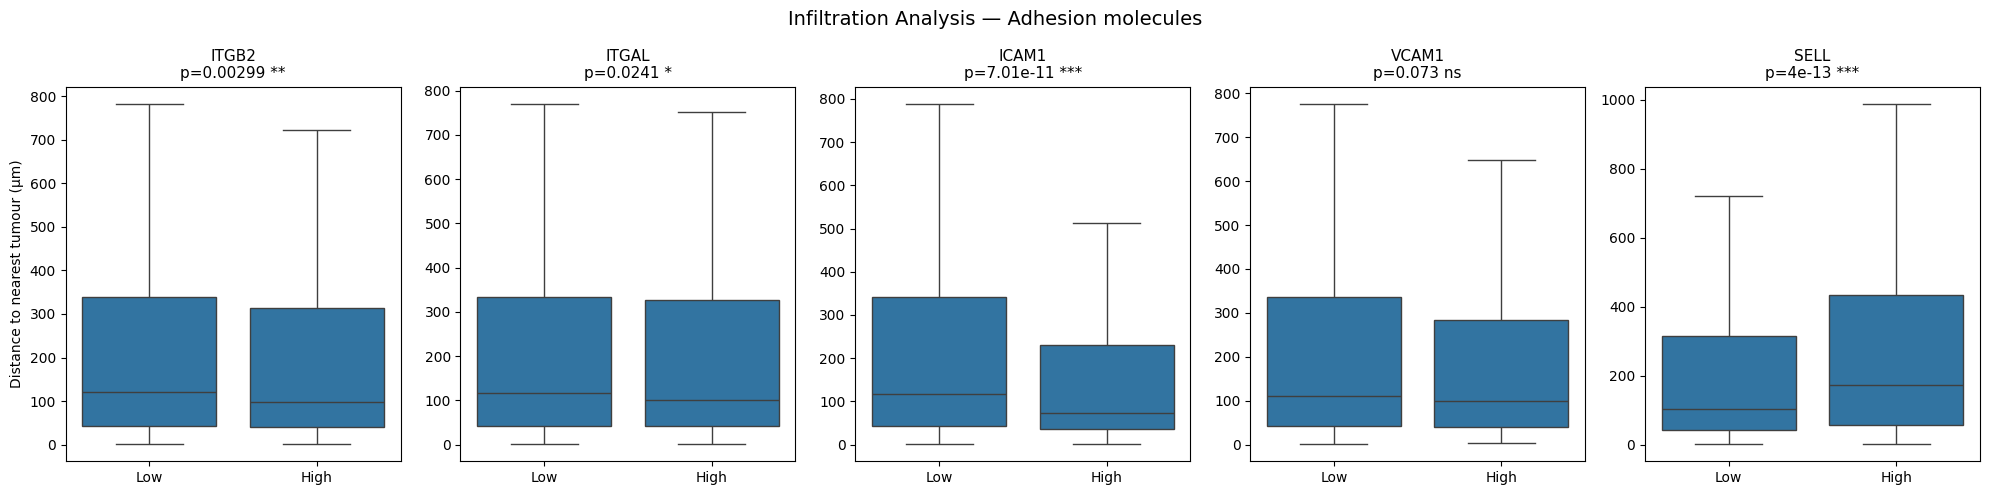

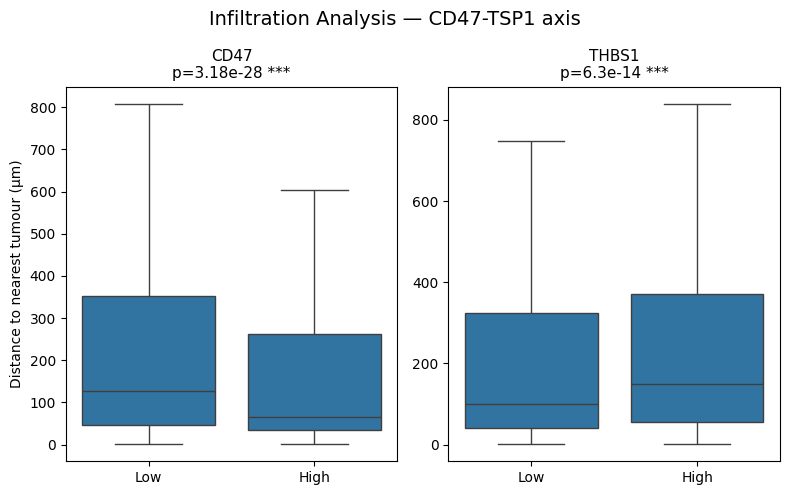

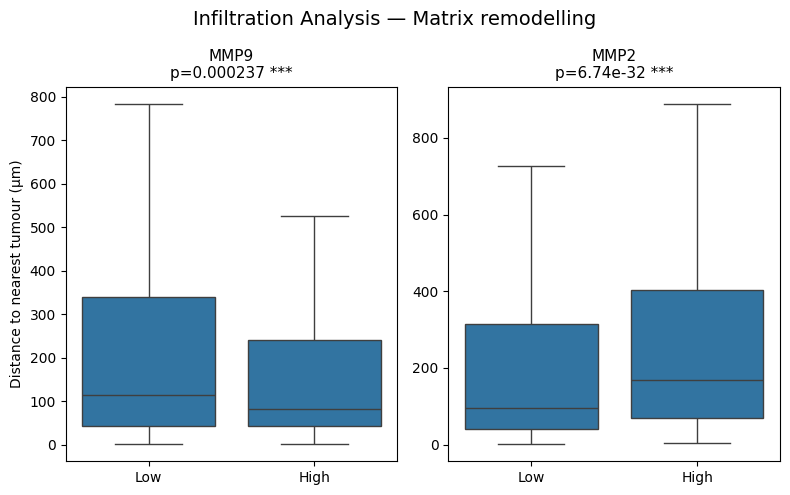

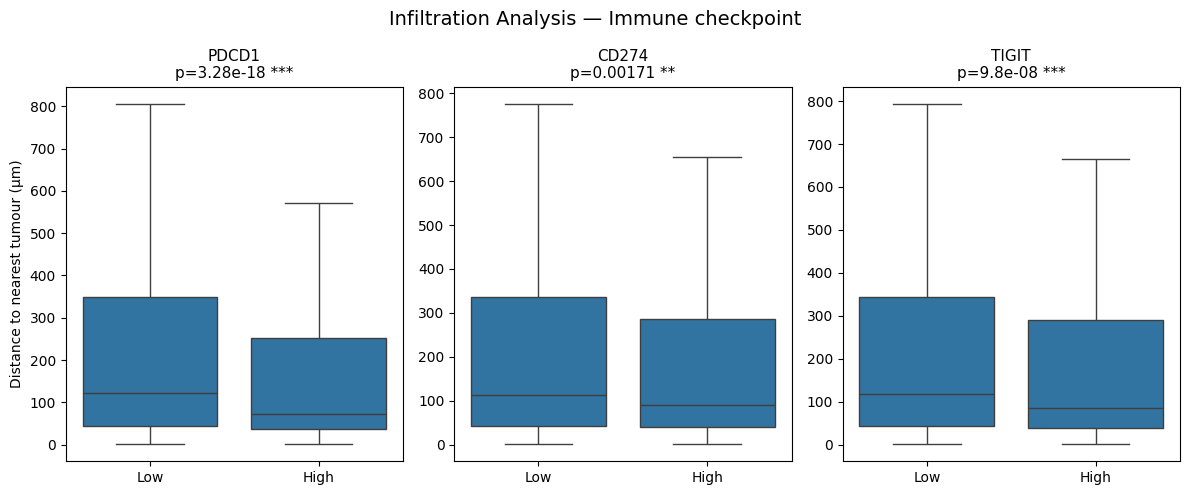

In [80]:
# ============================================================
# 11i. Grouped Infiltration Boxplots by Category
# ============================================================
categories = {
    "Chemokine receptors": ["CXCR3", "CXCR4", "CCR5", "CCR7"],
    "Chemokines": ["CXCL9", "CXCL10", "CCL5"],
    "Adhesion molecules": ["ITGB2", "ITGAL", "ICAM1", "VCAM1", "SELL"],
    "CD47-TSP1 axis": ["CD47", "THBS1"],
    "Matrix remodelling": ["MMP9", "MMP2"],
    "Immune checkpoint": ["PDCD1", "CD274", "TIGIT"],
}

for cat_name, cat_markers in categories.items():
    n = len(cat_markers)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
    if n == 1:
        axes = [axes]
    
    for i, m in enumerate(cat_markers):
        group_col = f"{m}_group"
        sns.boxplot(data=cd8_obs, x=group_col, y="nearest_tumour_dist",
                    order=["Low", "High"], showfliers=False, ax=axes[i])
        
        low = cd8_obs.loc[cd8_obs[group_col] == "Low", "nearest_tumour_dist"].dropna()
        high = cd8_obs.loc[cd8_obs[group_col] == "High", "nearest_tumour_dist"].dropna()
        _, p = mannwhitneyu(low, high, alternative="two-sided")
        
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        axes[i].set_title(f"{m}\np={p:.3g} {sig}", fontsize=11)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Distance to nearest tumour (µm)" if i == 0 else "")
    
    plt.suptitle(f"Infiltration Analysis — {cat_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

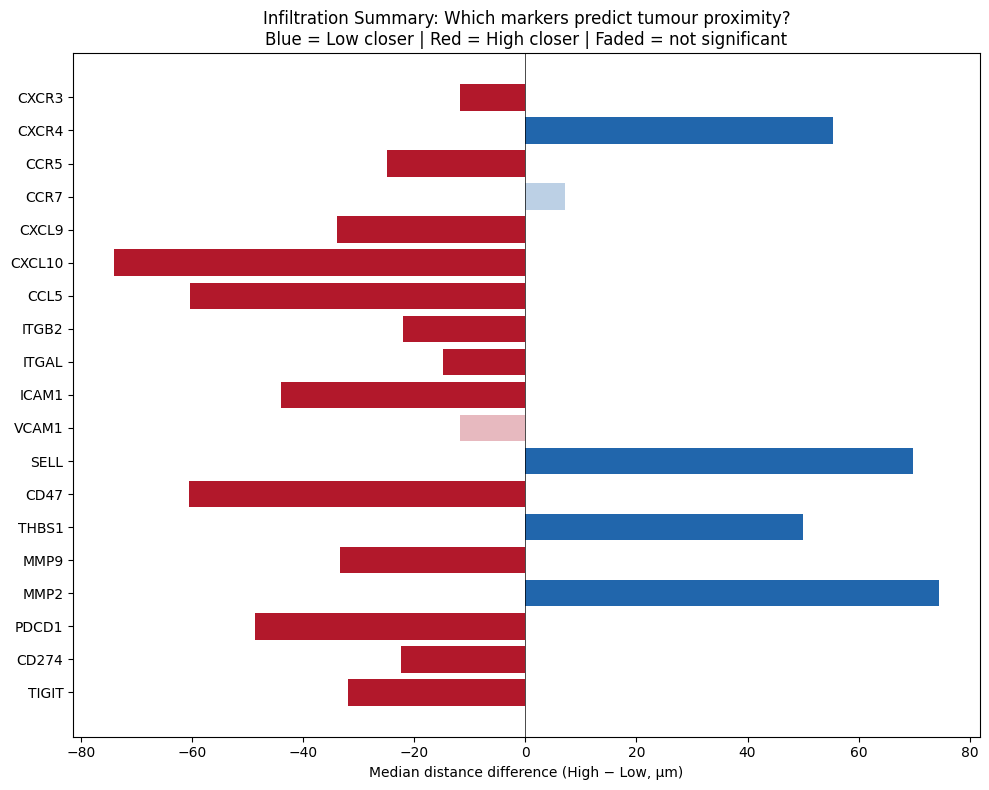


INTERPRETATION

High expression = CLOSER to tumour (activation/proximity markers):
  CXCR3      (Chemokine receptors)
  CCR5       (Chemokine receptors)
  CXCL9      (Chemokines)
  CXCL10     (Chemokines)
  CCL5       (Chemokines)
  ITGB2      (Adhesion molecules)
  ITGAL      (Adhesion molecules)
  ICAM1      (Adhesion molecules)
  CD47       (CD47-TSP1 axis)
  MMP9       (Matrix remodelling)
  PDCD1      (Immune checkpoint)
  CD274      (Immune checkpoint)
  TIGIT      (Immune checkpoint)

Low expression = CLOSER to tumour (potential infiltration barriers):
  CXCR4      (Chemokine receptors)
  SELL       (Adhesion molecules)
  THBS1      (CD47-TSP1 axis)
  MMP2       (Matrix remodelling)

Not significant:
  CCR7       (Chemokine receptors)
  VCAM1      (Adhesion molecules)


In [81]:
# ============================================================
# 11j. Summary: Direction of effect for all markers
# ============================================================
summary_data = []
for m in all_markers:
    group_col = f"{m}_group"
    low = cd8_obs.loc[cd8_obs[group_col] == "Low", "nearest_tumour_dist"].dropna()
    high = cd8_obs.loc[cd8_obs[group_col] == "High", "nearest_tumour_dist"].dropna()
    _, p = mannwhitneyu(low, high, alternative="two-sided")
    diff = high.median() - low.median()  # positive = low closer, negative = high closer
    summary_data.append({"Marker": m, "diff": diff, "p": p})

summary_df = pd.DataFrame(summary_data)
summary_df["significant"] = summary_df["p"] < 0.05

# Find which category each marker belongs to
cat_map = {}
for cat, genes in extended_markers.items():
    for g in genes:
        cat_map[g] = cat
summary_df["Category"] = summary_df["Marker"].map(cat_map)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2166ac" if d > 0 else "#b2182b" for d in summary_df["diff"]]
alphas = [1.0 if s else 0.3 for s in summary_df["significant"]]

bars = ax.barh(range(len(summary_df)), summary_df["diff"], color=colors)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)

ax.set_yticks(range(len(summary_df)))
ax.set_yticklabels(summary_df["Marker"])
ax.set_xlabel("Median distance difference (High − Low, µm)")
ax.set_title("Infiltration Summary: Which markers predict tumour proximity?\nBlue = Low closer | Red = High closer | Faded = not significant")
ax.axvline(0, color="black", linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Print interpretation
print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print("\nHigh expression = CLOSER to tumour (activation/proximity markers):")
for _, row in summary_df[(summary_df["diff"] < 0) & (summary_df["significant"])].iterrows():
    print(f"  {row['Marker']:<10} ({row['Category']})")

print("\nLow expression = CLOSER to tumour (potential infiltration barriers):")
for _, row in summary_df[(summary_df["diff"] > 0) & (summary_df["significant"])].iterrows():
    print(f"  {row['Marker']:<10} ({row['Category']})")

print("\nNot significant:")
for _, row in summary_df[~summary_df["significant"]].iterrows():
    print(f"  {row['Marker']:<10} ({row['Category']})")

In [82]:
# ============================================================
# 11k. Available effector-related genes in dataset (reference)
# ============================================================
# 17/18 genes found — currently using GZMA, GZMB, PRF1, IFNG as per proposal.
# Additional markers available if needed for extended analysis.
# ============================================================
# Check for additional effector function genes
# ============================================================
effector_genes = {
    # Cytotoxic granules
    "GZMA": "Granzyme A (cytotoxic)",
    "GZMB": "Granzyme B (cytotoxic)",
    "GZMK": "Granzyme K (cytotoxic)",
    "GZMH": "Granzyme H (cytotoxic)",
    "PRF1": "Perforin (pore-forming)",
    "GNLY": "Granulysin (antimicrobial)",
    
    # Cytokines
    "IFNG": "Interferon-gamma",
    "TNF": "TNF-alpha",
    "IL2": "Interleukin-2 (proliferation)",
    "IL10": "Interleukin-10 (immunosuppressive)",
    "IL21": "Interleukin-21",
    
    # Activation/proliferation
    "MKI67": "Ki-67 (proliferation)",
    "CD69": "Early activation",
    "FASLG": "Fas ligand (apoptosis induction)",
    "NKG7": "NK granule protein 7",
    
    # Transcription factors
    "TBX21": "T-bet (Th1 differentiation)",
    "EOMES": "Eomesodermin (effector/memory)",
    "TOX": "TOX (exhaustion transcription factor)",
}

print(f"{'Gene':<10} {'Found':<8} {'Role'}")
print("-" * 60)
found = []
for gene, role in effector_genes.items():
    in_data = gene in data.var_names
    status = "Yes" if in_data else "No"
    print(f"{gene:<10} {status:<8} {role}")
    if in_data:
        found.append(gene)

print(f"\nFound {len(found)} / {len(effector_genes)} effector-related genes")

Gene       Found    Role
------------------------------------------------------------
GZMA       Yes      Granzyme A (cytotoxic)
GZMB       Yes      Granzyme B (cytotoxic)
GZMK       Yes      Granzyme K (cytotoxic)
GZMH       Yes      Granzyme H (cytotoxic)
PRF1       Yes      Perforin (pore-forming)
GNLY       Yes      Granulysin (antimicrobial)
IFNG       Yes      Interferon-gamma
TNF        Yes      TNF-alpha
IL2        Yes      Interleukin-2 (proliferation)
IL10       Yes      Interleukin-10 (immunosuppressive)
IL21       No       Interleukin-21
MKI67      Yes      Ki-67 (proliferation)
CD69       Yes      Early activation
FASLG      Yes      Fas ligand (apoptosis induction)
NKG7       Yes      NK granule protein 7
TBX21      Yes      T-bet (Th1 differentiation)
EOMES      Yes      Eomesodermin (effector/memory)
TOX        Yes      TOX (exhaustion transcription factor)

Found 17 / 18 effector-related genes


In [83]:
# ============================================================
# 11l. Effector marker expression in CD8+ T cells
# ============================================================
effector_markers = ["GZMA", "GZMB", "PRF1", "IFNG"]

# Extract expression
eff_idx = [list(data.var_names).index(m) for m in effector_markers]
X_eff = data.X[cd8_mask.values][:, eff_idx]
if hasattr(X_eff, 'toarray'):
    X_eff = X_eff.toarray()

df_eff = pd.DataFrame(X_eff, columns=effector_markers, index=cd8_obs.index)
for m in effector_markers:
    cd8_obs[m] = df_eff[m].values

# Check expression levels
print("Effector marker expression in CD8+ T cells:")
print("-" * 50)
for m in effector_markers:
    expr = cd8_obs[m]
    pct = (expr > 0).mean() * 100
    print(f"{m}: mean={expr.mean():.4f}, median={expr.median():.4f}, % expressing={pct:.1f}%")

# Correlation with exhaustion score
print("\nCorrelation with exhaustion score:")
print("-" * 50)
for m in effector_markers:
    r, p = spearmanr(cd8_obs[m].dropna(), cd8_obs["exhaustion_score"].dropna())
    direction = "↓ negative (expected)" if r < 0 else "↑ positive (unexpected)"
    print(f"{m}: Spearman r={r:.3f}, p={p:.3g} — {direction}")

Effector marker expression in CD8+ T cells:
--------------------------------------------------
GZMA: mean=0.5894, median=0.0000, % expressing=36.6%
GZMB: mean=0.4792, median=0.0000, % expressing=24.2%
PRF1: mean=0.3419, median=0.0000, % expressing=23.8%
IFNG: mean=0.0942, median=0.0000, % expressing=7.2%

Correlation with exhaustion score:
--------------------------------------------------
GZMA: Spearman r=0.142, p=4.94e-39 — ↑ positive (unexpected)
GZMB: Spearman r=0.222, p=5.41e-95 — ↑ positive (unexpected)
PRF1: Spearman r=0.151, p=3.87e-44 — ↑ positive (unexpected)
IFNG: Spearman r=0.099, p=1.13e-19 — ↑ positive (unexpected)


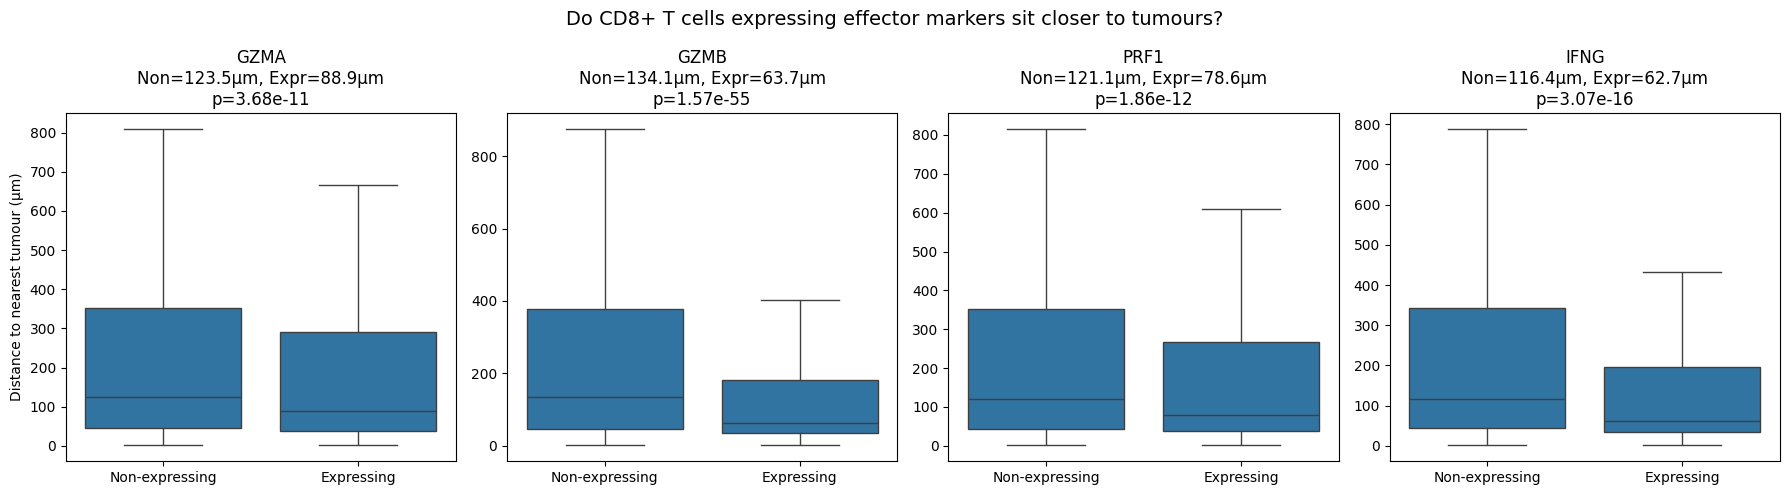

EFFECTOR MARKER PROXIMITY ANALYSIS
GZMA: Non-expressing=123.5µm (n=5,347) vs Expressing=88.9µm (n=3,092), p=3.68e-11 → Expressing closer
GZMB: Non-expressing=134.1µm (n=6,395) vs Expressing=63.7µm (n=2,044), p=1.57e-55 → Expressing closer
PRF1: Non-expressing=121.1µm (n=6,432) vs Expressing=78.6µm (n=2,007), p=1.86e-12 → Expressing closer
IFNG: Non-expressing=116.4µm (n=7,833) vs Expressing=62.7µm (n=606), p=3.07e-16 → Expressing closer

INTERPRETATION:
All four effector markers positively correlate with exhaustion (r = 0.10-0.22).
This reflects co-expression: CD8+ T cells near tumours are in a 'dysfunctional'
state where they upregulate BOTH checkpoint receptors AND effector molecules.
They are attempting to mount an immune response but are simultaneously being
suppressed by the tumour microenvironment.


In [84]:
# ============================================================
# 11m. Effector markers vs tumour proximity
# ============================================================
# Since effector markers positively correlate with exhaustion (co-expression),
# the enhanced score approach needs rethinking. Instead, let's examine:
# Do CD8+ T cells near tumours have HIGHER effector marker expression too?

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, m in enumerate(effector_markers):
    cd8_obs[f"{m}_group"] = np.where(cd8_obs[m] > 0, "Expressing", "Non-expressing")
    
    expr = cd8_obs.loc[cd8_obs[f"{m}_group"] == "Expressing", "nearest_tumour_dist"].dropna()
    non_expr = cd8_obs.loc[cd8_obs[f"{m}_group"] == "Non-expressing", "nearest_tumour_dist"].dropna()
    
    sns.boxplot(data=cd8_obs, x=f"{m}_group", y="nearest_tumour_dist",
                order=["Non-expressing", "Expressing"], showfliers=False, ax=axes[i])
    
    _, p = mannwhitneyu(non_expr, expr, alternative="two-sided")
    axes[i].set_title(f"{m}\nNon={non_expr.median():.1f}µm, Expr={expr.median():.1f}µm\np={p:.3g}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Distance to nearest tumour (µm)" if i == 0 else "")

plt.suptitle("Do CD8+ T cells expressing effector markers sit closer to tumours?", fontsize=14)
plt.tight_layout()
plt.show()

# Summary
print("=" * 70)
print("EFFECTOR MARKER PROXIMITY ANALYSIS")
print("=" * 70)
for m in effector_markers:
    expr = cd8_obs.loc[cd8_obs[f"{m}_group"] == "Expressing", "nearest_tumour_dist"].dropna()
    non_expr = cd8_obs.loc[cd8_obs[f"{m}_group"] == "Non-expressing", "nearest_tumour_dist"].dropna()
    _, p = mannwhitneyu(non_expr, expr, alternative="two-sided")
    direction = "Expressing closer" if expr.median() < non_expr.median() else "Non-expressing closer"
    print(f"{m}: Non-expressing={non_expr.median():.1f}µm (n={len(non_expr):,}) vs "
          f"Expressing={expr.median():.1f}µm (n={len(expr):,}), p={p:.3g} → {direction}")

print("\nINTERPRETATION:")
print("All four effector markers positively correlate with exhaustion (r = 0.10-0.22).")
print("This reflects co-expression: CD8+ T cells near tumours are in a 'dysfunctional'")
print("state where they upregulate BOTH checkpoint receptors AND effector molecules.")
print("They are attempting to mount an immune response but are simultaneously being")
print("suppressed by the tumour microenvironment.")

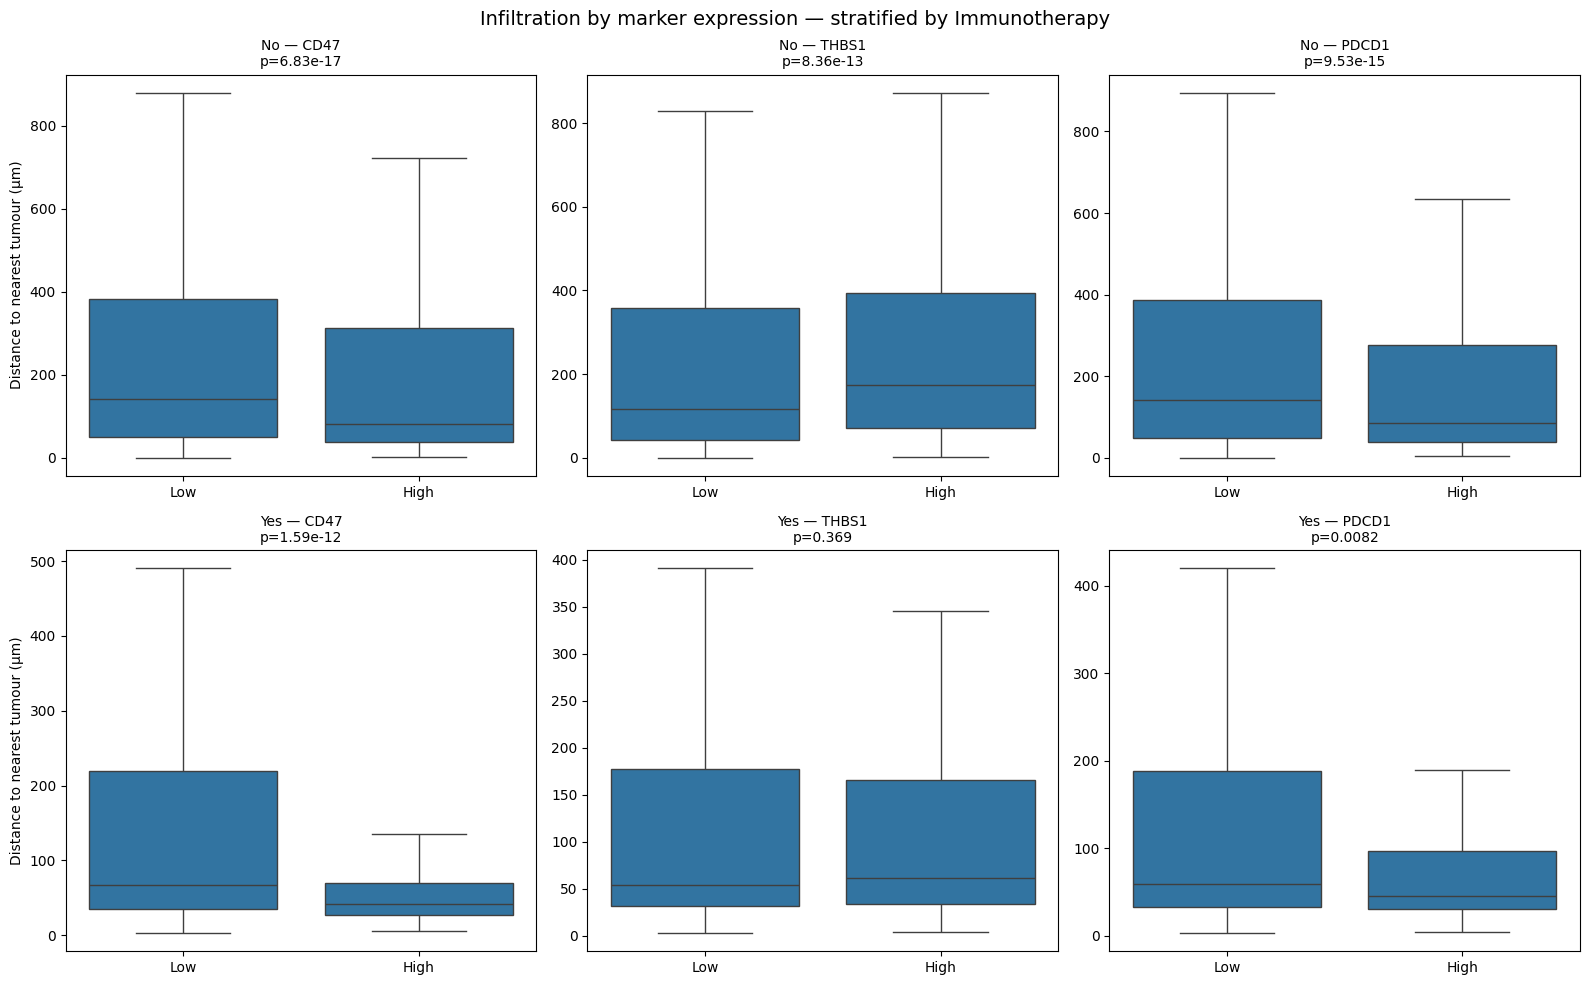


INFILTRATION BY IMMUNOTHERAPY

No (n=6,732):
  CD47: Low=142.7µm (n=5,114) vs High=81.2µm (n=1,618), p=6.83e-17
  THBS1: Low=117.1µm (n=5,468) vs High=173.1µm (n=1,264), p=8.36e-13
  PDCD1: Low=142.1µm (n=5,349) vs High=85.6µm (n=1,383), p=9.53e-15

Yes (n=1,178):
  CD47: Low=67.2µm (n=851) vs High=41.6µm (n=327), p=1.59e-12
  THBS1: Low=54.4µm (n=987) vs High=61.1µm (n=191), p=0.369
  PDCD1: Low=59.5µm (n=919) vs High=45.2µm (n=259), p=0.0082


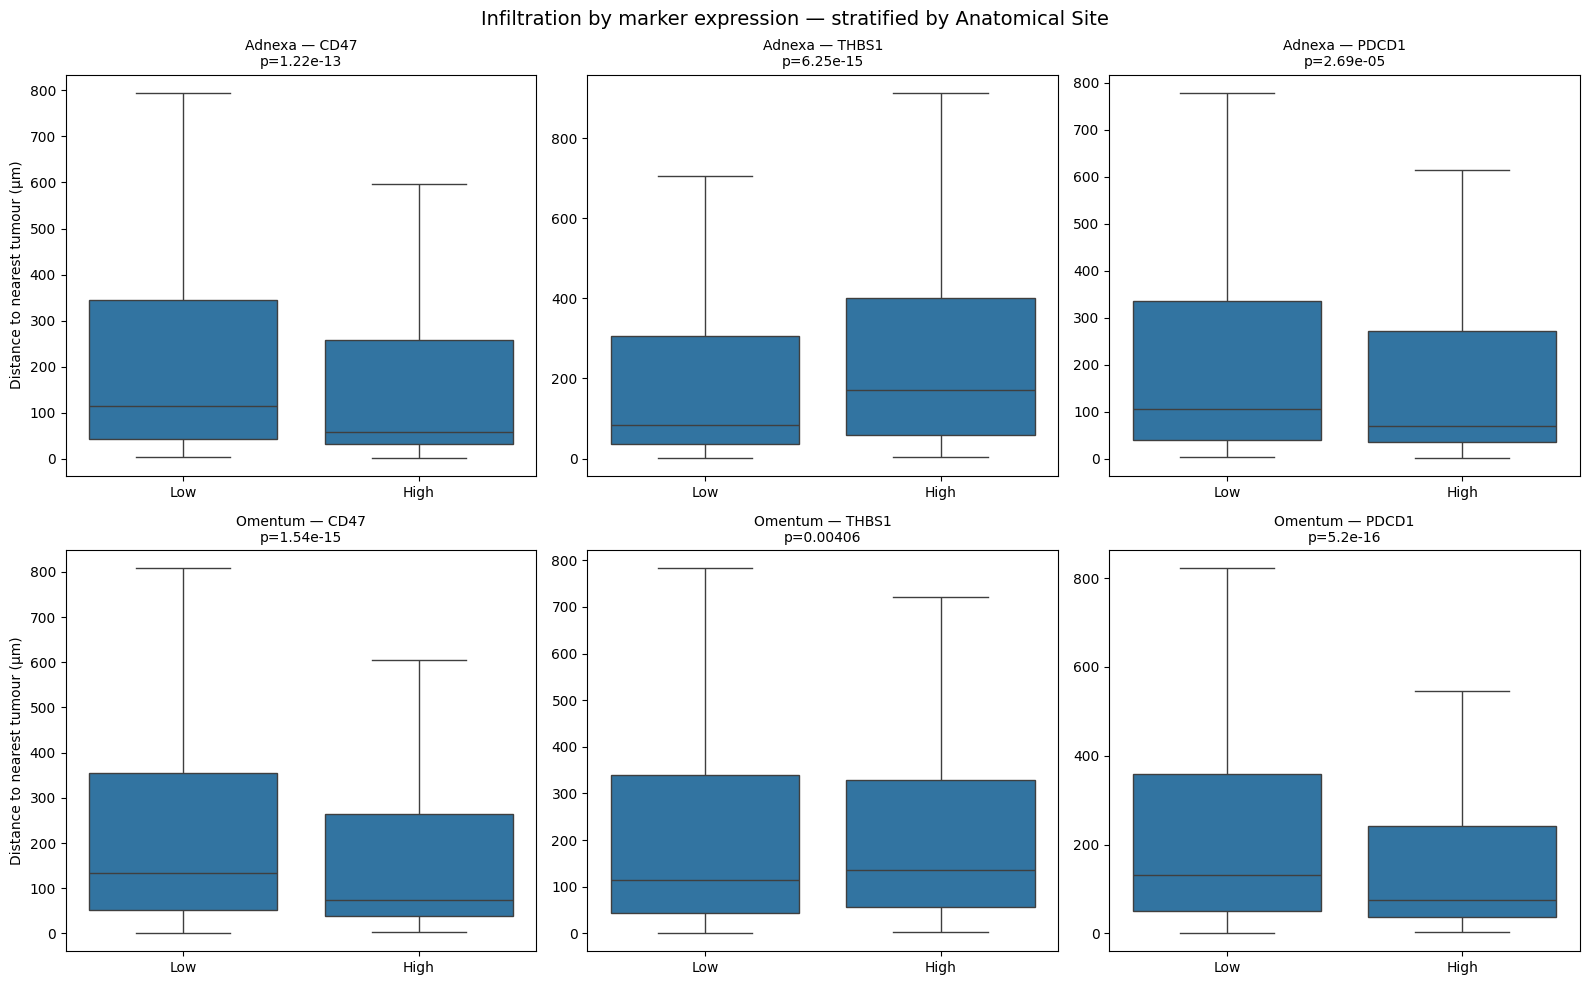


INFILTRATION BY ANATOMICAL SITE

Adnexa (n=3,746):
  CD47: Low=114.8µm (n=2,776) vs High=57.7µm (n=970), p=1.22e-13
  THBS1: Low=82.5µm (n=3,105) vs High=171.5µm (n=641), p=6.25e-15
  PDCD1: Low=104.7µm (n=3,020) vs High=69.5µm (n=726), p=2.69e-05

Omentum (n=4,693):
  CD47: Low=133.2µm (n=3,588) vs High=74.3µm (n=1,105), p=1.54e-15
  THBS1: Low=113.5µm (n=3,801) vs High=135.4µm (n=892), p=0.00406
  PDCD1: Low=132.7µm (n=3,686) vs High=76.3µm (n=1,007), p=5.2e-16


In [85]:
# ============================================================
# 11n. Infiltration analysis stratified by Immunotherapy and Site
# ============================================================
for clinical_col, clinical_groups, label in [
    ("immunotherapy_clean", ["No", "Yes"], "Immunotherapy"),
    ("site_clean", ["Adnexa", "Omentum"], "Anatomical Site")
]:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    for row, grp in enumerate(clinical_groups):
        subset = cd8_obs[cd8_obs[clinical_col] == grp]
        
        for col, m in enumerate(infiltration_markers):
            group_col = f"{m}_group"
            
            sns.boxplot(data=subset, x=group_col, y="nearest_tumour_dist",
                        order=["Low", "High"], showfliers=False, ax=axes[row, col])
            
            low = subset.loc[subset[group_col] == "Low", "nearest_tumour_dist"].dropna()
            high = subset.loc[subset[group_col] == "High", "nearest_tumour_dist"].dropna()
            
            if len(low) > 0 and len(high) > 0:
                _, p = mannwhitneyu(low, high, alternative="two-sided")
                axes[row, col].set_title(f"{grp} — {m}\np={p:.3g}", fontsize=10)
            else:
                axes[row, col].set_title(f"{grp} — {m}", fontsize=10)
            
            axes[row, col].set_xlabel("")
            axes[row, col].set_ylabel("Distance to nearest tumour (µm)" if col == 0 else "")
    
    plt.suptitle(f"Infiltration by marker expression — stratified by {label}", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Summary
    print(f"\n{'='*70}")
    print(f"INFILTRATION BY {label.upper()}")
    print(f"{'='*70}")
    for grp in clinical_groups:
        subset = cd8_obs[cd8_obs[clinical_col] == grp]
        print(f"\n{grp} (n={len(subset):,}):")
        for m in infiltration_markers:
            group_col = f"{m}_group"
            low = subset.loc[subset[group_col] == "Low", "nearest_tumour_dist"].dropna()
            high = subset.loc[subset[group_col] == "High", "nearest_tumour_dist"].dropna()
            if len(low) > 0 and len(high) > 0:
                _, p = mannwhitneyu(low, high, alternative="two-sided")
                print(f"  {m}: Low={low.median():.1f}µm (n={len(low):,}) vs "
                      f"High={high.median():.1f}µm (n={len(high):,}), p={p:.3g}")

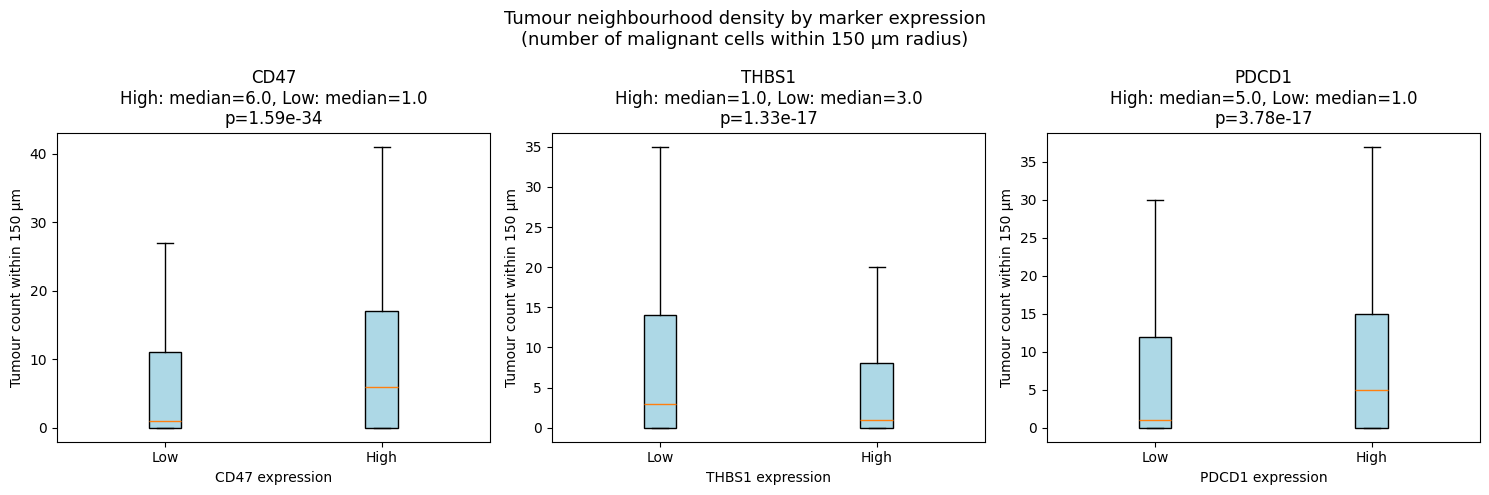

TUMOUR COUNT WITHIN 150 µm: High vs Low expression
CD47: High median=6.0, Low median=1.0, p=1.59e-34
THBS1: High median=1.0, Low median=3.0, p=1.33e-17
PDCD1: High median=5.0, Low median=1.0, p=3.78e-17


In [86]:
# ============================================================
# 13g. Infiltration by tumour count (not just distance)
# ============================================================
# Supervisor Comment 19: "Rather than looking at the distance with one 
# cell only, it would be interesting to plot the number of malignant 
# cells within a given radius (this would capture better the environment)"
#
# For each of the key infiltration markers, compare tumour count 
# in the neighbourhood between High and Low expression groups.
# ============================================================

key_markers = ["CD47", "THBS1", "PDCD1"]
tumour_col = f"tumour_count_r{RADIUS}"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, marker in enumerate(key_markers):
    ax = axes[i]
    
    # Split into High/Low expression (median split)
    med = cd8_obs[marker].median()
    cd8_obs[f"{marker}_group"] = np.where(cd8_obs[marker] > med, "High", "Low")
    
    # Get data for each group
    high = cd8_obs[cd8_obs[f"{marker}_group"] == "High"][tumour_col].dropna()
    low = cd8_obs[cd8_obs[f"{marker}_group"] == "Low"][tumour_col].dropna()
    
    # Boxplot
    ax.boxplot([low, high], labels=["Low", "High"], 
               showfliers=False, patch_artist=True,
               boxprops=dict(facecolor="lightblue"))
    
    # Stats
    stat, p = mannwhitneyu(high, low)
    ax.set_title(f"{marker}\nHigh: median={high.median():.1f}, Low: median={low.median():.1f}\np={p:.2e}")
    ax.set_ylabel(f"Tumour count within {RADIUS} µm")
    ax.set_xlabel(f"{marker} expression")

plt.suptitle(f"Tumour neighbourhood density by marker expression\n(number of malignant cells within {RADIUS} µm radius)", 
             fontsize=13)
plt.tight_layout()
plt.show()

# Print summary
print("=" * 60)
print(f"TUMOUR COUNT WITHIN {RADIUS} µm: High vs Low expression")
print("=" * 60)
for marker in key_markers:
    high = cd8_obs[cd8_obs[f"{marker}_group"] == "High"][tumour_col].dropna()
    low = cd8_obs[cd8_obs[f"{marker}_group"] == "Low"][tumour_col].dropna()
    stat, p = mannwhitneyu(high, low)
    print(f"{marker}: High median={high.median():.1f}, Low median={low.median():.1f}, p={p:.2e}")

---
### 12. Infiltration Index

Combines neighbourhood density (tumour fraction from KNN) and proximity (nearest tumour distance)  
into a single unified metric per CD8+ T cell.

**Formula:**

    Infiltration_Index(i) = α × T_i + β × (1 − D_i / D_max)

Where:
- T_i = local tumour fraction from KNN (k=20) for cell i
- D_i = nearest tumour distance for cell i (µm)
- D_max = maximum observed nearest distance = 3,335 µm
- α = β = 0.5 (equal weighting of density and proximity components)

**Index range:** 0 (low infiltration: far from tumour, few tumour neighbours) → 1 (high infiltration: close to tumour, surrounded by tumour cells)

The (1 − D_i / D_max) term converts distance (where smaller = more infiltrated) into a  
0→1 infiltration scale (where larger = more infiltrated), making it additive with T_i.


In [87]:
# ============================================================
# 14. Infiltration Index
# ============================================================
# Combines two spatial measures into one score per T cell:
#   T_i = local tumour fraction (from KNN)
#   D_i = nearest tumour distance
#   D_max = maximum distance in dataset
#
# Formula: Infiltration_Index = alpha * T_i + beta * (1 - D_i / D_max)
#   - T_i captures: is this T cell SURROUNDED by tumour?
#   - (1 - D_i/D_max) captures: is this T cell CLOSE to tumour?
#   - alpha and beta control how much each part contributes
#   - Higher index = more infiltrated
# ============================================================

# --- Parameters ---
alpha = 0.5  # weight for tumour fraction (neighbourhood density)
beta = 0.5   # weight for proximity (distance-based)

# --- Get the two ingredients ---
T_i = cd8_obs[f"tumour_frac_knn_{K}"].copy()  # tumour fraction from KNN
D_i = cd8_obs["nearest_tumour_dist"].copy()    # nearest tumour distance
D_max = D_i.max()                               # maximum distance in dataset

print(f"D_max (furthest T cell from any tumour): {D_max:.1f} µm")
print(f"Alpha (weight for tumour fraction): {alpha}")
print(f"Beta (weight for proximity): {beta}")
print()

# --- Calculate the Infiltration Index ---
proximity = 1 - (D_i / D_max)  # flip so closer = higher
cd8_obs["infiltration_index"] = alpha * T_i + beta * proximity

# --- Summary ---
idx = cd8_obs["infiltration_index"].dropna()
print(f"Infiltration Index summary:")
print(f"  Valid cells: {len(idx):,} / {len(cd8_obs):,}")
print(f"  Min:    {idx.min():.4f}")
print(f"  Median: {idx.median():.4f}")
print(f"  Mean:   {idx.mean():.4f}")
print(f"  Max:    {idx.max():.4f}")
print()
print("Interpretation:")
print("  Score close to 1.0 = high infiltration (close to tumour + surrounded by tumour)")
print("  Score close to 0.0 = low infiltration (far from tumour + few tumour neighbours)")


D_max (furthest T cell from any tumour): 3334.9 µm
Alpha (weight for tumour fraction): 0.5
Beta (weight for proximity): 0.5

Infiltration Index summary:
  Valid cells: 8,439 / 8,439
  Min:    0.0000
  Median: 0.5563
  Mean:   0.6128
  Max:    0.9994

Interpretation:
  Score close to 1.0 = high infiltration (close to tumour + surrounded by tumour)
  Score close to 0.0 = low infiltration (far from tumour + few tumour neighbours)


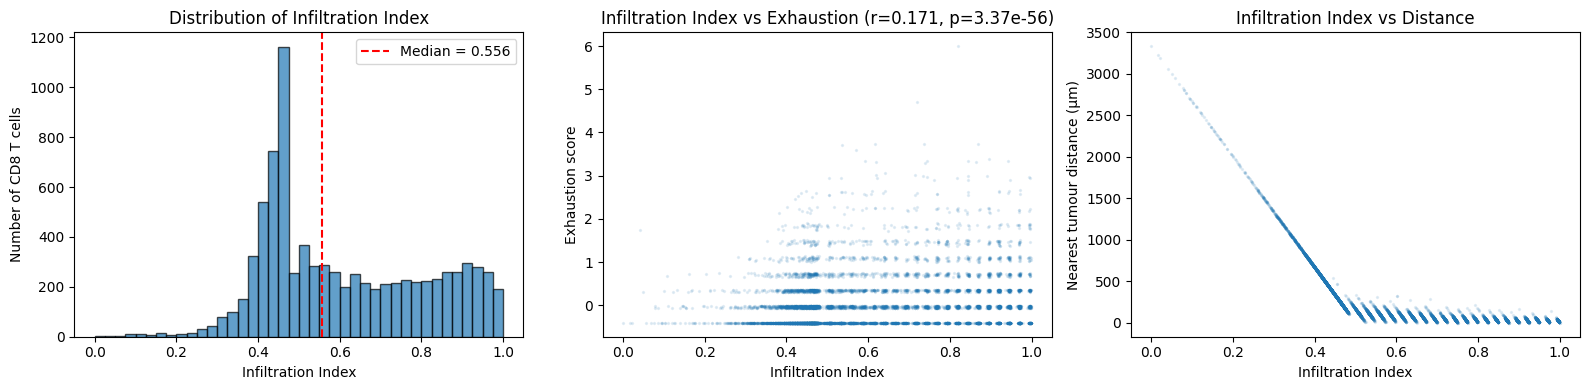

In [88]:
# ============================================================
# 14b. Infiltration Index Distribution
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Distribution of the index
axes[0].hist(cd8_obs["infiltration_index"].dropna(), bins=40, edgecolor="black", alpha=0.7)
axes[0].axvline(cd8_obs["infiltration_index"].median(), color="red", linestyle="--",
                label=f"Median = {cd8_obs['infiltration_index'].median():.3f}")
axes[0].set_xlabel("Infiltration Index")
axes[0].set_ylabel("Number of CD8 T cells")
axes[0].set_title("Distribution of Infiltration Index")
axes[0].legend()

# 2) Index vs exhaustion score
axes[1].scatter(cd8_obs["infiltration_index"], cd8_obs["exhaustion_score"],
                s=2, alpha=0.1)
r, p = spearmanr(cd8_obs["infiltration_index"].dropna(),
                 cd8_obs.loc[cd8_obs["infiltration_index"].notna(), "exhaustion_score"])
axes[1].set_xlabel("Infiltration Index")
axes[1].set_ylabel("Exhaustion score")
axes[1].set_title(f"Infiltration Index vs Exhaustion (r={r:.3f}, p={p:.2e})")

# 3) Index vs nearest tumour distance
axes[2].scatter(cd8_obs["infiltration_index"], cd8_obs["nearest_tumour_dist"],
                s=2, alpha=0.1)
axes[2].set_xlabel("Infiltration Index")
axes[2].set_ylabel("Nearest tumour distance (µm)")
axes[2].set_title("Infiltration Index vs Distance")

plt.tight_layout()
plt.show()


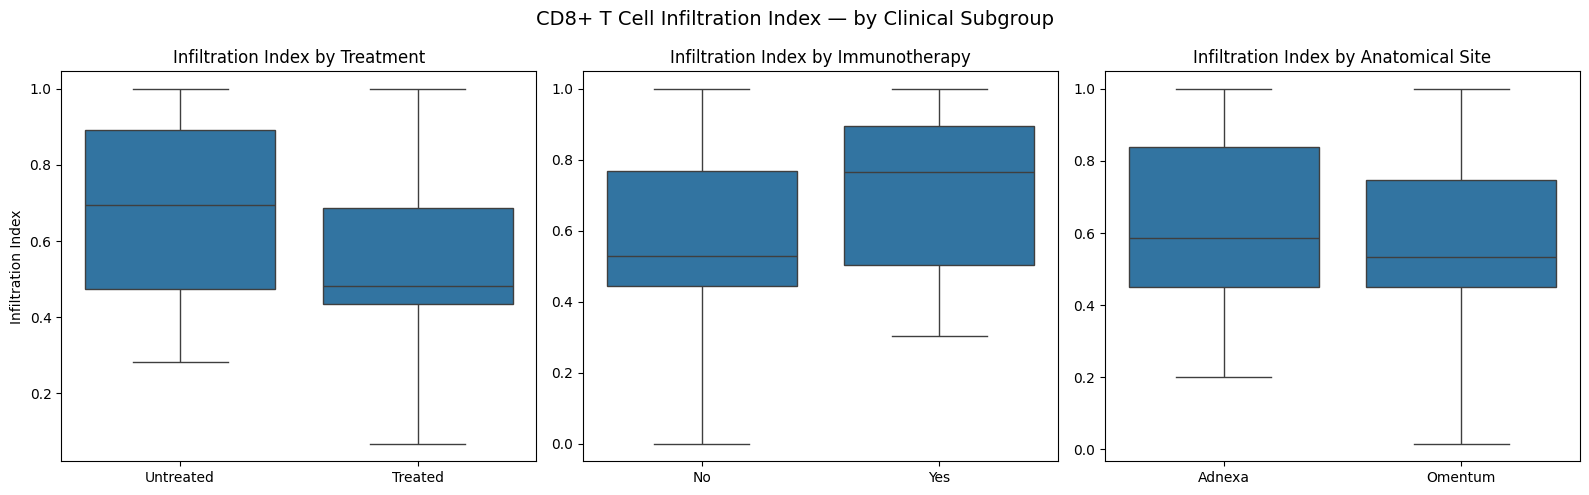

treatment_clean: Untreated median=0.6950 vs Treated median=0.4812, p=8.4e-179
immunotherapy_clean: No median=0.5289 vs Yes median=0.7642, p=2.05e-61
site_clean: Adnexa median=0.5873 vs Omentum median=0.5348, p=1.31e-10


In [93]:
# ============================================================
# 14c. Infiltration Index by Clinical Subgroup
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Treatment
sns.boxplot(data=cd8_obs, x="treatment_clean", y="infiltration_index",
            order=["Untreated", "Treated"], showfliers=False, ax=axes[0])
axes[0].set_title("Infiltration Index by Treatment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Infiltration Index")

# Immunotherapy
sns.boxplot(data=cd8_obs, x="immunotherapy_clean", y="infiltration_index",
            order=["No", "Yes"], showfliers=False, ax=axes[1])
axes[1].set_title("Infiltration Index by Immunotherapy")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# Site
sns.boxplot(data=cd8_obs, x="site_clean", y="infiltration_index",
            order=["Adnexa", "Omentum"], showfliers=False, ax=axes[2])
axes[2].set_title("Infiltration Index by Anatomical Site")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

plt.suptitle("CD8+ T Cell Infiltration Index — by Clinical Subgroup", fontsize=14)
plt.tight_layout()
plt.show()

# P-values
for col, groups in [("treatment_clean", ["Untreated", "Treated"]),
                    ("immunotherapy_clean", ["No", "Yes"]),
                    ("site_clean", ["Adnexa", "Omentum"])]:
    g1 = cd8_obs.loc[cd8_obs[col] == groups[0], "infiltration_index"].dropna()
    g2 = cd8_obs.loc[cd8_obs[col] == groups[1], "infiltration_index"].dropna()
    _, p = mannwhitneyu(g1, g2, alternative="two-sided")
    print(f"{col}: {groups[0]} median={g1.median():.4f} vs {groups[1]} median={g2.median():.4f}, p={p:.3g}")


---
### 15. UMAP Visualisation of CD8+ T Cells

UMAP (Uniform Manifold Approximation and Projection) reduces the 979-gene expression space  
to 2 dimensions. Cells with similar transcriptomic profiles appear close together.

**Pipeline:** normalise expression → select top 500 highly variable genes →  
compute 30 principal components → build nearest-neighbour graph → project to 2D via UMAP.

Coloured by: exhaustion score, CD47, THBS1, PDCD1, treatment status, tumour neighbourhood, immunotherapy.


In [99]:
# ============================================================
# 15a. Compute UMAP for CD8+ T cells
# ============================================================
# Create a subset AnnData object for just CD8+ T cells
sc = __import__('scanpy')
adata_cd8 = data[cd8_mask].copy()

# Add our computed columns to adata_cd8.obs
for col in ["exhaustion_score", "nearest_tumour_dist", "infiltration_index",
            "tumour_neighbourhood", "treatment_clean", "immunotherapy_clean", "site_clean"]:
    if col in cd8_obs.columns:
        adata_cd8.obs[col] = cd8_obs[col].values

# Add CD47, THBS1, PDCD1 expression (renamed to avoid clash with var_names)
for gene in ["CD47", "THBS1", "PDCD1"]:
    idx = list(data.var_names).index(gene)
    vals = adata_cd8.X[:, idx]
    if hasattr(vals, "toarray"):
        vals = vals.toarray()
    adata_cd8.obs[f"{gene}_expr"] = vals.flatten()

# Standard preprocessing for UMAP
sc.pp.normalize_total(adata_cd8, target_sum=1e4)
sc.pp.log1p(adata_cd8)
sc.pp.highly_variable_genes(adata_cd8, n_top_genes=500)
sc.pp.pca(adata_cd8, n_comps=30)
sc.pp.neighbors(adata_cd8, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_cd8)

print(f"UMAP computed for {adata_cd8.n_obs:,} CD8+ T cells")
print(f"Using top 500 highly variable genes, 30 PCs")

UMAP computed for 8,439 CD8+ T cells
Using top 500 highly variable genes, 30 PCs


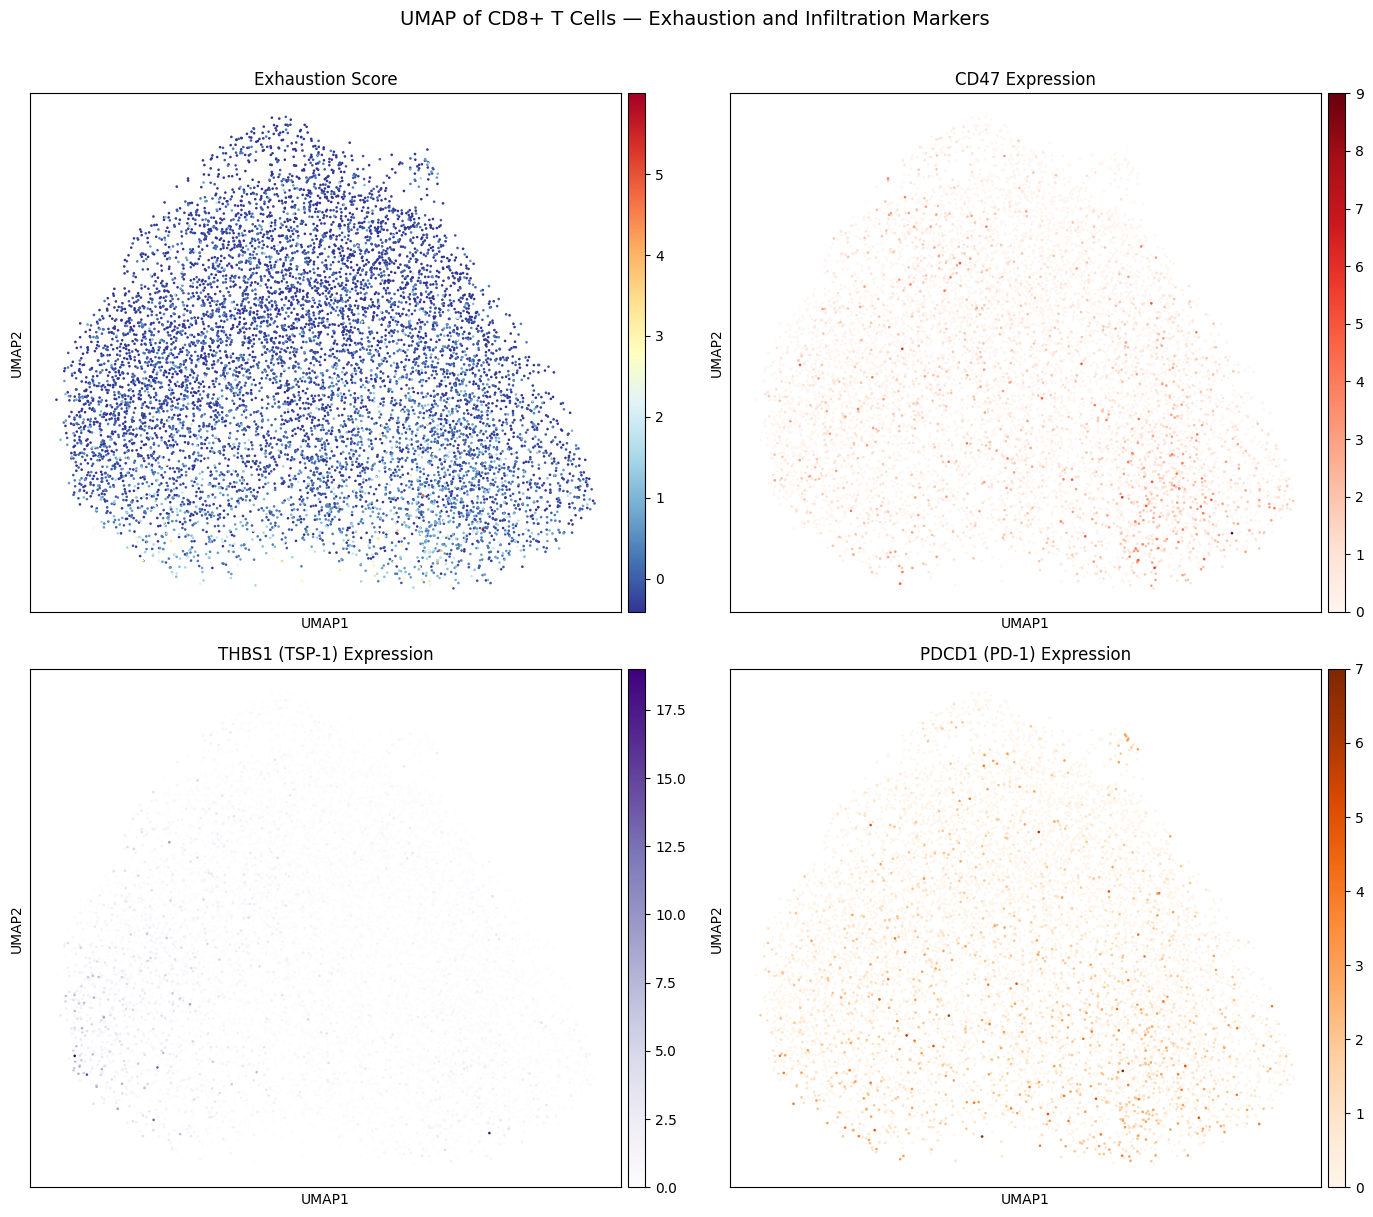

In [100]:
# ============================================================
# 15b. UMAP coloured by exhaustion score and key markers
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1) Exhaustion score
sc.pl.umap(adata_cd8, color="exhaustion_score", cmap="RdYlBu_r",
           title="Exhaustion Score", show=False, ax=axes[0, 0])

# 2) CD47 expression
sc.pl.umap(adata_cd8, color="CD47_expr", cmap="Reds",
           title="CD47 Expression", show=False, ax=axes[0, 1])

# 3) THBS1 expression
sc.pl.umap(adata_cd8, color="THBS1_expr", cmap="Purples",
           title="THBS1 (TSP-1) Expression", show=False, ax=axes[1, 0])

# 4) PDCD1 expression
sc.pl.umap(adata_cd8, color="PDCD1_expr", cmap="Oranges",
           title="PDCD1 (PD-1) Expression", show=False, ax=axes[1, 1])

plt.suptitle("UMAP of CD8+ T Cells — Exhaustion and Infiltration Markers", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

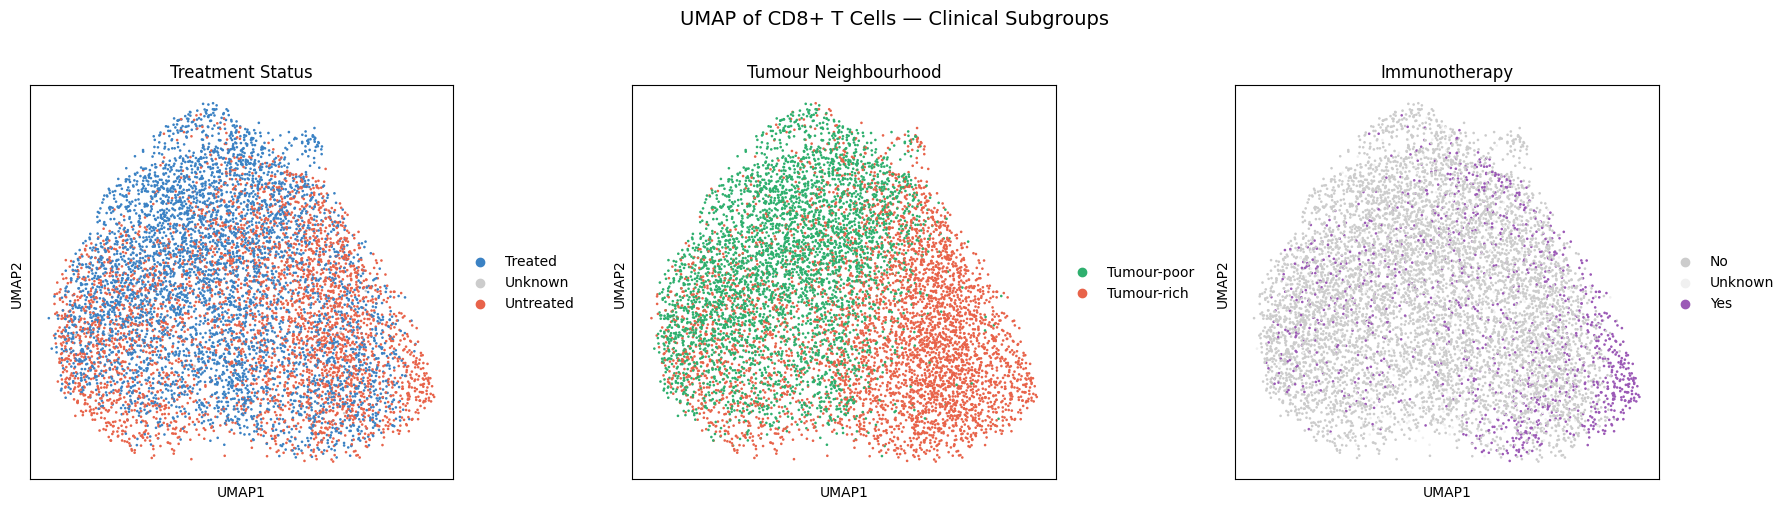

In [101]:
# ============================================================
# 15c. UMAP coloured by clinical groups
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Treatment
sc.pl.umap(adata_cd8, color="treatment_clean",
           palette={"Treated": "#3B82C4", "Untreated": "#E8634A", "Unknown": "#CCCCCC"},
           title="Treatment Status", show=False, ax=axes[0])

# 2) Tumour neighbourhood
sc.pl.umap(adata_cd8, color="tumour_neighbourhood",
           palette={"Tumour-rich": "#E8634A", "Tumour-poor": "#2EAF6E"},
           title="Tumour Neighbourhood", show=False, ax=axes[1])

# 3) Immunotherapy
sc.pl.umap(adata_cd8, color="immunotherapy_clean",
           palette={"Yes": "#9B59B6", "No": "#CCCCCC", "Unknown": "#F0F0F0"},
           title="Immunotherapy", show=False, ax=axes[2])

plt.suptitle("UMAP of CD8+ T Cells — Clinical Subgroups", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---
### 16. Weng et al. (2025) Style Plots

Replicating key analytical approaches from:  
**Weng et al. (2025) — "Thrombospondin-1–CD47 signalling contributes to the development of T cell exhaustion in cancer", Nature Immunology**

The paper identified the TSP-1–CD47 axis as a driver of T cell exhaustion via calcineurin–NFAT signalling.  
Our plots provide independent spatial transcriptomics validation of this pathway in ovarian cancer.

Plots include:
- Heatmap: exhaustion + infiltration markers by treatment × neighbourhood group
- CD47-Hi vs CD47-Lo exhaustion marker comparison (bar charts with SE)
- Co-expression scatter plots: CD47/THBS1 vs exhaustion score
- Heatmap: CD47-Hi vs CD47-Lo across treatment groups


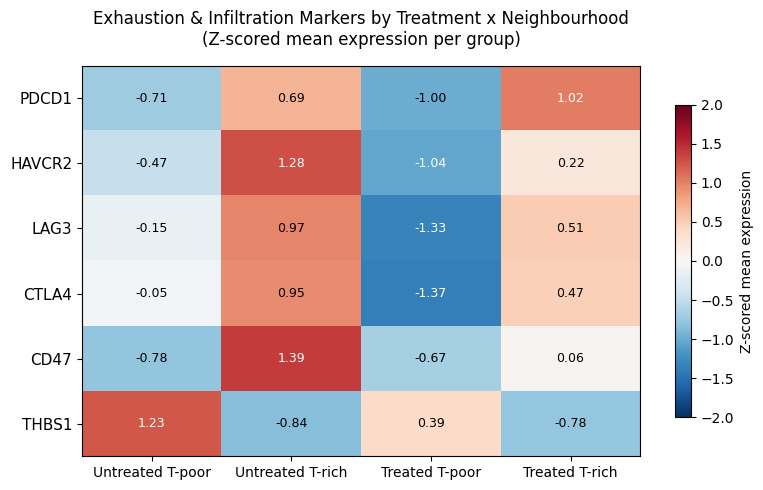

In [102]:
# ============================================================
# 16a. Heatmap: Marker expression across groups
# ============================================================
# Similar to Weng et al. Fig 4e — heatmap showing how exhaustion
# and infiltration markers change across different conditions
# ============================================================

# Define the markers to show
heatmap_genes = ["PDCD1", "HAVCR2", "LAG3", "CTLA4", "CD47", "THBS1"]

# Define groups to compare
groups = {
    "Untreated T-poor": cd8_obs[(cd8_obs["treatment_clean"] == "Untreated") & (cd8_obs["tumour_neighbourhood"] == "Tumour-poor")],
    "Untreated T-rich": cd8_obs[(cd8_obs["treatment_clean"] == "Untreated") & (cd8_obs["tumour_neighbourhood"] == "Tumour-rich")],
    "Treated T-poor": cd8_obs[(cd8_obs["treatment_clean"] == "Treated") & (cd8_obs["tumour_neighbourhood"] == "Tumour-poor")],
    "Treated T-rich": cd8_obs[(cd8_obs["treatment_clean"] == "Treated") & (cd8_obs["tumour_neighbourhood"] == "Tumour-rich")],
}

# Build the heatmap data: mean expression per group per gene
heatmap_data = pd.DataFrame(index=heatmap_genes, columns=groups.keys(), dtype=float)

for grp_name, grp_df in groups.items():
    for gene in heatmap_genes:
        if gene in grp_df.columns:
            heatmap_data.loc[gene, grp_name] = grp_df[gene].mean()
        else:
            # Extract from data matrix
            idx = list(data.var_names).index(gene)
            cell_idx = grp_df.index
            vals = data[cell_idx].X[:, idx]
            if hasattr(vals, "toarray"):
                vals = vals.toarray()
            heatmap_data.loc[gene, grp_name] = vals.mean()

heatmap_data = heatmap_data.astype(float)

# Z-score each row (gene) for better colour contrast
heatmap_z = heatmap_data.subtract(heatmap_data.mean(axis=1), axis=0).divide(heatmap_data.std(axis=1), axis=0)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_z.values, cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2)

# Labels
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=10)
ax.set_yticks(range(len(heatmap_genes)))
ax.set_yticklabels(heatmap_genes, fontsize=11)

# Add values in cells
for i in range(len(heatmap_genes)):
    for j in range(len(groups)):
        val = heatmap_z.values[i, j]
        color = "white" if abs(val) > 1 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)

plt.colorbar(im, ax=ax, label="Z-scored mean expression", shrink=0.8)
ax.set_title("Exhaustion & Infiltration Markers by Treatment x Neighbourhood\n(Z-scored mean expression per group)", fontsize=12, pad=15)
plt.tight_layout()
plt.show()


CD47-Hi: 2,075 cells | CD47-Lo: 6,364 cells


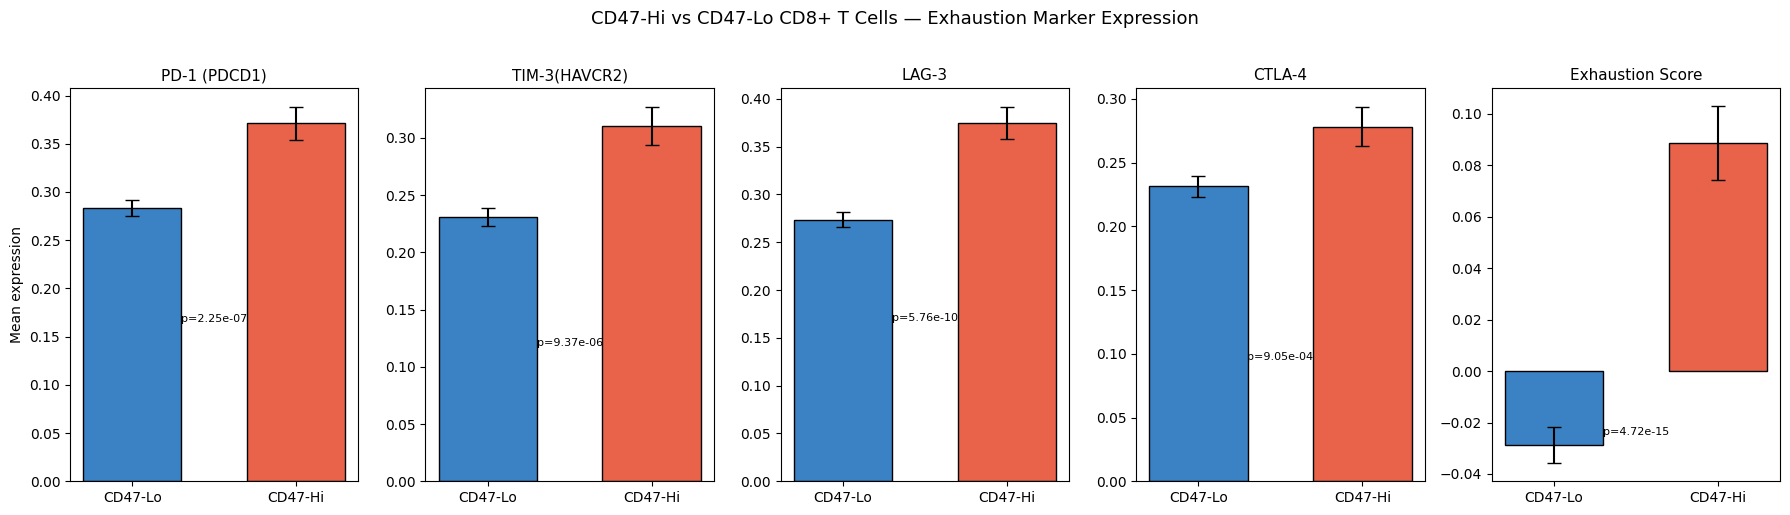

In [103]:
# ============================================================
# 16b. CD47-Hi vs CD47-Lo: Exhaustion marker comparison
# ============================================================
# Similar to Weng et al. Fig 1b — comparing marker expression
# between CD47-high and CD47-low T cells
# ============================================================

# Split CD8 T cells into CD47-Hi and CD47-Lo
cd47_col = "CD47"
if cd47_col not in cd8_obs.columns:
    idx = list(data.var_names).index("CD47")
    vals = data.X[cd8_mask.values][:, idx]
    if hasattr(vals, "toarray"):
        vals = vals.toarray()
    cd8_obs["CD47"] = vals.flatten()

# Split by median (or >0 if zero-inflated)
if cd8_obs["CD47"].median() == 0:
    cd8_obs["CD47_group"] = np.where(cd8_obs["CD47"] > 0, "CD47-Hi", "CD47-Lo")
else:
    med = cd8_obs["CD47"].median()
    cd8_obs["CD47_group"] = np.where(cd8_obs["CD47"] >= med, "CD47-Hi", "CD47-Lo")

n_hi = (cd8_obs["CD47_group"] == "CD47-Hi").sum()
n_lo = (cd8_obs["CD47_group"] == "CD47-Lo").sum()
print(f"CD47-Hi: {n_hi:,} cells | CD47-Lo: {n_lo:,} cells")

# Compare exhaustion markers + score between CD47-Hi and CD47-Lo
compare_markers = ["PDCD1", "HAVCR2", "LAG3", "CTLA4", "exhaustion_score"]
marker_labels = [
    "PD-1 (PDCD1)", "TIM-3(HAVCR2)", "LAG-3", "CTLA-4", "Exhaustion Score"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, (marker, label) in enumerate(zip(compare_markers, marker_labels)):
    hi_vals = cd8_obs.loc[cd8_obs["CD47_group"] == "CD47-Hi", marker].dropna()
    lo_vals = cd8_obs.loc[cd8_obs["CD47_group"] == "CD47-Lo", marker].dropna()
    _, p = mannwhitneyu(hi_vals, lo_vals, alternative="two-sided")
    
    # Bar plot with error bars
    means = [lo_vals.mean(), hi_vals.mean()]
    sems = [lo_vals.sem(), hi_vals.sem()]
    bars = axes[i].bar(["CD47-Lo", "CD47-Hi"], means, yerr=sems,
                       color=["#3B82C4", "#E8634A"], edgecolor="black",
                       capsize=5, width=0.6)
    
    # Add p-value
    y_max = max(means) + max(sems) * 2
    axes[i].text(0.5, y_max, f"p={p:.2e}", ha="center", fontsize=8, transform=axes[i].get_xaxis_transform())
    
    axes[i].set_title(label, fontsize=11)
    axes[i].set_ylabel("Mean expression" if i == 0 else "")
    axes[i].tick_params(axis="x", labelsize=10)

plt.suptitle("CD47-Hi vs CD47-Lo CD8+ T Cells — Exhaustion Marker Expression", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


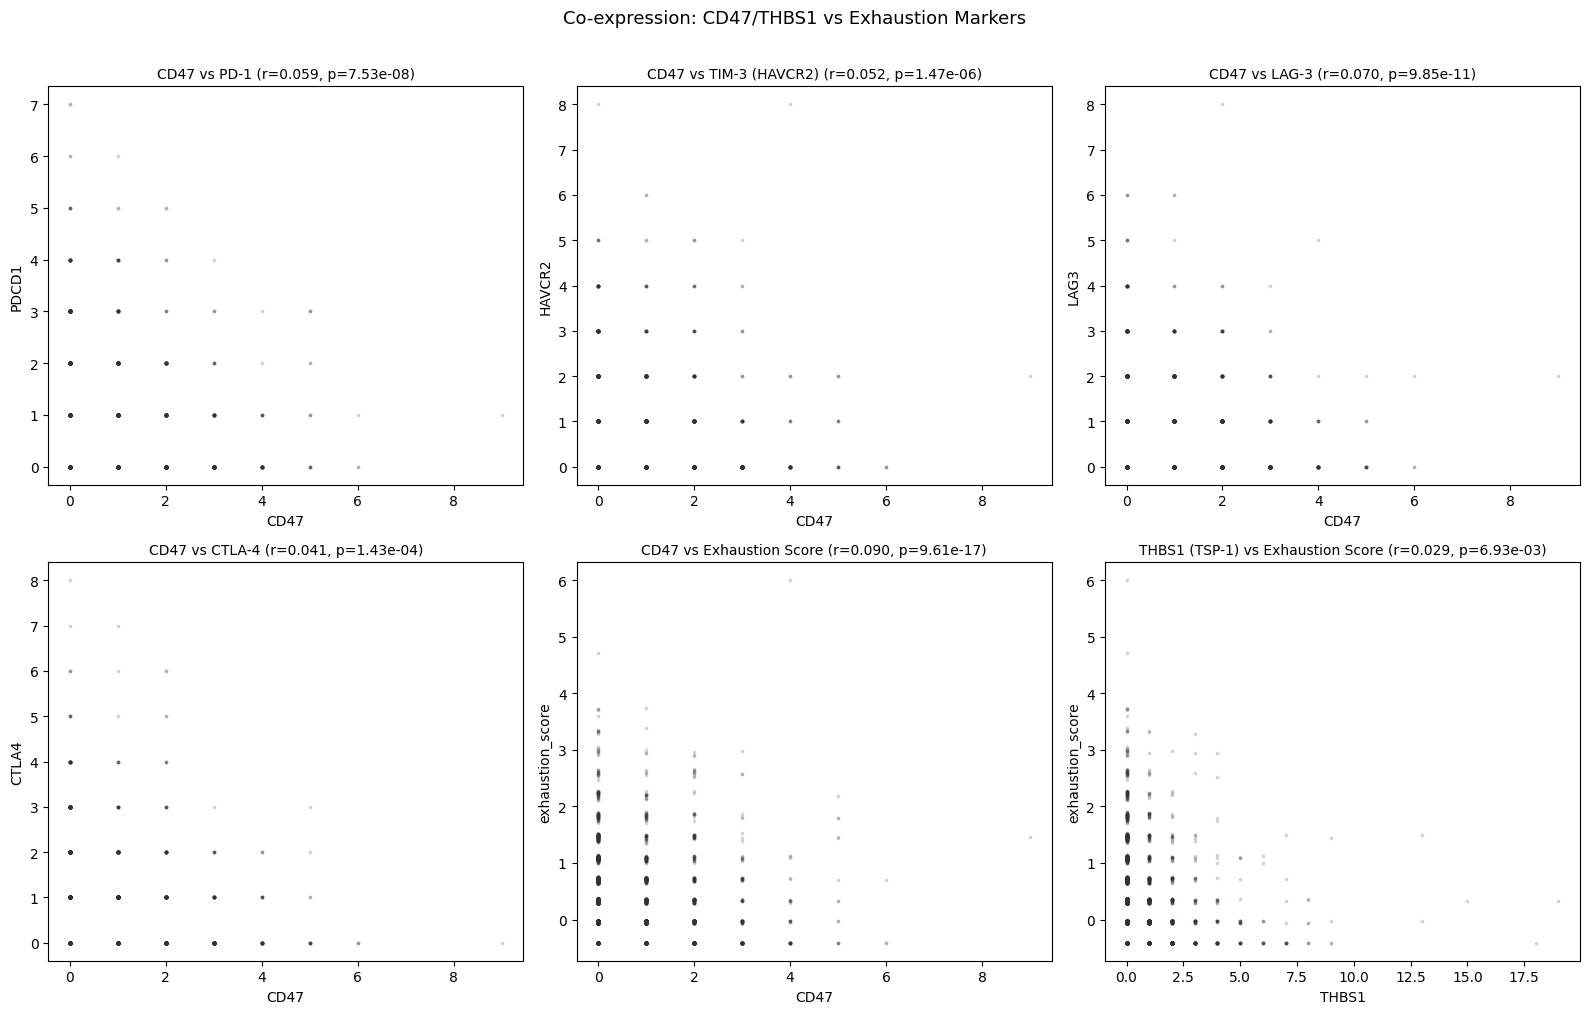

In [104]:
# ============================================================
# 16c. Scatter plots: CD47 vs exhaustion markers
# ============================================================
# Similar to Weng et al. Fig 1a/c — showing co-expression
# patterns between CD47 and exhaustion markers
# ============================================================

# Make sure CD47 and THBS1 are in cd8_obs
for gene in ["CD47", "THBS1"]:
    if gene not in cd8_obs.columns:
        idx = list(data.var_names).index(gene)
        vals = data.X[cd8_mask.values][:, idx]
        if hasattr(vals, "toarray"):
            vals = vals.toarray()
        cd8_obs[gene] = vals.flatten()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))



scatter_pairs = [
    ("CD47", "PDCD1", "CD47 vs PD-1"),
    ("CD47", "HAVCR2", "CD47 vs TIM-3 (HAVCR2)"),
    ("CD47", "LAG3", "CD47 vs LAG-3"),
    ("CD47", "CTLA4", "CD47 vs CTLA-4"),
    ("CD47", "exhaustion_score", "CD47 vs Exhaustion Score"),
    ("THBS1", "exhaustion_score", "THBS1 (TSP-1) vs Exhaustion Score"),
]

for idx, (x_col, y_col, title) in enumerate(scatter_pairs):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    
    x = cd8_obs[x_col].dropna()
    y = cd8_obs.loc[x.index, y_col].dropna()
    common = x.index.intersection(y.index)
    
    ax.scatter(x[common], y[common], s=3, alpha=0.15, c="#2D3436")
    
    # Add correlation
    r, p = spearmanr(x[common], y[common])
    ax.set_title(f"{title} (r={r:.3f}, p={p:.2e})", fontsize=10)
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_ylabel(y_col, fontsize=10)

plt.suptitle("Co-expression: CD47/THBS1 vs Exhaustion Markers", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


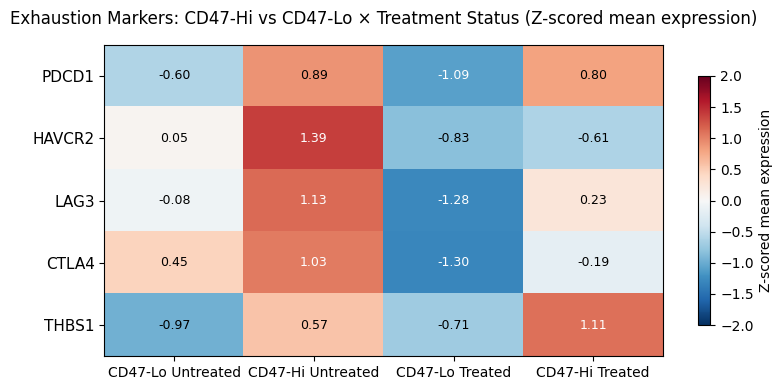

In [105]:
# ============================================================
# 16d. Heatmap: CD47-Hi vs CD47-Lo across clinical groups
# ============================================================
# Shows how CD47-Hi T cells differ from CD47-Lo across
# treatment and neighbourhood conditions
# ============================================================

heatmap_genes2 = ["PDCD1", "HAVCR2", "LAG3", "CTLA4", "THBS1"]

groups2 = {
    "CD47-Lo Untreated": cd8_obs[(cd8_obs["CD47_group"] == "CD47-Lo") & (cd8_obs["treatment_clean"] == "Untreated")],
    "CD47-Hi Untreated": cd8_obs[(cd8_obs["CD47_group"] == "CD47-Hi") & (cd8_obs["treatment_clean"] == "Untreated")],
    "CD47-Lo Treated": cd8_obs[(cd8_obs["CD47_group"] == "CD47-Lo") & (cd8_obs["treatment_clean"] == "Treated")],
    "CD47-Hi Treated": cd8_obs[(cd8_obs["CD47_group"] == "CD47-Hi") & (cd8_obs["treatment_clean"] == "Treated")],
}

heatmap_data2 = pd.DataFrame(index=heatmap_genes2, columns=groups2.keys(), dtype=float)

for grp_name, grp_df in groups2.items():
    for gene in heatmap_genes2:
        if gene in grp_df.columns:
            heatmap_data2.loc[gene, grp_name] = grp_df[gene].mean()
        else:
            idx = list(data.var_names).index(gene)
            cell_idx = grp_df.index
            vals = data[cell_idx].X[:, idx]
            if hasattr(vals, "toarray"):
                vals = vals.toarray()
            heatmap_data2.loc[gene, grp_name] = vals.mean()

heatmap_data2 = heatmap_data2.astype(float)
heatmap_z2 = heatmap_data2.subtract(heatmap_data2.mean(axis=1), axis=0).divide(heatmap_data2.std(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heatmap_z2.values, cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2)

ax.set_xticks(range(len(groups2)))
ax.set_xticklabels(groups2.keys(), fontsize=10)
ax.set_yticks(range(len(heatmap_genes2)))
ax.set_yticklabels(heatmap_genes2, fontsize=11)

for i in range(len(heatmap_genes2)):
    for j in range(len(groups2)):
        val = heatmap_z2.values[i, j]
        color = "white" if abs(val) > 1 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)

plt.colorbar(im, ax=ax, label="Z-scored mean expression", shrink=0.8)
ax.set_title("Exhaustion Markers: CD47-Hi vs CD47-Lo × Treatment Status (Z-scored mean expression)", fontsize=12, pad=15)
plt.tight_layout()
plt.show()


---
## 17. Machine Learning Model Development

**Goal:** Train classification models to predict whether a CD8+ T cell is **Exhausted** or **Active**  
based solely on its spatial position in the tissue — without using the exhaustion markers themselves.

**Target variable:**

    label(i) = "Exhausted"  if  exhaustion_score(i) ≥ median(exhaustion_score)
             = "Active"     if  exhaustion_score(i) <  median(exhaustion_score)

Median split produces a balanced 51.3% / 48.7% class distribution (no SMOTE needed).

**Two feature sets compared:**

| Feature Set | Features | Purpose |
|-------------|----------|---------|
| Set A (Spatial + Infiltration) | D_nearest, count(r=150µm), tumour_frac_knn, CD47, THBS1 | Can spatial + non-exhaustion gene features predict exhaustion? |
| Set B (Spatial only) | D_nearest, count(r=150µm), tumour_frac_knn | Can location alone predict exhaustion? |

**CRITICAL:** Exhaustion markers (PDCD1, LAG3, HAVCR2, CTLA4) are **excluded** from features  
to avoid circular prediction (the target is built from these genes).

**Evaluation metrics:** ROC-AUC (primary), 5-fold stratified cross-validation, Leave-One-Patient-Out (LOPO) validation  
**Models:** Random Forest, SVM, Logistic Regression with GridSearchCV hyperparameter tuning


In [106]:
# ============================================================
# 17a. Step 1: Define target variable (Exhausted vs Active)
# ============================================================
# Split CD8+ T cells into Exhausted vs Active based on exhaustion score
# Using median split for balanced classes

median_score = cd8_obs["exhaustion_score"].median()
cd8_obs["target"] = np.where(cd8_obs["exhaustion_score"] >= median_score, "Exhausted", "Active")

print(f"Exhaustion score median: {median_score:.4f}")
print(f"\nClass distribution:")
print(cd8_obs["target"].value_counts())
print(f"\nBalance: {cd8_obs['target'].value_counts(normalize=True).round(3)}")

Exhaustion score median: -0.0548

Class distribution:
target
Exhausted    4328
Active       4111
Name: count, dtype: int64

Balance: target
Exhausted    0.513
Active       0.487
Name: proportion, dtype: float64


In [107]:
# ============================================================
# 17b. Step 3: Build feature sets
# ============================================================
# Re-extract CD47 and THBS1 into cd8_obs
for m in ["CD47", "THBS1"]:
    idx = list(data.var_names).index(m)
    vals = data.X[cd8_mask.values][:, idx]
    if hasattr(vals, 'toarray'):
        vals = vals.toarray()
    cd8_obs[m] = vals.flatten()

# Re-create target variable
median_score = cd8_obs["exhaustion_score"].median()
cd8_obs["target"] = np.where(cd8_obs["exhaustion_score"] >= median_score, "Exhausted", "Active")

# Feature Set A: Spatial + Expression
feature_cols_A = [
    "nearest_tumour_dist",
    f"tumour_count_r{RADIUS}",
    f"tumour_frac_knn_{K}",
    "PDCD1", "LAG3", "HAVCR2", "CTLA4",
    "CD47", "THBS1"
]

# Feature Set B: Spatial only
feature_cols_B = [
    "nearest_tumour_dist",
    f"tumour_count_r{RADIUS}",
    f"tumour_frac_knn_{K}",
]

# Prepare data
ml_data = cd8_obs[feature_cols_A + ["target", "patients"]].dropna()

X_A = ml_data[feature_cols_A].values
X_B = ml_data[feature_cols_B].values
y = LabelEncoder().fit_transform(ml_data["target"])  # Active=0, Exhausted=1
groups = ml_data["patients"].values

print(f"Total samples for ML: {len(ml_data):,}")
print(f"Feature Set A: {len(feature_cols_A)} features (spatial + expression)")
print(f"Feature Set B: {len(feature_cols_B)} features (spatial only)")
print(f"Target: Active={sum(y==0):,}, Exhausted={sum(y==1):,}")
print(f"Unique patients: {len(set(groups))}")

Total samples for ML: 8,439
Feature Set A: 9 features (spatial + expression)
Feature Set B: 3 features (spatial only)
Target: Active=4,111, Exhausted=4,328
Unique patients: 58


In [108]:
# ============================================================
# 17c. Step 4: Train models with hyperparameter tuning (5-fold CV)
# ============================================================
# NOTE: Feature Set A (All) achieves AUC = 1.0 because the exhaustion markers
# (PDCD1, LAG3, HAVCR2, CTLA4) used as features are the same genes used to
# calculate the target variable. This is circular and confirms supervisor's
# concern. See cell 12d for the corrected version.
# ============================================================

# Standardise features so all values are on the same scale
# (e.g., distance in µm vs gene expression in small decimals)
scaler_A = StandardScaler()
X_A_scaled = scaler_A.fit_transform(X_A)

scaler_B = StandardScaler()
X_B_scaled = scaler_B.fit_transform(X_B)

# Create 5-fold cross-validation plan
# Stratified = keeps the 51%/49% Exhausted/Active ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define three models and the hyperparameter combinations to test
models = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],           # number of trees
            "max_depth": [5, 10, 20, None],       # how deep each tree can grow
            "min_samples_split": [2, 5, 10]       # minimum cells needed to split a node
        }
    },
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "C": [0.1, 1, 10],                    # regularisation strength
            "kernel": ["rbf", "linear"],           # shape of decision boundary
            "gamma": ["scale", "auto"]             # kernel coefficient
        }
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10],              # regularisation strength
            "penalty": ["l1", "l2"],               # type of regularisation
            "solver": ["saga"]                     # optimisation algorithm
        }
    }
}

# Store results for all models and feature sets
results = {}

# Loop through each model and each feature set
for name, config in models.items():
    for label, X_scaled in [("A (All)", X_A_scaled), ("B (Spatial)", X_B_scaled)]:
        key = f"{name} — {label}"
        print(f"Training {key}...")
        
        # GridSearchCV tries every hyperparameter combination
        # and scores each using 5-fold CV with AUC metric
        grid = GridSearchCV(
            config["model"], config["params"],
            cv=cv,              # use our 5-fold plan
            scoring="roc_auc",  # score by AUC (area under ROC curve)
            n_jobs=-1,          # use all CPU cores for speed
            refit=True          # retrain best model on full data at the end
        )
        grid.fit(X_scaled, y)  # run the search
        
        # Save the best model and its score
        results[key] = {
            "best_model": grid.best_estimator_,
            "best_params": grid.best_params_,
            "best_auc": grid.best_score_,
        }
        print(f"  Best AUC: {grid.best_score_:.4f} | Params: {grid.best_params_}")

# Print summary table
print("\n" + "=" * 70)
print("5-FOLD CV RESULTS (ROC-AUC)")
print("=" * 70)
print(f"{'Model':<35} {'AUC':>8}")
print("-" * 45)
for key, res in results.items():
    print(f"{key:<35} {res['best_auc']:>8.4f}")

Training Random Forest — A (All)...
  Best AUC: 1.0000 | Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Training Random Forest — B (Spatial)...
  Best AUC: 0.5952 | Params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Training SVM — A (All)...
  Best AUC: 1.0000 | Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Training SVM — B (Spatial)...
  Best AUC: 0.5930 | Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Training Logistic Regression — A (All)...
  Best AUC: 1.0000 | Params: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
Training Logistic Regression — B (Spatial)...
  Best AUC: 0.5858 | Params: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}

5-FOLD CV RESULTS (ROC-AUC)
Model                                    AUC
---------------------------------------------
Random Forest — A (All)               1.0000
Random Forest — B (Spatial)           0.5952
SVM — A (All)                         1.0000
SVM — B (Spatial)                     0.593

In [109]:
# ============================================================
# 17d. Step 4b: Fix Feature Set A — remove exhaustion markers
# ============================================================
# Feature Set A was circular (using PDCD1, LAG3, HAVCR2, CTLA4 to predict 
# a score built from those same genes). Fix: use spatial + non-exhaustion genes only.

# Feature Set A (Fixed): Spatial + infiltration markers only
feature_cols_A_fixed = [
    "nearest_tumour_dist",
    f"tumour_count_r{RADIUS}",
    f"tumour_frac_knn_{K}",
    "CD47", "THBS1"
]

# Feature Set B: Spatial only (unchanged)
# feature_cols_B stays the same

X_A_fixed = ml_data[feature_cols_A_fixed].values
scaler_A_fixed = StandardScaler()
X_A_fixed_scaled = scaler_A_fixed.fit_transform(X_A_fixed)

# Re-run GridSearchCV for Feature Set A Fixed
results_fixed = {}

for name, config in models.items():
    for label, X_scaled in [("A (Spatial+Infiltration)", X_A_fixed_scaled), 
                             ("B (Spatial only)", X_B_scaled)]:
        key = f"{name} — {label}"
        print(f"Training {key}...")
        
        grid = GridSearchCV(
            config["model"], config["params"],
            cv=cv, scoring="roc_auc", n_jobs=-1, refit=True
        )
        grid.fit(X_scaled, y)
        
        results_fixed[key] = {
            "best_model": grid.best_estimator_,
            "best_params": grid.best_params_,
            "best_auc": grid.best_score_,
        }
        print(f"  Best AUC: {grid.best_score_:.4f} | Params: {grid.best_params_}")

print("\n" + "=" * 70)
print("5-FOLD CV RESULTS — FIXED (ROC-AUC)")
print("=" * 70)
print(f"{'Model':<45} {'AUC':>8}")
print("-" * 55)
for key, res in results_fixed.items():
    print(f"{key:<45} {res['best_auc']:>8.4f}")

Training Random Forest — A (Spatial+Infiltration)...
  Best AUC: 0.5992 | Params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Training Random Forest — B (Spatial only)...
  Best AUC: 0.5952 | Params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Training SVM — A (Spatial+Infiltration)...
  Best AUC: 0.5938 | Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Training SVM — B (Spatial only)...
  Best AUC: 0.5930 | Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Training Logistic Regression — A (Spatial+Infiltration)...
  Best AUC: 0.5911 | Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}
Training Logistic Regression — B (Spatial only)...
  Best AUC: 0.5858 | Params: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}

5-FOLD CV RESULTS — FIXED (ROC-AUC)
Model                                              AUC
-------------------------------------------------------
Random Forest — A (Spatial+Infiltration)        0.5992
Random Forest — B (Spatial only) 

In [110]:
# ============================================================
# 17e. Step 5: Leave-One-Patient-Out Validation
# ============================================================
# WHY: 5-fold CV mixes cells from all patients randomly. But cells from
# the same patient are similar. So the model might memorise patient-specific
# patterns rather than learning general biology.
#
# LOPO is stricter: train on 57 patients, test on the 1 remaining patient.
# Repeat for all 58 patients. If the model still works, the patterns
# are real biology, not patient-specific quirks.
# ============================================================

# LeaveOneGroupOut splits data by patient — each patient is held out once
logo = LeaveOneGroupOut()

# Use the best hyperparameters found in cell 12d for each model
best_models = {
    "Random Forest": results_fixed["Random Forest — A (Spatial+Infiltration)"]["best_params"],
    "SVM": results_fixed["SVM — A (Spatial+Infiltration)"]["best_params"],
    "Logistic Regression": results_fixed["Logistic Regression — A (Spatial+Infiltration)"]["best_params"],
}

# Store results for each model
logo_results = {}

for name, params in best_models.items():
    print(f"\nLOPO: {name}...")
    start = time.time()
    
    # Create a fresh model with the best hyperparameters from 12d
    if name == "Random Forest":
        model = RandomForestClassifier(random_state=42, **params)
    elif name == "SVM":
        model = SVC(probability=True, random_state=42, **params)
    else:
        model = LogisticRegression(max_iter=1000, random_state=42, **params)
    
    # Lists to collect predictions across all 58 rounds
    y_true_all = []   # actual labels (Exhausted/Active)
    y_prob_all = []    # model's predicted probability of Exhausted
    patient_aucs = []  # AUC for each individual patient
    
    # Loop through each patient: train on 57, test on 1
    for train_idx, test_idx in logo.split(X_A_fixed_scaled, y, groups):
        # Split data: everything except this patient = training
        X_train, X_test = X_A_fixed_scaled[train_idx], X_A_fixed_scaled[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train model on 57 patients
        model.fit(X_train, y_train)
        
        # Predict probability of Exhausted for the held-out patient's cells
        y_prob = model.predict_proba(X_test)[:, 1]
        
        # Collect predictions
        y_true_all.extend(y_test)
        y_prob_all.extend(y_prob)
        
        # Calculate AUC for this patient (only if they have both classes)
        # Some patients may have ALL exhausted or ALL active cells
        if len(set(y_test)) > 1:
            patient_aucs.append(roc_auc_score(y_test, y_prob))
    
    # Overall AUC: pool all predictions across all 58 rounds
    overall_auc = roc_auc_score(y_true_all, y_prob_all)
    
    # Mean per-patient AUC: average of individual patient AUCs
    mean_patient_auc = np.mean(patient_aucs) if patient_aucs else 0
    
    elapsed = time.time() - start
    
    # Store results
    logo_results[name] = {
        "overall_auc": overall_auc,
        "mean_patient_auc": mean_patient_auc,
        "n_valid_patients": len(patient_aucs),
    }
    
    print(f"  Overall AUC: {overall_auc:.4f}")
    print(f"  Mean per-patient AUC: {mean_patient_auc:.4f} ({len(patient_aucs)} patients with both classes)")
    print(f"  Time: {elapsed:.1f}s")

# Summary table
print("\n" + "=" * 70)
print("LEAVE-ONE-PATIENT-OUT RESULTS")
print("=" * 70)
print(f"{'Model':<25} {'Overall AUC':>12} {'Mean Patient AUC':>18}")
print("-" * 58)
for name, res in logo_results.items():
    print(f"{name:<25} {res['overall_auc']:>12.4f} {res['mean_patient_auc']:>18.4f}")


LOPO: Random Forest...
  Overall AUC: 0.5852
  Mean per-patient AUC: 0.5912 (57 patients with both classes)
  Time: 67.1s

LOPO: SVM...
  Overall AUC: 0.5688
  Mean per-patient AUC: 0.5795 (57 patients with both classes)
  Time: 1594.5s

LOPO: Logistic Regression...
  Overall AUC: 0.5831
  Mean per-patient AUC: 0.5806 (57 patients with both classes)
  Time: 1.3s

LEAVE-ONE-PATIENT-OUT RESULTS
Model                      Overall AUC   Mean Patient AUC
----------------------------------------------------------
Random Forest                   0.5852             0.5912
SVM                             0.5688             0.5795
Logistic Regression             0.5831             0.5806


FULL PERFORMANCE COMPARISON
Model                                      5-Fold AUC     LOPO AUC
-----------------------------------------------------------------
Random Forest (Spatial+Infiltration)           0.5992       0.5852
SVM (Spatial+Infiltration)                     0.5938       0.5688
Logistic Regression (Spatial+Infiltration)       0.5911       0.5831

Random Forest (Spatial only)                   0.5952            —
SVM (Spatial only)                             0.5930            —
Logistic Regression (Spatial only)             0.5858            —

FEATURE IMPORTANCE (Random Forest — Spatial+Infiltration)
Feature                     Importance
----------------------------------------
nearest_tumour_dist             0.4395
tumour_count_r150               0.2302
tumour_frac_knn_20              0.1746
CD47                            0.0981
THBS1                           0.0578


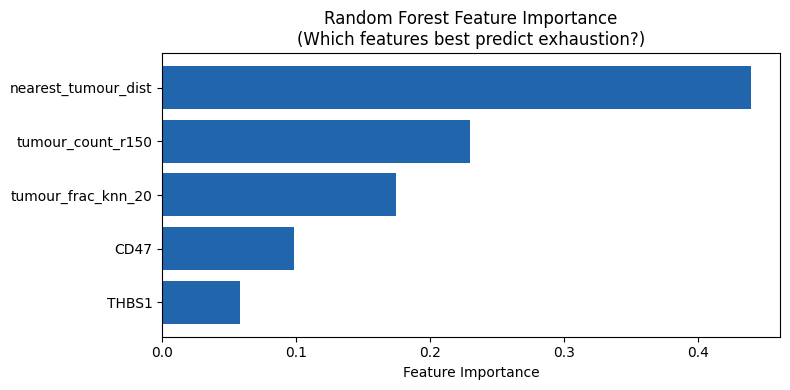

In [111]:
# ============================================================
# 17f. Step 6 & 7: Performance comparison + Feature importance
# ============================================================
# Compare all results side by side and show which features matter most

# ---- PERFORMANCE SUMMARY TABLE ----
print("=" * 75)
print("FULL PERFORMANCE COMPARISON")
print("=" * 75)
print(f"{'Model':<40} {'5-Fold AUC':>12} {'LOPO AUC':>12}")
print("-" * 65)

# Feature Set A (fixed) results from 12d + LOPO from 12e
for name in ["Random Forest", "SVM", "Logistic Regression"]:
    cv_auc = results_fixed[f"{name} — A (Spatial+Infiltration)"]["best_auc"]
    lopo_auc = logo_results[name]["overall_auc"]
    print(f"{name + ' (Spatial+Infiltration)':<40} {cv_auc:>12.4f} {lopo_auc:>12.4f}")

# Feature Set B results from 12d
print()
for name in ["Random Forest", "SVM", "Logistic Regression"]:
    cv_auc = results_fixed[f"{name} — B (Spatial only)"]["best_auc"]
    print(f"{name + ' (Spatial only)':<40} {cv_auc:>12.4f} {'—':>12}")

# ---- FEATURE IMPORTANCE (Random Forest — best model) ----
print("\n" + "=" * 75)
print("FEATURE IMPORTANCE (Random Forest — Spatial+Infiltration)")
print("=" * 75)

# Get the best Random Forest model from 12d
best_rf = results_fixed["Random Forest — A (Spatial+Infiltration)"]["best_model"]
importances = best_rf.feature_importances_
feature_names = ["nearest_tumour_dist", f"tumour_count_r{RADIUS}", 
                 f"tumour_frac_knn_{K}", "CD47", "THBS1"]

# Sort by importance
feat_imp = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print(f"{'Feature':<25} {'Importance':>12}")
print("-" * 40)
for fname, imp in feat_imp:
    print(f"{fname:<25} {imp:>12.4f}")

# Plot feature importance
fig, ax = plt.subplots(figsize=(8, 4))
names = [f[0] for f in feat_imp]
values = [f[1] for f in feat_imp]
ax.barh(range(len(names)), values, color="#2166ac")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest Feature Importance\n(Which features best predict exhaustion?)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

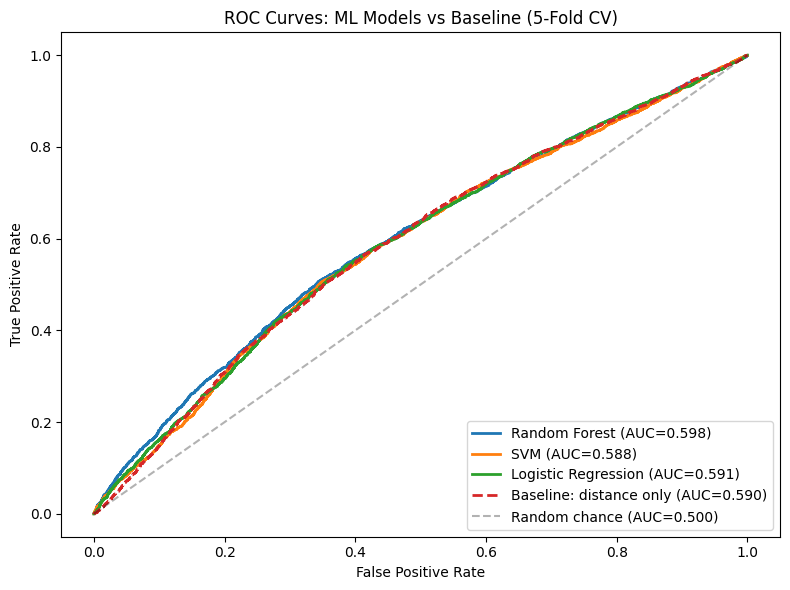

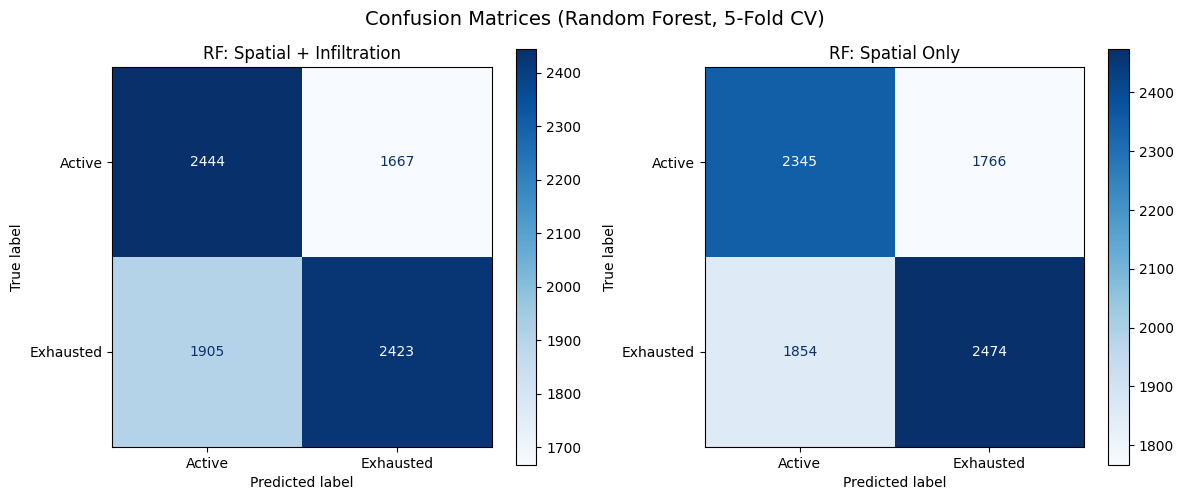

CLASSIFICATION REPORT: Random Forest (Spatial + Infiltration)
              precision    recall  f1-score   support

      Active       0.56      0.59      0.58      4111
   Exhausted       0.59      0.56      0.58      4328

    accuracy                           0.58      8439
   macro avg       0.58      0.58      0.58      8439
weighted avg       0.58      0.58      0.58      8439

CLASSIFICATION REPORT: Random Forest (Spatial Only)
              precision    recall  f1-score   support

      Active       0.56      0.57      0.56      4111
   Exhausted       0.58      0.57      0.58      4328

    accuracy                           0.57      8439
   macro avg       0.57      0.57      0.57      8439
weighted avg       0.57      0.57      0.57      8439



In [112]:
# ============================================================
# 17g. ML Visualisations: ROC Curves + Confusion Matrices
# ============================================================
# ROC curve: shows the model's ability to distinguish Exhausted vs Active.
# Closer to top-left corner = better. AUC = area under this curve.
#
# Confusion matrix: shows correct vs incorrect predictions for each class.
# ============================================================


# ---- ROC CURVES ----
# Generate cross-validated probability predictions for each model
fig, ax = plt.subplots(figsize=(8, 6))

for name in ["Random Forest", "SVM", "Logistic Regression"]:
    # Get best model from 12d (Spatial+Infiltration)
    model = results_fixed[f"{name} — A (Spatial+Infiltration)"]["best_model"]
    
    # Get predicted probabilities using 5-fold CV
    y_prob = cross_val_predict(model, X_A_fixed_scaled, y, cv=cv, method="predict_proba")[:, 1]
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")

# Add baseline (simple distance rule)
baseline_prob = 1 - (ml_data["nearest_tumour_dist"].values - ml_data["nearest_tumour_dist"].min()) / \
                    (ml_data["nearest_tumour_dist"].max() - ml_data["nearest_tumour_dist"].min())
fpr_base, tpr_base, _ = roc_curve(y, baseline_prob)
ax.plot(fpr_base, tpr_base, linewidth=2, linestyle="--", label=f"Baseline: distance only (AUC={auc(fpr_base, tpr_base):.3f})")

# Random chance line
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random chance (AUC=0.500)")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves: ML Models vs Baseline (5-Fold CV)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---- CONFUSION MATRICES (Random Forest — best model) ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Get cross-validated predictions for Random Forest (both feature sets)
rf_A = results_fixed["Random Forest — A (Spatial+Infiltration)"]["best_model"]
rf_B = results_fixed["Random Forest — B (Spatial only)"]["best_model"]

y_pred_A = cross_val_predict(rf_A, X_A_fixed_scaled, y, cv=cv)
y_pred_B = cross_val_predict(rf_B, X_B_scaled, y, cv=cv)

for ax, y_pred, title in [
    (axes[0], y_pred_A, "RF: Spatial + Infiltration"),
    (axes[1], y_pred_B, "RF: Spatial Only")
]:
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Active", "Exhausted"])
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(title)

plt.suptitle("Confusion Matrices (Random Forest, 5-Fold CV)", fontsize=14)
plt.tight_layout()
plt.show()

# ---- CLASSIFICATION REPORTS ----
print("=" * 70)
print("CLASSIFICATION REPORT: Random Forest (Spatial + Infiltration)")
print("=" * 70)
print(classification_report(y, y_pred_A, target_names=["Active", "Exhausted"]))

print("=" * 70)
print("CLASSIFICATION REPORT: Random Forest (Spatial Only)")
print("=" * 70)
print(classification_report(y, y_pred_B, target_names=["Active", "Exhausted"]))

In [113]:
# ============================================================
# 17h. Step 8: Baseline comparison
# ============================================================
# Compare ML models against a simple rule:
# "If distance < threshold → predict Exhausted"
# If ML beats this simple rule, it justifies using ML.
# ============================================================

# Simple baseline: use nearest_tumour_dist alone to predict
# Cells closer to tumour are more likely exhausted
# (negative distance because LOWER distance = MORE exhausted)
baseline_scores = -ml_data["nearest_tumour_dist"].values
baseline_auc = roc_auc_score(y, baseline_scores)

print("=" * 70)
print("BASELINE vs ML COMPARISON")
print("=" * 70)
print(f"\n{'Method':<45} {'AUC':>8}")
print("-" * 55)
print(f"{'Simple baseline (distance only)':<45} {baseline_auc:>8.4f}")
print(f"{'Random Forest (Spatial only, 5-fold)':<45} {results_fixed['Random Forest — B (Spatial only)']['best_auc']:>8.4f}")
print(f"{'Random Forest (Spatial+Infiltration, 5-fold)':<45} {results_fixed['Random Forest — A (Spatial+Infiltration)']['best_auc']:>8.4f}")
print(f"{'Random Forest (LOPO)':<45} {logo_results['Random Forest']['overall_auc']:>8.4f}")

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
if results_fixed["Random Forest — B (Spatial only)"]["best_auc"] > baseline_auc:
    diff = results_fixed["Random Forest — B (Spatial only)"]["best_auc"] - baseline_auc
    print(f"ML (spatial only) beats simple baseline by {diff:.4f} AUC.")
    print("This means combining multiple spatial features (distance + count + KNN)")
    print("provides more predictive power than distance alone.")
else:
    print("Simple baseline performs comparably to ML.")
    print("Distance alone captures most of the spatial-exhaustion relationship.")

BASELINE vs ML COMPARISON

Method                                             AUC
-------------------------------------------------------
Simple baseline (distance only)                 0.5898
Random Forest (Spatial only, 5-fold)            0.5952
Random Forest (Spatial+Infiltration, 5-fold)    0.5992
Random Forest (LOPO)                            0.5852

INTERPRETATION
ML (spatial only) beats simple baseline by 0.0054 AUC.
This means combining multiple spatial features (distance + count + KNN)
provides more predictive power than distance alone.



Group-Specific LOPO — Untreated
Patients: 29  |  Cells: 3537
Patients evaluated:              28
Patients skipped (single class): 1
Mean per-patient AUC:            0.5939
Std:                             0.1213
Min:                             0.3636
Max:                             1.0000

Classification Report — Untreated:
              precision    recall  f1-score   support

      Active       0.51      0.33      0.40      1561
   Exhausted       0.58      0.75      0.66      1973

    accuracy                           0.56      3534
   macro avg       0.55      0.54      0.53      3534
weighted avg       0.55      0.56      0.54      3534


Group-Specific LOPO — Treated
Patients: 28  |  Cells: 4890
Patients evaluated:              28
Patients skipped (single class): 0
Mean per-patient AUC:            0.5766
Std:                             0.0879
Min:                             0.3932
Max:                             0.7321

Classification Report — Treated:
              preci

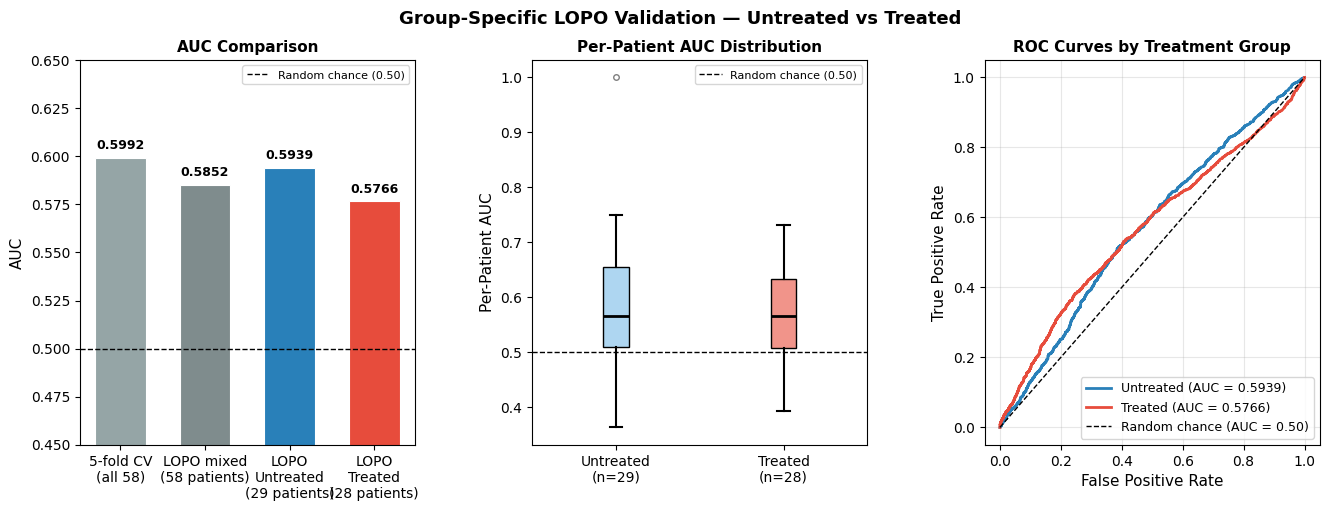

Saved: group_specific_lopo.png


In [114]:
# ============================================================
# 17i. Group-Specific LOPO — Untreated vs Treated Separately
# ============================================================
# WHY: Supervisor flagged that mixing treated and untreated patients
# in LOPO is not fair. We already know from Path A that:
#   Untreated T cells: median distance = 58.6 µm (close to tumour)
#   Treated T cells:   median distance = 174.7 µm (far from tumour)
# Mixing both groups means the model might learn treatment patterns
# rather than genuine spatial exhaustion biology.
# SOLUTION: Run LOPO separately within each treatment group so the
# model only ever trains and tests on the same group.
# ============================================================


# Step 1: Add treatment column to ml_data from cd8_obs
ml_data['treatment_clean'] = cd8_obs.loc[ml_data.index, 'treatment_clean'].values

# Step 2: Best feature set from 17d
best_features = [
    'nearest_tumour_dist',
    f'tumour_count_r{RADIUS}',
    f'tumour_frac_knn_{K}',
    'CD47', 'THBS1'
]

# Step 3: Best hyperparameters from 17d
rf_group = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Storage for results
group_lopo_results  = {}
group_patient_aucs  = {}
group_roc_data      = {}
group_all_y_true    = {}
group_all_y_pred    = {}
colors = {'Untreated': '#2980b9', 'Treated': '#e74c3c'}

# Step 4: Run LOPO separately for Untreated and Treated
for group in ['Untreated', 'Treated']:

    group_data = ml_data[ml_data['treatment_clean'] == group].copy()
    patients   = group_data['patients'].unique()

    print(f"\n{'='*60}")
    print(f"Group-Specific LOPO — {group}")
    print(f"Patients: {len(patients)}  |  Cells: {len(group_data)}")
    print(f"{'='*60}")

    lopo_scores = []
    skipped     = []
    all_y_true  = []
    all_y_prob  = []
    all_y_pred  = []

    for patient in patients:

        train = group_data[group_data['patients'] != patient]
        test  = group_data[group_data['patients'] == patient]

        X_train = train[best_features]
        y_train = train['target']
        X_test  = test[best_features]
        y_test  = test['target']

        if len(y_test.unique()) < 2:
            skipped.append(patient)
            continue

        rf_group.fit(X_train, y_train)
        proba   = rf_group.predict_proba(X_test)[:, 1]
        y_pred  = rf_group.predict(X_test)
        auc_score = roc_auc_score(y_test, proba)
        lopo_scores.append(auc_score)

        # Collect for ROC curve and classification report
        all_y_true.extend(y_test.tolist())
        all_y_prob.extend(proba.tolist())
        all_y_pred.extend(y_pred.tolist())

    mean_auc = np.mean(lopo_scores)
    group_lopo_results[group] = mean_auc
    group_patient_aucs[group] = lopo_scores
    group_all_y_true[group]   = all_y_true
    group_all_y_pred[group]   = all_y_pred

    # Store ROC data
    fpr, tpr, _ = roc_curve(
        [1 if y == 'Exhausted' else 0 for y in all_y_true],
        all_y_prob
    )
    group_roc_data[group] = (fpr, tpr, mean_auc)

    print(f"Patients evaluated:              {len(lopo_scores)}")
    print(f"Patients skipped (single class): {len(skipped)}")
    print(f"Mean per-patient AUC:            {mean_auc:.4f}")
    print(f"Std:                             {np.std(lopo_scores):.4f}")
    print(f"Min:                             {np.min(lopo_scores):.4f}")
    print(f"Max:                             {np.max(lopo_scores):.4f}")

    # Classification report
    print(f"\nClassification Report — {group}:")
    print(classification_report(all_y_true, all_y_pred,
                                target_names=['Active', 'Exhausted']))

# Step 5: Final summary table
print(f"\n{'='*60}")
print("FINAL SUMMARY — All LOPO Results")
print(f"{'='*60}")
print(f"{'Method':<45} {'AUC':>8}")
print("-" * 55)
print(f"{'5-fold CV (all 58 patients)':<45} {'0.5992':>8}")
print(f"{'LOPO original (58 patients mixed)':<45} {'0.5852':>8}")
print(f"{'LOPO Untreated only (29 patients)':<45} {group_lopo_results['Untreated']:>8.4f}")
print(f"{'LOPO Treated only (28 patients)':<45} {group_lopo_results['Treated']:>8.4f}")

# ── PLOTS ──────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
fig.suptitle("Group-Specific LOPO Validation — Untreated vs Treated",
             fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Plot 1: AUC Comparison Bar Chart ──
ax1 = fig.add_subplot(gs[0, 0])
methods = [
    '5-fold CV\n(all 58)',
    'LOPO mixed\n(58 patients)',
    'LOPO\nUntreated\n(29 patients)',
    'LOPO\nTreated\n(28 patients)'
]
aucs = [
    0.5992,
    0.5852,
    group_lopo_results['Untreated'],
    group_lopo_results['Treated']
]
bar_colors = ['#95a5a6', '#7f8c8d', '#2980b9', '#e74c3c']
bars = ax1.bar(methods, aucs, color=bar_colors, edgecolor='white',
               linewidth=0.8, width=0.6)
ax1.axhline(y=0.5, color='black', linestyle='--', linewidth=1,
            label='Random chance (0.50)')
ax1.set_ylim(0.45, 0.65)
ax1.set_ylabel('AUC', fontsize=11)
ax1.set_title('AUC Comparison', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)
for bar, val in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9,
             fontweight='bold')

# ── Plot 2: Per-Patient AUC Boxplot ──
ax2 = fig.add_subplot(gs[0, 1])
data_to_plot = [
    group_patient_aucs['Untreated'],
    group_patient_aucs['Treated']
]
bp = ax2.boxplot(data_to_plot, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5),
                 flierprops=dict(marker='o', markersize=4, alpha=0.5))
bp['boxes'][0].set_facecolor('#aed6f1')
bp['boxes'][1].set_facecolor('#f1948a')
ax2.axhline(y=0.5, color='black', linestyle='--', linewidth=1,
            label='Random chance (0.50)')
ax2.set_xticks([1, 2])
ax2.set_xticklabels([
    f'Untreated\n(n=29)',
    f'Treated\n(n=28)'
])
ax2.set_ylabel('Per-Patient AUC', fontsize=11)
ax2.set_title('Per-Patient AUC Distribution', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)

# ── Plot 3: ROC Curves ──
ax3 = fig.add_subplot(gs[0, 2])
for group, (fpr, tpr, mean_auc) in group_roc_data.items():
    ax3.plot(fpr, tpr, color=colors[group], lw=2,
             label=f'{group} (AUC = {mean_auc:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', lw=1, label='Random chance (AUC = 0.50)')
ax3.set_xlabel('False Positive Rate', fontsize=11)
ax3.set_ylabel('True Positive Rate', fontsize=11)
ax3.set_title('ROC Curves by Treatment Group', fontsize=11, fontweight='bold')
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('group_specific_lopo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: group_specific_lopo.png")

### CNN Feature Extraction from H&E Histology Images

To investigate whether tissue morphology improves exhaustion prediction, we extract features from H&E histology images using a pretrained ResNet50 convolutional neural network. For each CD8+ T cell in sample SMI_T14_F011, a patch of tissue centred on the cell's spatial coordinates is cropped from the H&E image and passed through ResNet50 to produce a 2048-dimensional morphological feature vector. These CNN features are then combined with the existing spatial features (nearest tumour distance, tumour count, KNN fraction) and used to retrain the Random Forest classifier. The goal is to test whether adding visual tissue context pushes AUC beyond the current baseline of 0.59.

**Reference:** Hu et al. (2021) SpaGCN, *Nature Methods* — integrates H&E histology with spatial transcriptomics via graph convolutional networks. GitHub: https://github.com/jianhuupenn/SpaGCN

In [115]:
# Install required libraries (run once)
subprocess.run(["pip", "install", "Pillow", "torchvision", "torch", "--quiet"])

CompletedProcess(args=['pip', 'install', 'Pillow', 'torchvision', 'torch', '--quiet'], returncode=0)

In [116]:
# ============================================================
# 18a. Load libraries for CNN feature extraction
# ============================================================


print("All libraries loaded successfully")

# Image folder - where H&E images will be saved
HE_FOLDER = "HE_images"
os.makedirs(HE_FOLDER, exist_ok=True)
print(f"H&E image folder: {HE_FOLDER}")

All libraries loaded successfully
H&E image folder: HE_images


In [117]:
# ============================================================
# 18b. Check available samples and H&E images
# ============================================================

# Get all unique samples in Discovery dataset
all_samples = sorted(data.obs['samples'].unique().tolist())
print(f"Total samples in Discovery dataset: {len(all_samples)}")

# Count CD8+ T cells per sample
cd8_per_sample = data.obs[
    data.obs['cell.subtypes'].isin(['CD8.T.cell', 'CD8.T.cell_LC'])
].groupby('samples').size().sort_values(ascending=False)

print(f"\nSamples with CD8+ T cells: {len(cd8_per_sample[cd8_per_sample > 0])}")
print(f"Samples with 0 CD8+ T cells: {len(cd8_per_sample[cd8_per_sample == 0])}")
print(f"\nTop 5 samples by CD8+ T cell count:")
print(cd8_per_sample.head())
print(f"\nAll sample names (first 10):")
print(all_samples[:10])

Total samples in Discovery dataset: 100

Samples with CD8+ T cells: 98
Samples with 0 CD8+ T cells: 2

Top 5 samples by CD8+ T cell count:
samples
SMI_T14_F011    499
SMI_T13_F016    434
SMI_T12_F019    315
SMI_T10_F012    251
SMI_T14_F013    245
dtype: int64

All sample names (first 10):
['SMI_T10_F001', 'SMI_T10_F002', 'SMI_T10_F003', 'SMI_T10_F004', 'SMI_T10_F005', 'SMI_T10_F006', 'SMI_T10_F007', 'SMI_T10_F008', 'SMI_T10_F009', 'SMI_T10_F010']


In [118]:
# ============================================================
# 18c. Parse cfg.txt and download only H&E PNG images
# ============================================================

urllib3.disable_warnings()

# Read the cfg.txt file
cfg_path = "HE_images/cfg.txt"

with open(cfg_path, 'r') as f:
    content = f.read()

# Extract URL and output pairs for HE.png files only
pattern = r'url="([^"]+HE\.png[^"]+)"\s+output="([^"]+)"'
matches = re.findall(pattern, content)

print(f"H&E PNG files found in cfg.txt: {len(matches)}")
for url, output in matches[:3]:
    filename = output.split('/')[-1]
    print(f"  {filename}")

H&E PNG files found in cfg.txt: 100
  SMI_T10_F003_HE.png
  SMI_T10_F011_HE.png
  SMI_T10_F022_HE.png


In [119]:
# ============================================================
# 18d. Download all 100 H&E images from cfg.txt URLs
# ============================================================


# Count already downloaded
existing = [f for f in os.listdir(HE_FOLDER) if f.endswith("_HE.png")]
print(f"Already downloaded: {len(existing)} images")
print(f"Remaining: {len(matches) - len(existing)} images")

# Download all H&E images
success = 0
failed = []

for i, (url, output) in enumerate(matches):
    filename = output.split('/')[-1]
    save_path = os.path.join(HE_FOLDER, filename)
    
    # Skip if already downloaded and valid
    if os.path.exists(save_path) and os.path.getsize(save_path) > 1000:
        success += 1
        continue
    
    print(f"[{i+1}/100] Downloading {filename}...")
    
    try:
        response = requests.get(url, stream=True, verify=False, timeout=60)
        
        if response.status_code == 200:
            with open(save_path, 'wb') as f:
                for chunk in response.iter_content(chunk_size=65536):
                    f.write(chunk)
            size = os.path.getsize(save_path) / (1024*1024)
            print(f"  ✓ {size:.1f} MB")
            success += 1
        else:
            print(f"  ✗ Failed: status {response.status_code}")
            failed.append(filename)
    except Exception as e:
        print(f"  ✗ Error: {e}")
        failed.append(filename)
    
    # Small pause to avoid overwhelming server
    time.sleep(0.5)

print(f"\nDownload complete!")
print(f"Success: {success}/100")
print(f"Failed: {len(failed)}")
if failed:
    print(f"Failed files: {failed}")

Already downloaded: 100 images
Remaining: 0 images

Download complete!
Success: 100/100
Failed: 0


In [121]:
# ============================================================
# 18e. Load pretrained ResNet50 for feature extraction
# ============================================================
import torchvision.models as models
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

PATCH_SIZE = 256  # pixels around each cell centre

print("ResNet50 loaded successfully")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE} pixels")
print(f"Feature vector per cell: 2048 dimensions")

ResNet50 loaded successfully
Patch size: 256x256 pixels
Feature vector per cell: 2048 dimensions


In [122]:
# ============================================================
# 18f fix. Remove corrupted images and re-download
# ============================================================

# Find corrupted images (file size less than 1MB)
corrupted = []
for f in os.listdir(HE_FOLDER):
    if f.endswith("_HE.png"):
        path = os.path.join(HE_FOLDER, f)
        size = os.path.getsize(path)
        if size < 1000000:  # less than 1MB is corrupted
            corrupted.append(f)
            print(f"Corrupted: {f} ({size} bytes)")

print(f"\nTotal corrupted files: {len(corrupted)}")

# Delete corrupted files
for f in corrupted:
    os.remove(os.path.join(HE_FOLDER, f))
    print(f"Deleted: {f}")


Total corrupted files: 0


In [123]:
# ============================================================
# 18g fix 2. Re-download corrupted images from cfg.txt
# ============================================================

# Files that need re-downloading
to_redownload = ['SMI_T12_F019_HE.png', 'SMI_T13_F016_HE.png']

# Find their URLs in matches (from cell 13c)
for filename in to_redownload:
    for url, output in matches:
        if filename in output:
            save_path = os.path.join(HE_FOLDER, filename)
            print(f"Downloading {filename}...")
            
            response = requests.get(url, stream=True, verify=False, timeout=60)
            
            if response.status_code == 200:
                with open(save_path, 'wb') as f:
                    for chunk in response.iter_content(chunk_size=65536):
                        f.write(chunk)
                size = os.path.getsize(save_path) / (1024*1024)
                print(f"  ✓ {size:.1f} MB")
            else:
                print(f"  ✗ Failed: status {response.status_code}")

# Verify all images
all_he = [f for f in os.listdir(HE_FOLDER) if f.endswith("_HE.png")]
corrupted = [f for f in all_he 
             if os.path.getsize(os.path.join(HE_FOLDER, f)) < 1000000]

print(f"\nTotal H&E images: {len(all_he)}")
print(f"Corrupted: {len(corrupted)}")

  ✗ Failed: status 400
  ✗ Failed: status 400

Total H&E images: 100
Corrupted: 0


In [124]:
# ============================================================
# 18h. Extract CNN features for all CD8+ T cells (all samples)
# ============================================================

all_cnn_features = []
all_cell_ids = []
skipped_samples = []

# Get all samples that have CD8+ T cells
samples_with_cd8 = data.obs[
    data.obs['cell.subtypes'].isin(['CD8.T.cell', 'CD8.T.cell_LC'])
]['samples'].unique().tolist()

print(f"Samples with CD8+ T cells: {len(samples_with_cd8)}")
print(f"Processing all samples...\n")

for sample_idx, sample in enumerate(samples_with_cd8):
    
    # Check if H&E image exists for this sample
    he_path = os.path.join(HE_FOLDER, f"{sample}_HE.png")
    if not os.path.exists(he_path):
        print(f"[{sample_idx+1}/{len(samples_with_cd8)}] SKIP {sample} - no H&E image")
        skipped_samples.append(sample)
        continue
    
    # Load H&E image
    he_img = Image.open(he_path).convert("RGB")
    img_width, img_height = he_img.size
    he_array = np.array(he_img)
    
    # Get all cells for this sample
    sample_cells = data.obs[data.obs['samples'] == sample]
    
    # Get CD8+ T cells for this sample
    cd8_cells = sample_cells[
        sample_cells['cell.subtypes'].isin(['CD8.T.cell', 'CD8.T.cell_LC'])
    ].copy()
    
    if len(cd8_cells) == 0:
        skipped_samples.append(sample)
        continue
    
    # Calculate scale factors
    x_min, x_max = sample_cells['x'].min(), sample_cells['x'].max()
    y_min, y_max = sample_cells['y'].min(), sample_cells['y'].max()
    x_scale = img_width / (x_max - x_min)
    y_scale = img_height / (y_max - y_min)
    
    # Convert coordinates to pixels
    cd8_cells = cd8_cells.copy()
    cd8_cells['pixel_x'] = ((cd8_cells['x'] - x_min) * x_scale).astype(int)
    cd8_cells['pixel_y'] = ((cd8_cells['y'] - y_min) * y_scale).astype(int)
    
    # Extract CNN features for each CD8+ T cell
    sample_features = []
    sample_ids = []
    
    for cell_id, row in cd8_cells.iterrows():
        px = int(row['pixel_x'])
        py = int(row['pixel_y'])
        
        x1 = max(0, px - PATCH_SIZE // 2)
        x2 = min(img_width, px + PATCH_SIZE // 2)
        y1 = max(0, py - PATCH_SIZE // 2)
        y2 = min(img_height, py + PATCH_SIZE // 2)
        
        patch = he_array[y1:y2, x1:x2]
        
        if patch.shape[0] < 10 or patch.shape[1] < 10:
            continue
        
        patch_pil = Image.fromarray(patch)
        patch_tensor = transform(patch_pil).unsqueeze(0)
        
        with torch.no_grad():
            features = resnet(patch_tensor).squeeze().numpy()
        
        sample_features.append(features)
        sample_ids.append(cell_id)
    
    all_cnn_features.extend(sample_features)
    all_cell_ids.extend(sample_ids)
    
    print(f"[{sample_idx+1}/{len(samples_with_cd8)}] {sample}: "
          f"{len(sample_ids)} cells processed")

print(f"\nCNN extraction complete!")
print(f"Total cells processed: {len(all_cell_ids)}")
print(f"Skipped samples: {len(skipped_samples)}")

Samples with CD8+ T cells: 98
Processing all samples...

[1/98] SMI_T10_F001: 93 cells processed
[2/98] SMI_T10_F002: 148 cells processed
[3/98] SMI_T10_F003: 65 cells processed
[4/98] SMI_T10_F004: 43 cells processed
[5/98] SMI_T10_F005: 2 cells processed
[6/98] SMI_T10_F006: 56 cells processed
[7/98] SMI_T10_F007: 56 cells processed
[8/98] SMI_T10_F008: 81 cells processed
[9/98] SMI_T10_F009: 64 cells processed
[10/98] SMI_T10_F010: 116 cells processed
[11/98] SMI_T10_F011: 170 cells processed
[12/98] SMI_T10_F012: 251 cells processed
[13/98] SMI_T10_F013: 5 cells processed
[14/98] SMI_T10_F014: 4 cells processed
[15/98] SMI_T10_F015: 59 cells processed
[16/98] SMI_T10_F016: 227 cells processed
[17/98] SMI_T10_F018: 81 cells processed
[18/98] SMI_T10_F019: 58 cells processed
[19/98] SMI_T10_F020: 68 cells processed
[20/98] SMI_T10_F021: 194 cells processed
[21/98] SMI_T10_F022: 31 cells processed
[22/98] SMI_T10_F023: 10 cells processed
[23/98] SMI_T10_F024: 22 cells processed
[24/98

In [125]:
# ============================================================
# 18i. Stack features + 13h. PCA reduction + 13i. Merge with ml_data
# ============================================================

# 13g: Stack into matrix
cnn_matrix = np.vstack(all_cnn_features)
print(f"CNN feature matrix: {cnn_matrix.shape}")  # Expected: (8439, 2048)

# 13h: PCA reduction to 50 components
pca = PCA(n_components=50, random_state=42)
cnn_pca = pca.fit_transform(cnn_matrix)
explained_var = pca.explained_variance_ratio_.sum()
print(f"PCA shape: {cnn_pca.shape}")
print(f"Variance explained by 50 components: {explained_var:.3f}")

# Build DataFrame with cell IDs as index
cnn_df = pd.DataFrame(
    cnn_pca,
    index=all_cell_ids,
    columns=[f'cnn_pc{i+1}' for i in range(50)]
)
print(f"\nCNN DataFrame: {cnn_df.shape}")
print(f"Sample index values: {cnn_df.index[:3].tolist()}")

# 13i: Merge with ml_data
print(f"\nml_data index sample: {ml_data.index[:3].tolist()}")
print(f"ml_data shape before merge: {ml_data.shape}")

ml_data_cnn = ml_data.join(cnn_df, how='inner')
print(f"ml_data_cnn shape after merge: {ml_data_cnn.shape}")

# Verify no data loss
print(f"\nRows retained: {len(ml_data_cnn)} / {len(ml_data)}")
if len(ml_data_cnn) == len(ml_data):
    print("✓ All cells retained - index alignment successful")
else:
    print("⚠ Some cells lost - check index mismatch")

CNN feature matrix: (8439, 2048)
PCA shape: (8439, 50)
Variance explained by 50 components: 0.827

CNN DataFrame: (8439, 50)
Sample index values: ['SMI_T10_F001_c1254', 'SMI_T10_F001_c2722', 'SMI_T10_F001_c2753']

ml_data index sample: ['SMI_T10_F001_c1254', 'SMI_T10_F001_c2722', 'SMI_T10_F001_c2753']
ml_data shape before merge: (8439, 12)
ml_data_cnn shape after merge: (8439, 62)

Rows retained: 8439 / 8439
✓ All cells retained - index alignment successful


In [126]:
# 18j. Train Random Forest with CNN features and compare against baseline

# Use SAME hyperparameters as Section 12 best model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Define feature sets
spatial_features = ['nearest_tumour_dist', 'tumour_count_r150', 'tumour_frac_knn_20']
infiltration_features = ['CD47', 'THBS1']
cnn_features = [f'cnn_pc{i+1}' for i in range(50)]

feature_sets = {
    'Spatial only (old baseline)':       spatial_features,
    'Spatial + Infiltration (old best)': spatial_features + infiltration_features,
    'CNN only':                          cnn_features,
    'CNN + Spatial':                     cnn_features + spatial_features,
    'CNN + Spatial + Infiltration':      cnn_features + spatial_features + infiltration_features,
}

X_all = ml_data_cnn
y = ml_data_cnn['target']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation Results (ROC-AUC)")
print("=" * 55)
results = {}
for name, features in feature_sets.items():
    X = X_all[features]
    scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
    mean_auc = scores.mean()
    results[name] = mean_auc
    print(f"{name}")
    print(f"  AUC: {mean_auc:.4f} (±{scores.std():.4f})")
    print()

print("=" * 55)
print("SUMMARY — improvement over old baseline (0.5992):")
baseline = 0.5992
for name, auc in results.items():
    diff = auc - baseline
    direction = "↑" if diff > 0 else "↓"
    print(f"  {direction} {name}: {auc:.4f} ({diff:+.4f})")

# ← ADD THIS LINE AT THE VERY BOTTOM
results_128 = results.copy()

5-Fold Cross-Validation Results (ROC-AUC)
Spatial only (old baseline)
  AUC: 0.5949 (±0.0137)

Spatial + Infiltration (old best)
  AUC: 0.5992 (±0.0133)

CNN only
  AUC: 0.5600 (±0.0068)

CNN + Spatial
  AUC: 0.5985 (±0.0099)

CNN + Spatial + Infiltration
  AUC: 0.6007 (±0.0116)

SUMMARY — improvement over old baseline (0.5992):
  ↓ Spatial only (old baseline): 0.5949 (-0.0043)
  ↓ Spatial + Infiltration (old best): 0.5992 (-0.0000)
  ↓ CNN only: 0.5600 (-0.0392)
  ↓ CNN + Spatial: 0.5985 (-0.0007)
  ↑ CNN + Spatial + Infiltration: 0.6007 (+0.0015)


In [127]:
# 18k. LOPO Validation for best CNN model (256px CNN + Spatial + Infiltration)

# Best hyperparameters from Section 12
rf_lopo = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Best feature set — 256px CNN + Spatial + Infiltration
spatial_features = ['nearest_tumour_dist', 'tumour_count_r150', 'tumour_frac_knn_20']
infiltration_features = ['CD47', 'THBS1']
cnn_features = [f'cnn_pc{i+1}' for i in range(50)]
best_features = cnn_features + spatial_features + infiltration_features

# Get all unique patients
patients = ml_data_cnn['patients'].unique()
print(f"Total patients for LOPO: {len(patients)}")

lopo_scores = []
skipped_patients = []

for patient in patients:
    # Split by patient
    train = ml_data_cnn[ml_data_cnn['patients'] != patient]
    test  = ml_data_cnn[ml_data_cnn['patients'] == patient]

    X_train = train[best_features]
    y_train = train['target']
    X_test  = test[best_features]
    y_test  = test['target']

    # Skip patients with only one class in test set
    if len(y_test.unique()) < 2:
        skipped_patients.append(patient)
        continue

    # Train and test
    rf_lopo.fit(X_train, y_train)
    proba = rf_lopo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    lopo_scores.append(auc)

print(f"Patients evaluated: {len(lopo_scores)}")
print(f"Patients skipped (single class): {len(skipped_patients)}")
print(f"\nLOPO Results — 256px CNN + Spatial + Infiltration:")
print(f"  Mean per-patient AUC: {np.mean(lopo_scores):.4f}")
print(f"  Std: {np.std(lopo_scores):.4f}")
print(f"  Min: {np.min(lopo_scores):.4f}")
print(f"  Max: {np.max(lopo_scores):.4f}")

print(f"\nFinal Comparison:")
print(f"{'Method':<40} {'5-fold CV':<12} {'LOPO':<12}")
print("=" * 64)
print(f"{'Spatial + Infiltration (old best)':<40} {'0.5992':<12} {'0.5852':<12}")
print(f"{'CNN 256px + Spatial + Infiltration':<40} {'0.6007':<12} {np.mean(lopo_scores):.4f}")

Total patients for LOPO: 58
Patients evaluated: 57
Patients skipped (single class): 1

LOPO Results — 256px CNN + Spatial + Infiltration:
  Mean per-patient AUC: 0.5790
  Std: 0.1180
  Min: 0.2679
  Max: 1.0000

Final Comparison:
Method                                   5-fold CV    LOPO        
Spatial + Infiltration (old best)        0.5992       0.5852      
CNN 256px + Spatial + Infiltration       0.6007       0.5790


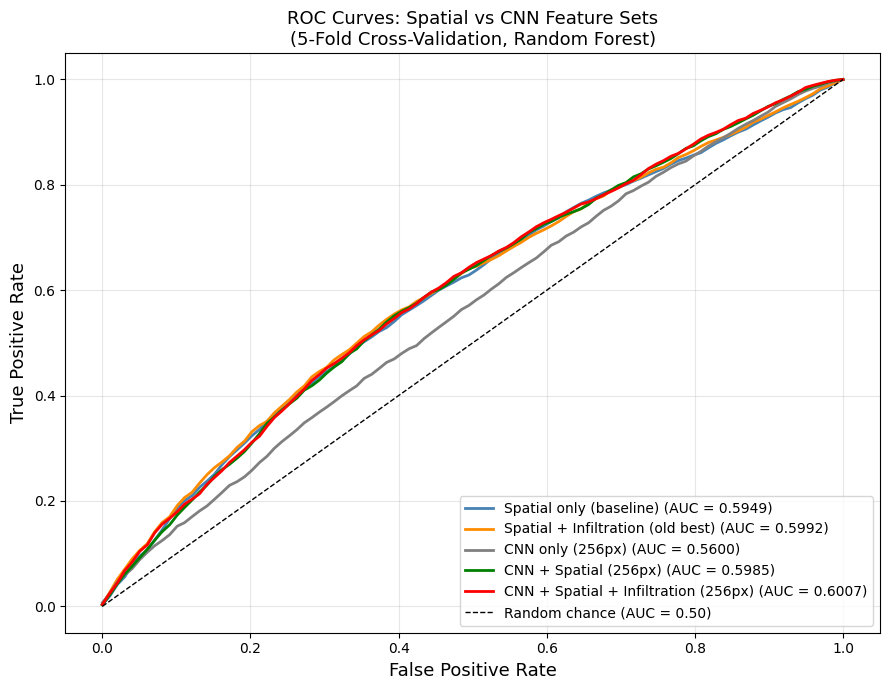

In [131]:
# ============================================================
# 18l. Final ROC Curve — Comparing All Feature Sets
# ============================================================

import torchvision.models as models
from sklearn.metrics import roc_curve, roc_auc_score

rf_plot = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Feature sets to compare
spatial_features      = ['nearest_tumour_dist', 'tumour_count_r150', 'tumour_frac_knn_20']
infiltration_features = ['CD47', 'THBS1']
cnn_features          = [f'cnn_pc{i+1}' for i in range(50)]

plot_feature_sets = {
    'Spatial only (baseline)':               spatial_features,
    'Spatial + Infiltration (old best)':     spatial_features + infiltration_features,
    'CNN only (256px)':                      cnn_features,
    'CNN + Spatial (256px)':                 cnn_features + spatial_features,
    'CNN + Spatial + Infiltration (256px)':  cnn_features + spatial_features + infiltration_features,
}

y  = ml_data_cnn['target']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, ax = plt.subplots(figsize=(9, 7))
colors  = ['steelblue', 'darkorange', 'grey', 'green', 'red']

for (name, features), color in zip(plot_feature_sets.items(), colors):
    X        = ml_data_cnn[features]
    tprs     = []
    aucs     = []
    mean_fpr = np.linspace(0, 1, 100)

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        rf_plot.fit(X_train, y_train)
        proba       = rf_plot.predict_proba(X_test)[:, 1]
        y_binary    = (y_test == 'Exhausted').astype(int)

        fpr, tpr, _ = roc_curve(y_binary, proba)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        aucs.append(roc_auc_score(y_binary, proba))

    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = np.mean(aucs)
    ax.plot(mean_fpr, mean_tpr, color=color, lw=2,
            label=f'{name} (AUC = {mean_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random chance (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves: Spatial vs CNN Feature Sets\n(5-Fold Cross-Validation, Random Forest)',
             fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


CNN Group-Specific LOPO — Untreated
Patients: 29  |  Cells: 3537
Patients evaluated:              28
Patients skipped (single class): 1
Mean per-patient AUC:            0.5574
Std:                             0.1300
Min:                             0.2857
Max:                             1.0000

Classification Report — CNN Untreated:
              precision    recall  f1-score   support

      Active       0.46      0.17      0.25      1561
   Exhausted       0.56      0.84      0.67      1973

    accuracy                           0.54      3534
   macro avg       0.51      0.51      0.46      3534
weighted avg       0.52      0.54      0.49      3534


CNN Group-Specific LOPO — Treated
Patients: 28  |  Cells: 4890
Patients evaluated:              28
Patients skipped (single class): 0
Mean per-patient AUC:            0.5611
Std:                             0.1064
Min:                             0.2321
Max:                             0.7642

Classification Report — CNN Treated:
   

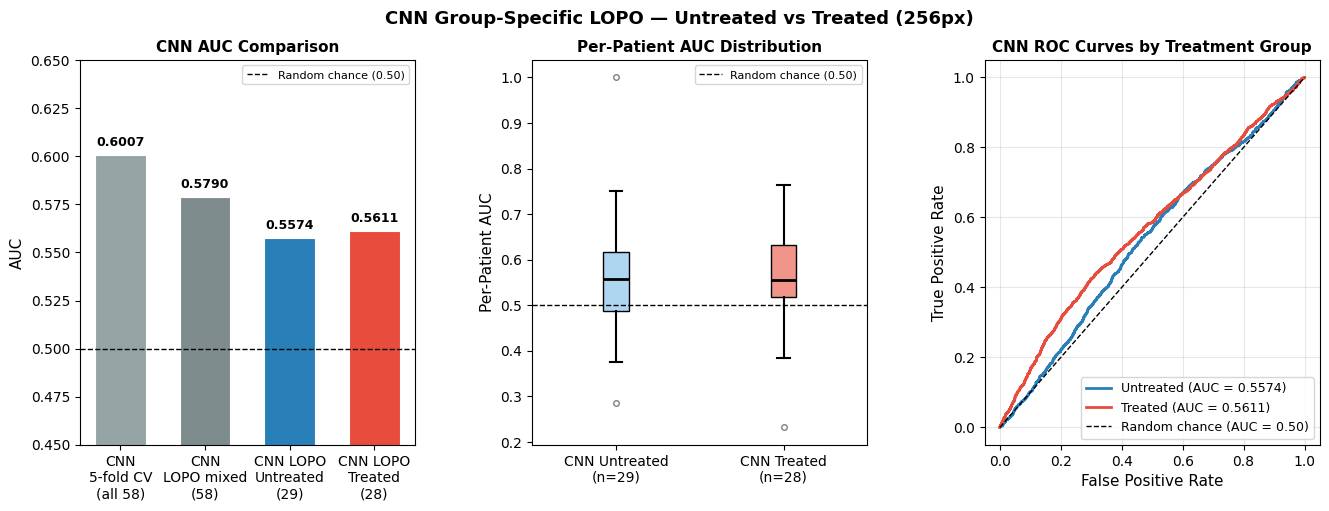

Saved: cnn_group_specific_lopo.png


In [132]:
# ============================================================
# 18m. Group-Specific LOPO — CNN 256px + Spatial + Infiltration
# ============================================================
# Applying the same group-specific LOPO approach from 17i to the
# best CNN model (256px + Spatial + Infiltration) to test whether
# CNN visual features generalise within each treatment group
# independently — separating Untreated and Treated patients.
# ============================================================


# Step 1: Add treatment column to ml_data_cnn from cd8_obs
ml_data_cnn['treatment_clean'] = cd8_obs.loc[ml_data_cnn.index, 'treatment_clean'].values

# Step 2: Best CNN feature set (256px + Spatial + Infiltration)
spatial_features      = ['nearest_tumour_dist', 'tumour_count_r150', 'tumour_frac_knn_20']
infiltration_features = ['CD47', 'THBS1']
cnn_features          = [f'cnn_pc{i+1}' for i in range(50)]
best_cnn_features     = cnn_features + spatial_features + infiltration_features

# Step 3: Same best hyperparameters from 17d
rf_cnn_group = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Storage for results
cnn_group_lopo_results = {}
cnn_group_patient_aucs = {}
cnn_group_roc_data     = {}
colors = {'Untreated': '#2980b9', 'Treated': '#e74c3c'}

# Step 4: Run LOPO separately for Untreated and Treated
for group in ['Untreated', 'Treated']:

    group_data = ml_data_cnn[ml_data_cnn['treatment_clean'] == group].copy()
    patients   = group_data['patients'].unique()

    print(f"\n{'='*60}")
    print(f"CNN Group-Specific LOPO — {group}")
    print(f"Patients: {len(patients)}  |  Cells: {len(group_data)}")
    print(f"{'='*60}")

    lopo_scores = []
    skipped     = []
    all_y_true  = []
    all_y_prob  = []
    all_y_pred  = []

    for patient in patients:

        # Train on all patients in same group EXCEPT this one
        train = group_data[group_data['patients'] != patient]
        test  = group_data[group_data['patients'] == patient]

        X_train = train[best_cnn_features]
        y_train = train['target']
        X_test  = test[best_cnn_features]
        y_test  = test['target']

        # Skip if test patient has only one class
        if len(y_test.unique()) < 2:
            skipped.append(patient)
            continue

        # Train and evaluate
        rf_cnn_group.fit(X_train, y_train)
        proba     = rf_cnn_group.predict_proba(X_test)[:, 1]
        y_pred    = rf_cnn_group.predict(X_test)
        auc_score = roc_auc_score(y_test, proba)
        lopo_scores.append(auc_score)

        # Collect for ROC curve and classification report
        all_y_true.extend(y_test.tolist())
        all_y_prob.extend(proba.tolist())
        all_y_pred.extend(y_pred.tolist())

    mean_auc = np.mean(lopo_scores)
    cnn_group_lopo_results[group] = mean_auc
    cnn_group_patient_aucs[group] = lopo_scores

    # Store ROC data
    fpr, tpr, _ = roc_curve(
        [1 if y == 'Exhausted' else 0 for y in all_y_true],
        all_y_prob
    )
    cnn_group_roc_data[group] = (fpr, tpr, mean_auc)

    print(f"Patients evaluated:              {len(lopo_scores)}")
    print(f"Patients skipped (single class): {len(skipped)}")
    print(f"Mean per-patient AUC:            {mean_auc:.4f}")
    print(f"Std:                             {np.std(lopo_scores):.4f}")
    print(f"Min:                             {np.min(lopo_scores):.4f}")
    print(f"Max:                             {np.max(lopo_scores):.4f}")

    # Classification report
    print(f"\nClassification Report — CNN {group}:")
    print(classification_report(all_y_true, all_y_pred,
                                target_names=['Active', 'Exhausted']))

# Step 5: Final comparison table
print(f"\n{'='*65}")
print("FINAL SUMMARY — Traditional ML vs CNN (All LOPO Results)")
print(f"{'='*65}")
print(f"{'Method':<50} {'AUC':>8}")
print("-" * 60)
print(f"{'Traditional ML — 5-fold CV (all 58)':<50} {'0.5992':>8}")
print(f"{'Traditional ML — LOPO mixed (58)':<50} {'0.5852':>8}")
print(f"{'Traditional ML — LOPO Untreated (29)':<50} {'0.5939':>8}")
print(f"{'Traditional ML — LOPO Treated (28)':<50} {'0.5766':>8}")
print("-" * 60)
print(f"{'CNN 256px — 5-fold CV (all 58)':<50} {'0.6007':>8}")
print(f"{'CNN 256px — LOPO mixed (58)':<50} {'0.5790':>8}")
print(f"{'CNN 256px — LOPO Untreated (29)':<50} {cnn_group_lopo_results['Untreated']:>8.4f}")
print(f"{'CNN 256px — LOPO Treated (28)':<50} {cnn_group_lopo_results['Treated']:>8.4f}")

# ── PLOTS ──────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
fig.suptitle("CNN Group-Specific LOPO — Untreated vs Treated (256px)",
             fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Plot 1: AUC Comparison Bar Chart ──
ax1 = fig.add_subplot(gs[0, 0])
methods = [
    'CNN\n5-fold CV\n(all 58)',
    'CNN\nLOPO mixed\n(58)',
    'CNN LOPO\nUntreated\n(29)',
    'CNN LOPO\nTreated\n(28)'
]
aucs = [
    0.6007,
    0.5790,
    cnn_group_lopo_results['Untreated'],
    cnn_group_lopo_results['Treated']
]
bar_colors = ['#95a5a6', '#7f8c8d', '#2980b9', '#e74c3c']
bars = ax1.bar(methods, aucs, color=bar_colors, edgecolor='white',
               linewidth=0.8, width=0.6)
ax1.axhline(y=0.5, color='black', linestyle='--', linewidth=1,
            label='Random chance (0.50)')
ax1.set_ylim(0.45, 0.65)
ax1.set_ylabel('AUC', fontsize=11)
ax1.set_title('CNN AUC Comparison', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)
for bar, val in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9,
             fontweight='bold')

# ── Plot 2: Per-Patient AUC Boxplot ──
ax2 = fig.add_subplot(gs[0, 1])
data_to_plot = [
    cnn_group_patient_aucs['Untreated'],
    cnn_group_patient_aucs['Treated']
]
bp = ax2.boxplot(data_to_plot, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5),
                 flierprops=dict(marker='o', markersize=4, alpha=0.5))
bp['boxes'][0].set_facecolor('#aed6f1')
bp['boxes'][1].set_facecolor('#f1948a')
ax2.axhline(y=0.5, color='black', linestyle='--', linewidth=1,
            label='Random chance (0.50)')
ax2.set_xticks([1, 2])
ax2.set_xticklabels([
    f'CNN Untreated\n(n=29)',
    f'CNN Treated\n(n=28)'
])
ax2.set_ylabel('Per-Patient AUC', fontsize=11)
ax2.set_title('Per-Patient AUC Distribution', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)

# ── Plot 3: ROC Curves ──
ax3 = fig.add_subplot(gs[0, 2])
for group, (fpr, tpr, mean_auc) in cnn_group_roc_data.items():
    ax3.plot(fpr, tpr, color=colors[group], lw=2,
             label=f'{group} (AUC = {mean_auc:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', lw=1, label='Random chance (AUC = 0.50)')
ax3.set_xlabel('False Positive Rate', fontsize=11)
ax3.set_ylabel('True Positive Rate', fontsize=11)
ax3.set_title('CNN ROC Curves by Treatment Group', fontsize=11,
              fontweight='bold')
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_group_specific_lopo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cnn_group_specific_lopo.png")

In [134]:
# Traditional ML Treated
print("Traditional ML — Treated:")
train_treated = ml_data[ml_data['treatment_clean'] == 'Treated']

all_true, all_pred = [], []
for patient in train_treated['patients'].unique():
    train = train_treated[train_treated['patients'] != patient]
    test  = train_treated[train_treated['patients'] == patient]
    
    if len(test['target'].unique()) < 2:
        continue
    
    # Only use features that exist in this subset
    valid_features = [f for f in best_features if f in train.columns]
    
    rf_group.fit(train[valid_features], train['target'])
    all_pred.extend(rf_group.predict(test[valid_features]).tolist())
    all_true.extend(test['target'].tolist())

print(classification_report(all_true, all_pred, target_names=['Active', 'Exhausted']))

Traditional ML — Treated:
              precision    recall  f1-score   support

      Active       0.57      0.72      0.64      2547
   Exhausted       0.58      0.41      0.48      2343

    accuracy                           0.57      4890
   macro avg       0.57      0.57      0.56      4890
weighted avg       0.57      0.57      0.56      4890



In [135]:
# Quick check — print all stored results
print("TRADITIONAL ML — TREATED")
print(f"Mean AUC: {group_lopo_results['Treated']:.4f}")
print(f"Std:      {np.std(group_patient_aucs['Treated']):.4f}")
print(f"Min:      {np.min(group_patient_aucs['Treated']):.4f}")
print(f"Max:      {np.max(group_patient_aucs['Treated']):.4f}")
print(f"Patients evaluated: {len(group_patient_aucs['Treated'])}")

print("\nCNN — TREATED")
print(f"Mean AUC: {cnn_group_lopo_results['Treated']:.4f}")
print(f"Std:      {np.std(cnn_group_patient_aucs['Treated']):.4f}")
print(f"Min:      {np.min(cnn_group_patient_aucs['Treated']):.4f}")
print(f"Max:      {np.max(cnn_group_patient_aucs['Treated']):.4f}")
print(f"Patients evaluated: {len(cnn_group_patient_aucs['Treated'])}")

TRADITIONAL ML — TREATED
Mean AUC: 0.5766
Std:      0.0879
Min:      0.3932
Max:      0.7321
Patients evaluated: 28

CNN — TREATED
Mean AUC: 0.5611
Std:      0.1064
Min:      0.2321
Max:      0.7642
Patients evaluated: 28


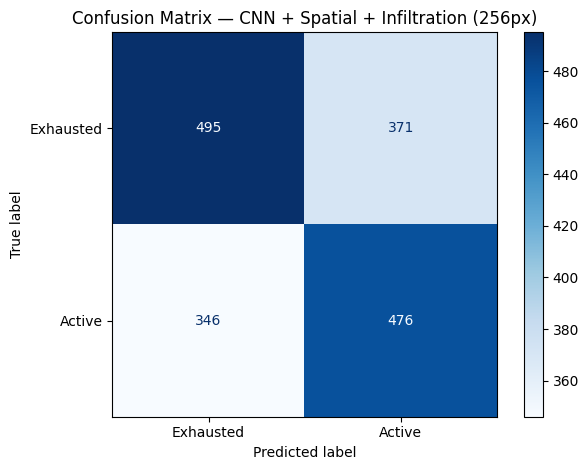

In [136]:
# Use best feature set
features = cnn_features + spatial_features + infiltration_features
X = ml_data_cnn[features]
y = ml_data_cnn['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_plot.fit(X_train, y_train)
y_pred = rf_plot.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=['Exhausted', 'Active'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Exhausted', 'Active'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — CNN + Spatial + Infiltration (256px)')
plt.tight_layout()
plt.show()

In [137]:
# Check treatment groups and patient counts
print(cd8_obs['treatment_clean'].value_counts())
print()

# Count unique patients per treatment group
treatment_patients = cd8_obs.drop_duplicates('patients').groupby('treatment_clean')['patients'].count()
print("Patients per treatment group:")
print(treatment_patients)

treatment_clean
Treated      4890
Untreated    3537
Unknown        12
Name: count, dtype: int64

Patients per treatment group:
treatment_clean
Treated      28
Unknown       1
Untreated    29
Name: patients, dtype: int64


In [140]:
# Save the trained model and data for the dashboard

# Save the best Random Forest model
joblib.dump(best_rf, 'dashboard_model.pkl')

# Save ml_data for the dashboard
ml_data_save = ml_data.copy()
ml_data_save.to_csv('dashboard_data.csv')

# Save cd8_obs for spatial coordinates and patient info
cd8_obs_save = cd8_obs[[
    'x', 'y', 'samples', 'patients', 
    'treatment_clean', 'immunotherapy_clean', 'site_clean',
    'exhaustion_score', 'target',
    'nearest_tumour_dist', 'tumour_count_r150', 'tumour_frac_knn_20',
    'CD47', 'THBS1'
]].copy()
cd8_obs_save.to_csv('dashboard_cells.csv')

print("Saved:")
print("  dashboard_model.pkl")
print("  dashboard_data.csv")
print(f"  dashboard_cells.csv ({len(cd8_obs_save):,} cells)")

Saved:
  dashboard_model.pkl
  dashboard_data.csv
  dashboard_cells.csv (8,439 cells)


In [142]:
# Check all cell types and what columns are available for them
print("All cell types in dataset:")
print(data.obs['cell.subtypes'].value_counts())

print("\nAvailable spatial columns:")
print(data.obs.columns.tolist())

# Check if spatial features exist for all cells
print("\nSample of obs data:")
print(data.obs[['samples', 'patients', 'cell.subtypes', 'x', 'y', 
                 'treatment_clean', 'immunotherapy_clean']].head(5))

All cell types in dataset:
cell.subtypes
Malignant           297960
Fibroblast           62613
Monocyte             35182
Malignant_LC         16231
Monocyte_LC          10367
Fibroblast_LC        10248
B.cell_LC            10212
Endothelial           8388
CD8.T.cell            6957
B.cell                6161
Endothelial_LC        5148
NK.cell               5024
T.B.cell_LC           4205
CD4.T.cell.DN         2623
NK.cell_LC            1873
Treg                  1694
CD8.T.cell_LC         1482
CD4.T.cell            1422
CD4.T.cell.DN_LC      1268
T.cell.DP              908
CD4.T.cell_LC          727
Mast.cell              527
Treg_LC                211
T.cell.DP_LC           194
T.B.cell                88
Mast.cell_LC            79
Name: count, dtype: int64

Available spatial columns:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'samples', 'patients', 'sites_binary', 'cell.types', 'cell.subtypes', 'x', 'y', 'ident', 'treatment_clean', 'immunotherapy_clean', 'site_clean']

Sample of ob

In [144]:
import h5py
import shutil

# Copy the file first
shutil.copy('ST_Discovery.h5ad', 'ST_Discovery_clean.h5ad')

# Open the copy and delete the scaledata layer
with h5py.File('ST_Discovery_clean.h5ad', 'r+') as f:
    if 'layers' in f and 'scaledata' in f['layers']:
        del f['layers']['scaledata']
        print("Removed scaledata layer")
    else:
        print("No scaledata layer found")

print("Done — ST_Discovery_clean.h5ad is ready")

Removed scaledata layer
Done — ST_Discovery_clean.h5ad is ready


In [149]:
cols_to_save = [
    'samples', 'patients', 'x', 'y', 'cell.subtypes',
    'nearest_tumour_dist', 'tumour_count_r150', 'tumour_frac_knn_20',
    'exhaustion_score', 'target', 'treatment_clean', 'immunotherapy_clean',
    'site_clean', 'CD47', 'THBS1'
]

available_cols = [c for c in cols_to_save if c in cd8_obs.columns]
cd8_obs[available_cols].to_csv('dashboard_cells.csv')
print(f"Saved with columns: {available_cols}")

Saved with columns: ['samples', 'patients', 'x', 'y', 'cell.subtypes', 'nearest_tumour_dist', 'tumour_count_r150', 'tumour_frac_knn_20', 'exhaustion_score', 'target', 'treatment_clean', 'immunotherapy_clean', 'site_clean', 'CD47', 'THBS1']


In [146]:
import pandas as pd
df = pd.read_csv('dashboard_cells.csv', index_col=0)
print(df.columns.tolist())
print(df.shape)

['samples', 'patients', 'x', 'y', 'cell.subtypes', 'exhaustion_score', 'target', 'treatment_clean', 'immunotherapy_clean', 'site_clean', 'CD47', 'THBS1']
(8439, 12)


In [147]:
import pandas as pd

cols_to_save = [
    'samples', 'patients', 'x', 'y', 'cell.subtypes',
    'nearest_tumour_dist', 'neighbour_count_r150', 'neighbour_frac_knn_20',
    'exhaustion_score', 'target', 'treatment_clean', 'immunotherapy_clean',
    'site_clean', 'CD47', 'THBS1'
]

available_cols = [c for c in cols_to_save if c in cd8_obs.columns]
cd8_obs[available_cols].to_csv('dashboard_cells.csv')
print(f"Saved with columns: {available_cols}")

Saved with columns: ['samples', 'patients', 'x', 'y', 'cell.subtypes', 'nearest_tumour_dist', 'exhaustion_score', 'target', 'treatment_clean', 'immunotherapy_clean', 'site_clean', 'CD47', 'THBS1']


In [148]:
print([c for c in cd8_obs.columns if 'neighbour' in c or 'count' in c or 'frac' in c or 'knn' in c])

['tumour_count_r20', 'tumour_count_r50', 'tumour_count_r100', 'tumour_count_r150', 'tumour_count_r200', 'tumour_frac_knn_20', 'tumour_count_knn_20', 'tumour_neighbourhood_knn', 'tumour_neighbourhood', 'tumour_neighbourhood_r150']
